# EEGSynthesizer — validación externa reproducible

Este notebook separa estrictamente desarrollo y evaluación externa. Los casos
`chb01`, `chb02`, `chb03`, `chb05`, `chb06` y el registro `chb21` —la misma
persona que `chb01`— se reservan para desarrollo. Los demás sujetos permanecen
bloqueados hasta que el generador tenga un manifiesto congelado.

## Cómo ejecutar

Para la reproducción normal, ejecute primero `1_0_EEGSynthesizer_DATASET.ipynb` y después
use **Run All** aquí con el modo predeterminado `siena_external`. Una sola ejecución valida
CHB-MIT y Siena, reanudando descargas y reutilizando artefactos cuyos hashes sean válidos.

Los otros modos son opciones de mantenimiento o auditoría:

1. `status`: inspecciona prerrequisitos sin descargar ni recalcular.
2. `prepare_dev`: reconstruye el perfil de desarrollo; no es necesario porque el perfil congelado está publicado.
3. `external`: ejecuta únicamente la evaluación externa CHB-MIT.
4. `siena_external` (predeterminado): ejecuta CHB-MIT y luego la validación multicorpus con Siena.

Las descargas usan archivos `.part`, reanudación HTTP, reintentos y SHA-256. Si un
corpus ya está completo, el notebook lo informa y no vuelve a descargarlo. Los
resultados derivados se reutilizan únicamente cuando sus manifiestos y hashes son
válidos. Una reconstrucción completa requiere aproximadamente 60 GiB libres.

Los nombres `generalized_absence` y `focal_temporal` son escenarios paramétricos,
no diagnósticos. CHB-MIT y Siena permiten evaluar plausibilidad morfológica
operacional, cobertura por rasgos y utilidad de transferencia en dominios externos.
Una afirmación de equivalencia clínica requeriría otro diseño, con márgenes clínicos
predefinidos y evaluación experta independiente. La proximidad se interpreta
exclusivamente como una medida descriptiva en el espacio de características.

## Interpretación de estados técnicos

- `SUPPORTED`: se cumplió el criterio prospectivo especificado.
- `NOT SUPPORTED`: no se alcanzó el criterio completo; no significa ausencia de
  efecto, daño ni invalidez del sintetizador.
- `NOT EVALUABLE`: el tamaño muestral quedó por debajo del mínimo prospectivo; la
  estimación se reporta como exploratoria.
- `REPORTED`: referencia descriptiva sin decisión confirmatoria asociada.


In [1]:
# BLOQUE 0 — configuración visible, rutas y preflight
import atexit, concurrent.futures, gc, hashlib, importlib.metadata, json, os, re, shutil, subprocess, sys, time, urllib.error, urllib.request
from pathlib import Path

# Reducciones y modelos en un solo hilo para reproducibilidad numérica entre
# ejecuciones del mismo entorno. Las semillas de cada sujeto se fijan después.
os.environ.setdefault("OMP_NUM_THREADS","1")
os.environ.setdefault("MKL_NUM_THREADS","1")
os.environ.setdefault("OPENBLAS_NUM_THREADS","1")
os.environ.setdefault("NUMEXPR_NUM_THREADS","1")

import matplotlib
matplotlib.use("Agg")
import numpy as np
import pandas as pd
import mne
from scipy import signal, stats
from scipy.spatial.distance import cdist
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Selección interactiva. La variable del sistema es solo una alternativa para
# ejecución automatizada; un investigador puede cambiar esta línea en Jupyter.
NOTEBOOK_MODE = "siena_external"  # status | prepare_dev | external | siena_external
MODE = os.environ.get("EEGSYN_VALIDATION_MODE", NOTEBOOK_MODE).strip().lower()
if MODE not in {"status", "prepare_dev", "external", "siena_external"}:
    raise ValueError("MODE debe ser status, prepare_dev, external o siena_external")

PROJECT_ROOT = Path.cwd().resolve()
EXPECTED_PROJECT_FILES = {"1_0_EEGSynthesizer_DATASET.ipynb", "1_1_EEGSynthesizer_VALIDATION.ipynb", "requirements.txt"}
missing_project_files = sorted(name for name in EXPECTED_PROJECT_FILES if not (PROJECT_ROOT/name).exists())
if missing_project_files:
    raise RuntimeError("Abra Jupyter desde la raíz del repositorio; faltan: " + ", ".join(missing_project_files))

SYN_DIR = PROJECT_ROOT / "dataset_eeg_final"
REAL_DIR = PROJECT_ROOT / "dataset_doctorado_final"
PUBLISHED_OUT_DIR = REAL_DIR / "validation_q1_assets"
PUBLISHED_STATE_PATH = REAL_DIR / "reproducibility_state.json"
CACHE = REAL_DIR / "chb_mit_cache"
WORK_ROOT = PROJECT_ROOT / "tmp" / "eegsynth_rebuild"
DEV_WORK = WORK_ROOT / "dev_candidate"
REAL_WORK = WORK_ROOT / "real_candidate"
VALIDATION_STAGE_ROOT = WORK_ROOT / "validation_candidate"
VALIDATION_STAGE_OUT_DIR = VALIDATION_STAGE_ROOT / "validation_q1_assets"
VALIDATION_STAGE_STATE_PATH = VALIDATION_STAGE_ROOT / "reproducibility_state.json"
PUBLISHED_AUDIT_PATH = PUBLISHED_OUT_DIR / "15_reproducibility_audit.json"
PIPELINE_LOCK_PATH = PROJECT_ROOT / "tmp" / "eegsynth_pipeline.lock"
VALIDATION_MIGRATION_ID = "2026-08-runall-stable-notebook-code-hash-v4"
AUTHORIZED_CHANGE_SCOPES = (
  "notebook_code_hash_scope",
  "saved_vs_executed_source_check",
  "runall_output_persistence",
  "audit_only_idempotency_and_locking",
  "audit_only_csv_empty_string_normalization",
  "saved_vs_executed_trailing_newline_normalization",
  "audit_only_inline_topography_png",
)
REFERENCE_MIGRATION_ACCEPT = os.environ.get("EEGSYN_ACCEPT_REFERENCE_MIGRATION","0").strip()=="1"
REFERENCE_MIGRATION_RESTART = os.environ.get("EEGSYN_RESTART_PENDING_MIGRATION","0").strip()=="1"
REBUILD_REAL_REQUESTED = os.environ.get("EEGSYN_REBUILD_REAL", "0") == "1"
SIENA_REBUILD_REQUESTED = os.environ.get("EEGSYN_REBUILD_SIENA", "0") == "1"

# Lock exclusivo compartido por 1_0 y 1_1. Se libera al terminar, ante error de
# cualquier celda, ante KeyboardInterrupt y al cerrar el kernel.
_previous_pipeline_release = globals().get("_release_eegsynth_pipeline_lock")
if callable(_previous_pipeline_release): _previous_pipeline_release()
_previous_pipeline_hook = globals().get("_eegsynth_pipeline_post_run_cell")
try:
    if _previous_pipeline_hook is not None: get_ipython().events.unregister("post_run_cell",_previous_pipeline_hook)
except (NameError,ValueError):
    pass
_PIPELINE_LOCK_OWNED=False
_PIPELINE_LOCK_TOKEN={"pid":os.getpid(),"notebook":"1_1_EEGSynthesizer_VALIDATION.ipynb","started_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime())}
def _release_eegsynth_pipeline_lock():
    global _PIPELINE_LOCK_OWNED
    if not _PIPELINE_LOCK_OWNED: return
    try:
        owner=json.loads(PIPELINE_LOCK_PATH.read_text(encoding="utf-8")) if PIPELINE_LOCK_PATH.is_file() else None
        if owner==_PIPELINE_LOCK_TOKEN: PIPELINE_LOCK_PATH.unlink()
    except BaseException:
        pass
    _PIPELINE_LOCK_OWNED=False
def _acquire_eegsynth_pipeline_lock():
    global _PIPELINE_LOCK_OWNED
    PIPELINE_LOCK_PATH.parent.mkdir(parents=True,exist_ok=True)
    payload=(json.dumps(_PIPELINE_LOCK_TOKEN,sort_keys=True,separators=(",",":"))+"\n").encode("utf-8")
    try:
        fd=os.open(str(PIPELINE_LOCK_PATH),os.O_WRONLY|os.O_CREAT|os.O_EXCL)
    except FileExistsError as exc:
        try: owner=PIPELINE_LOCK_PATH.read_text(encoding="utf-8").strip()
        except BaseException: owner="unreadable"
        raise RuntimeError(f"EEGSynth pipeline already running; lock={PIPELINE_LOCK_PATH}; owner={owner}") from exc
    try:
        os.write(fd,payload); os.fsync(fd)
    except BaseException:
        os.close(fd)
        try: PIPELINE_LOCK_PATH.unlink()
        except BaseException: pass
        raise
    os.close(fd); _PIPELINE_LOCK_OWNED=True
def _eegsynth_pipeline_post_run_cell(result):
    if getattr(result,"error_before_exec",None) is not None or getattr(result,"error_in_exec",None) is not None:
        _release_eegsynth_pipeline_lock()
_acquire_eegsynth_pipeline_lock()
atexit.register(_release_eegsynth_pipeline_lock)
try: get_ipython().events.register("post_run_cell",_eegsynth_pipeline_post_run_cell)
except NameError: pass

SOURCE_SHA256_LOCKS = {
  "generation_manifest":(SYN_DIR/"generation_manifest.json","08091538c5cb593ea711139db512145ef505b0bbc2dcface273807434a7b2db0"),
  "X_real":(REAL_DIR/"X_real.npy","80ee61d0d0c3f17e442ed66452837e1dc413ab24544cb3e4bd79de003a48bb17"),
  "y_real":(REAL_DIR/"y_real.npy","d6ac1bc1438dbc4962410ed818f4b019e15adc443df48fc9cccbb612e9a60c36"),
  "pid_real":(REAL_DIR/"pid_real.npy","ea82858a14512b2dd63f9ed24a64ca15a72c7e6a14d1bc2761eeb3afa4d8d0ce"),
  "real_window_metadata":(REAL_DIR/"real_window_metadata.csv","13d1c46945ec3bb20e103a009a1d29aa27893be9e64e0e02d49876f3de8f9583"),
  "real_manifest":(REAL_DIR/"real_manifest.json","bbe48c17d6c4c9a8263698af196db8c3e0aeca74284067e38a1486aad1773d50"),
  "siena_X":(REAL_DIR/"siena_X.npy","87ecf1fbae3168fdb3d4e60c3961af5a6b4cddc113222769107702971273bf08"),
  "siena_y":(REAL_DIR/"siena_y.npy","ed0f7f072c39a5da2c0dfcc2a8a9f4959dc97251d54bca43df82855ae9f74023"),
  "siena_pid":(REAL_DIR/"siena_pid.npy","e927c7a16ca5f12bffe31fdf02385d7b0a773210bc6d8c0e48d583824adad7cf"),
  "siena_window_metadata":(REAL_DIR/"siena_window_metadata.csv","87a3dfde68b2c8b55be15efc8638b94e9d993c021da551d7da64585533a5267f"),
  "siena_annotation":(REAL_DIR/"siena_annotation_audit.csv","9ded998cd9d967c1ab0f6e55d6062dbdbf4a147a334c4c15e900cce5fd67110c"),
  "siena_manifest":(REAL_DIR/"siena_manifest.json","6cc2d23e6ec970680ebe42dadccd6556951a2480a3a312dee80eb078fd313a84"),
}
VALIDATION_PRODUCT_NAMES = [
  "01_internal_separability.csv","02_fidelity_featurewise.csv","02b_morphology_coverage.csv","02c_fidelity_by_subject.csv",
  "03_cross_domain_loso.csv","03b_cross_domain_bootstrap.csv","04_feature_space_proximity_diversity.csv","05_final_summary.json","05_final_verdict_lines.csv",
  "08_siena_annotation_audit.csv","08_siena_integrity_summary.json","09_siena_fidelity_featurewise.csv","09_siena_morphology_coverage.csv","09_siena_proximity_diversity.csv",
  "10_siena_mmd_by_subject.csv","10_siena_real_real_by_subject.csv","10_siena_real_real_reference.csv","11_siena_bootstrap_summary.csv","11_siena_transfer_loso.csv",
  "12_siena_laterality_audit.csv","12_siena_phase_summary.csv","13_multicorpus_claim_matrix.csv","13_multicorpus_comparison.csv","13_multicorpus_final_summary.json",
  "14_siena_ictal_preictal_bootstrap.csv","14_siena_ictal_preictal_integrity.json","14_siena_ictal_preictal_loso.csv","14_siena_ictal_preictal_paired_differences.csv",
  "15_reproducibility_audit.json","16_fig_auroc_forest.pdf","16_fig_auroc_forest.png","16_fig_morphology_fidelity.pdf","16_fig_morphology_fidelity.png",
  "16_fig_psd_multicorpus.pdf","16_fig_psd_multicorpus.png","16_fig_signal_comparison.pdf","16_fig_signal_comparison.png","16_fig_symmetry_degradation.pdf",
  "16_fig_symmetry_degradation.png","16_fig_syn_effect.pdf","16_fig_syn_effect.png","16_publication_captions.csv","16_publication_figure_audit.csv",
  "16_publication_manifest.json","16_publication_multicorpus_table.csv","16_publication_multicorpus_table.tex","16_publication_representative_signals.csv",
]
if len(VALIDATION_PRODUCT_NAMES)!=47 or len(set(VALIDATION_PRODUCT_NAMES))!=47: raise RuntimeError("contrato interno inválido: se requieren 47 destinos únicos")
TRACE_PRODUCT_NAMES = ["07_generalized_symmetry_summary.json"]
PROMOTION_PRODUCT_NAMES = VALIDATION_PRODUCT_NAMES + TRACE_PRODUCT_NAMES
if len(PROMOTION_PRODUCT_NAMES)!=48 or len(set(PROMOTION_PRODUCT_NAMES))!=48: raise RuntimeError("contrato de migración inválido: se requieren 48 destinos existentes únicos")
TRACEABILITY_PROMOTION_PRODUCT_NAMES = ["07_generalized_symmetry_summary.json","13_multicorpus_final_summary.json","14_siena_ictal_preictal_integrity.json","15_reproducibility_audit.json","16_publication_manifest.json"]
IMMUTABLE_PRODUCT_NAMES = sorted(set(PROMOTION_PRODUCT_NAMES)-set(TRACEABILITY_PROMOTION_PRODUCT_NAMES))
if len(TRACEABILITY_PROMOTION_PRODUCT_NAMES)!=5 or len(IMMUTABLE_PRODUCT_NAMES)!=43: raise RuntimeError("contrato trace-only inválido: se requieren 5 productos promovibles y 43 inmutables")

def locked_file_sha256(path):
    h=hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda:handle.read(16*1024*1024),b""): h.update(block)
    return h.hexdigest()

NOTEBOOK_HASH_SCOPE="code_cells_v1"
NOTEBOOK_CODE_HASH_SCHEMA="notebook-code-sha256-v1"
def normalize_notebook_code_source(source):
    text="".join(source) if isinstance(source,list) else str(source or "")
    return text.replace("\r\n","\n").replace("\r","\n")
def notebook_code_sources(path):
    nb=json.loads(Path(path).read_text(encoding="utf-8"))
    return [normalize_notebook_code_source(cell.get("source",[])) for cell in nb.get("cells",[]) if cell.get("cell_type")=="code"]
def notebook_code_sha256(path):
    payload=json.dumps({"schema":NOTEBOOK_CODE_HASH_SCHEMA,"code_cells":notebook_code_sources(path)},ensure_ascii=False,separators=(",",":"))+"\n"
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()
def saved_vs_executed_source_check(path):
    saved=[source.rstrip("\n") for source in notebook_code_sources(path)]
    try: raw=list(get_ipython().history_manager.input_hist_raw)[1:]
    except (NameError,AttributeError):
        return {"status":"NOT EVALUABLE","reason":"IPython raw history unavailable","saved_code_cells":len(saved),"compared_entries":0,"mismatch_indices":[]}
    executed=[normalize_notebook_code_source(item).rstrip("\n") for item in raw if isinstance(item,str) and item.strip()]
    tail=executed[-len(saved):] if saved else []
    mismatches=[i for i,(left,right) in enumerate(zip(saved,tail)) if left!=right]
    if len(tail)!=len(saved): mismatches.extend(range(len(tail),len(saved)))
    return {"status":"SUPPORTED" if not mismatches else "NOT SUPPORTED","hash_scope":NOTEBOOK_HASH_SCOPE,"saved_code_cells":len(saved),"compared_entries":len(tail),"mismatch_indices":sorted(set(mismatches))}

locked_source_report={}
required_lock_names=[]
if MODE in {"external","siena_external"}: required_lock_names=["generation_manifest","X_real","y_real","pid_real","real_window_metadata","real_manifest"]
if MODE=="siena_external": required_lock_names=list(SOURCE_SHA256_LOCKS)
for lock_name in required_lock_names:
    lock_path,expected=SOURCE_SHA256_LOCKS[lock_name]; actual=locked_file_sha256(lock_path) if lock_path.is_file() else None
    locked_source_report[lock_name]={"path":str(lock_path.relative_to(PROJECT_ROOT)).replace("\\","/"),"expected_sha256":expected,"actual_sha256":actual,"valid":actual==expected}
bad_source_locks=[name for name,row in locked_source_report.items() if not row["valid"]]
if bad_source_locks: raise RuntimeError("SOURCE LOCK FAILURE; no builder may run: "+", ".join(bad_source_locks))
if MODE=="siena_external" and (REBUILD_REAL_REQUESTED or SIENA_REBUILD_REQUESTED):
    raise RuntimeError("REBUILD_REAL/SIENA_REBUILD are forbidden in validation staging")
if MODE=="external" and REBUILD_REAL_REQUESTED: raise RuntimeError("REBUILD_REAL is forbidden while exact source locks are active")

PUBLISHED_AUDIT_SNAPSHOT = json.loads(PUBLISHED_AUDIT_PATH.read_text(encoding="utf-8")) if PUBLISHED_AUDIT_PATH.exists() else None
PUBLISHED_SCIENTIFIC_REFERENCE = (PUBLISHED_AUDIT_SNAPSHOT or {}).get("published_scientific_reference",(PUBLISHED_AUDIT_SNAPSHOT or {}).get("scientific_results",{}))
LOCKED_PRIMARY_RESULTS = {
  "CHB_MIT_TSTR_RF_zscore":{"status":"SUPPORTED","macro_auc":0.6430743202093415,"ci95":[0.5460355378919731,0.7332719679407158],"n_subjects":18},
  "Siena_TSTR_RF_zscore_clean_preictal":{"status":"SUPPORTED","macro_auc":0.7008300137418093,"ci95":[0.6211641143045521,0.7762140062259614],"n_subjects":14},
  "CHB_PLUS_SYN_minus_CHB":{"status":"SUPPORTED","mean_auc_difference":0.05628574513892359,"ci95_low":0.03290353526114568,"ci95_high":0.0807642759510501,"subjects_improved":13,"n_subjects":14},
}
PUBLISHED_REFERENCE_MIGRATION=(PUBLISHED_AUDIT_SNAPSHOT or {}).get("published_scientific_reference_migration",{})
PUBLISHED_MIGRATION_STATUS=PUBLISHED_REFERENCE_MIGRATION.get("status")
if REFERENCE_MIGRATION_ACCEPT and REFERENCE_MIGRATION_RESTART: raise RuntimeError("accept and restart flags are mutually exclusive")
if REFERENCE_MIGRATION_RESTART and not (PUBLISHED_MIGRATION_STATUS=="PENDING_REVIEW" and PUBLISHED_REFERENCE_MIGRATION.get("migration_id")==VALIDATION_MIGRATION_ID):
    raise RuntimeError("restart requires a PENDING_REVIEW audit for this exact migration")
MIGRATION_PHASE="NOT_APPLICABLE"
OUT_DIR=PUBLISHED_OUT_DIR; STATE_PATH=PUBLISHED_STATE_PATH
VALIDATION_RUN_UTC=time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime())
if MODE=="siena_external":
    missing_published=[name for name in PROMOTION_PRODUCT_NAMES if not (PUBLISHED_OUT_DIR/name).is_file()]
    if missing_published or not PUBLISHED_STATE_PATH.is_file():
        raise RuntimeError("published snapshot is incomplete; no destination may be created: "+str(missing_published))
    if REFERENCE_MIGRATION_ACCEPT:
        if PUBLISHED_MIGRATION_STATUS!="PENDING_REVIEW" or PUBLISHED_REFERENCE_MIGRATION.get("migration_id")!=VALIDATION_MIGRATION_ID:
            raise RuntimeError("acceptance flag requires the matching PENDING_REVIEW audit")
        if PUBLISHED_REFERENCE_MIGRATION.get("authorized_change_scopes")!=list(AUTHORIZED_CHANGE_SCOPES):
            raise RuntimeError("pending audit does not contain the exact authorized change scopes")
        frozen_candidate_sha=PUBLISHED_REFERENCE_MIGRATION.get("candidate_scientific_reference_sha256")
        frozen_product_hashes=PUBLISHED_REFERENCE_MIGRATION.get("candidate_product_sha256",{})
        frozen_trace_product_hashes=PUBLISHED_REFERENCE_MIGRATION.get("candidate_trace_product_sha256",{})
        frozen_notebook_code_hashes=PUBLISHED_REFERENCE_MIGRATION.get("candidate_notebook_code_sha256",{})
        if not (isinstance(frozen_candidate_sha,str) and re.fullmatch(r'[0-9a-f]{64}',frozen_candidate_sha) and len(frozen_product_hashes)==46 and set(frozen_trace_product_hashes)==set(TRACE_PRODUCT_NAMES) and len(frozen_notebook_code_hashes)==2 and PUBLISHED_REFERENCE_MIGRATION.get("notebook_hash_scope")==NOTEBOOK_HASH_SCOPE and PUBLISHED_REFERENCE_MIGRATION.get("promotion_product_names")==TRACEABILITY_PROMOTION_PRODUCT_NAMES and len(PUBLISHED_REFERENCE_MIGRATION.get("immutable_product_sha256",{}))==43):
            raise RuntimeError("pending audit lacks a complete frozen candidate hash set")
        if not VALIDATION_STAGE_OUT_DIR.is_dir() or not VALIDATION_STAGE_STATE_PATH.is_file():
            raise RuntimeError("pending candidate staging is absent; acceptance is forbidden")
        missing_staged=[name for name in PROMOTION_PRODUCT_NAMES if not (VALIDATION_STAGE_OUT_DIR/name).is_file()]
        if missing_staged: raise RuntimeError("pending staging is incomplete: "+str(missing_staged))
        VALIDATION_RUN_UTC=PUBLISHED_REFERENCE_MIGRATION.get("validation_run_utc")
        if not isinstance(VALIDATION_RUN_UTC,str): raise RuntimeError("pending audit lacks VALIDATION_RUN_UTC")
        MIGRATION_PHASE="ACCEPT_PENDING"
    else:
        published_migration_is_current=PUBLISHED_REFERENCE_MIGRATION.get("migration_id")==VALIDATION_MIGRATION_ID
        if PUBLISHED_MIGRATION_STATUS=="PENDING_REVIEW":
            if not published_migration_is_current: raise RuntimeError("a different reference migration is still pending review and must be resolved first")
            if not REFERENCE_MIGRATION_RESTART: raise RuntimeError("reference migration is pending; use acceptance after PASS or EEGSYN_RESTART_PENDING_MIGRATION=1 after a documented reviewer rejection")
        if PUBLISHED_MIGRATION_STATUS=="ACCEPTED" and published_migration_is_current:
            if PUBLISHED_REFERENCE_MIGRATION.get("authorized_change_scopes")!=list(AUTHORIZED_CHANGE_SCOPES) or PUBLISHED_REFERENCE_MIGRATION.get("promotion_product_names")!=TRACEABILITY_PROMOTION_PRODUCT_NAMES: raise RuntimeError("accepted migration does not contain the exact authorized trace-only scope")
            VALIDATION_RUN_UTC=PUBLISHED_REFERENCE_MIGRATION.get("validation_run_utc")
            if not isinstance(VALIDATION_RUN_UTC,str): raise RuntimeError("accepted audit lacks VALIDATION_RUN_UTC")
            MIGRATION_PHASE="VERIFY_ACCEPTED"
        else:
            frozen_snapshot_utc=json.loads((PUBLISHED_OUT_DIR/"16_publication_manifest.json").read_text(encoding="utf-8")).get("generated_utc")
            if not isinstance(frozen_snapshot_utc,str): raise RuntimeError("published snapshot lacks a frozen generated_utc")
            VALIDATION_RUN_UTC=frozen_snapshot_utc
            MIGRATION_PHASE="CREATE_PENDING"
        stage_resolved=VALIDATION_STAGE_ROOT.resolve(); work_resolved=WORK_ROOT.resolve()
        if stage_resolved.parent!=work_resolved: raise RuntimeError("unsafe validation staging path")
        if VALIDATION_STAGE_ROOT.exists(): shutil.rmtree(VALIDATION_STAGE_ROOT)
        shutil.copytree(PUBLISHED_OUT_DIR,VALIDATION_STAGE_OUT_DIR)
        VALIDATION_STAGE_ROOT.mkdir(parents=True,exist_ok=True); shutil.copy2(PUBLISHED_STATE_PATH,VALIDATION_STAGE_STATE_PATH)
    OUT_DIR=VALIDATION_STAGE_OUT_DIR; STATE_PATH=VALIDATION_STAGE_STATE_PATH

if MODE!="status":
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    CACHE.mkdir(parents=True, exist_ok=True)

REBUILD_REAL = False
DOWNLOAD_WORKERS = max(1, int(os.environ.get("EEGSYN_DOWNLOAD_WORKERS", "4")))
FS = 250
WIN_SEC = 2.0
WIN_PTS = int(FS * WIN_SEC)
SEED = 42
MAX_WINDOWS_PER_SUBJECT_CLASS = 400
DEV_CASES = {"chb01", "chb02", "chb03", "chb05", "chb06"}
CASE_PERSON = {"chb21": "chb01"}

REF_CH = ["Fp1","Fp2","F7","F3","Fz","F4","F8","T3","C3","Cz","C4","T4","T5","P3","Pz","P4","T6","O1","O2"]
BIPOLAR = [
    ("FP1-F7","FP1","F7"),("F7-T3","F7","T3"),("T3-T5","T3","T5"),("T5-O1","T5","O1"),
    ("FP1-F3","FP1","F3"),("F3-C3","F3","C3"),("C3-P3","C3","P3"),("P3-O1","P3","O1"),
    ("FP2-F4","FP2","F4"),("F4-C4","F4","C4"),("C4-P4","C4","P4"),("P4-O2","P4","O2"),
    ("FP2-F8","FP2","F8"),("F8-T4","F8","T4"),("T4-T6","T4","T6"),("T6-O2","T6","O2"),
    ("FZ-CZ","FZ","CZ"),("CZ-PZ","CZ","PZ"),
]
FEATURE_NAMES = ["ptp_med","ptp_p95","std_med","std_p95","bp1_4","bp4_8","bp8_13","bp13_30",
                 "ratio_2_6__6_20","beta","Hspec","corr_abs_mean","corr_abs_p95","dom_freq",
                 "freq_first","freq_last","rms_last_first","spatial_concentration","laterality_abs"]
FEATURE_DOMAINS = {
    "background":[0,1,4,5,6,7,9,10], "temporal":[8,13,14,15,16],
    "spatial":[11,12,17,18], "variability":list(range(len(FEATURE_NAMES))),
}

def atomic_write_json(path, payload):
    path=Path(path); path.parent.mkdir(parents=True,exist_ok=True)
    part=Path(str(path)+".part")
    part.write_text(json.dumps(payload,indent=2,ensure_ascii=False,default=lambda value:value.item() if isinstance(value,np.generic) else str(value))+"\n",encoding="utf-8")
    os.replace(part,path)

def record_stage(stage, status, artifacts=None, details=None):
    state={"schema_version":"1.1-reproducibility-code-hash","stages":{}}
    if STATE_PATH.exists():
        try: state=json.loads(STATE_PATH.read_text(encoding="utf-8"))
        except Exception: pass
    state["schema_version"]="1.1-reproducibility-code-hash"
    state["traceability_migration"]={"migration_id":VALIDATION_MIGRATION_ID,"notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
      "generator_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb"),
      "validator_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb")}
    artifact_rows={}
    for label,path in (artifacts or {}).items():
        p=Path(path)
        artifact_rows[label]={"exists":p.exists(),"bytes":p.stat().st_size if p.exists() else None,
                              "sha256":sha256_file(p) if p.exists() else None}
    state.setdefault("stages",{})[stage]={"status":status,"completed_utc":VALIDATION_RUN_UTC,
                                          "artifacts":artifact_rows,"details":details or {}}
    atomic_write_json(STATE_PATH,state)

def stage_presence():
    def stage_sha256(path):
        h=hashlib.sha256()
        with Path(path).open("rb") as handle:
            for block in iter(lambda:handle.read(16*1024*1024),b""): h.update(block)
        return h.hexdigest()
    def complete(base,names): return all((base/name).exists() for name in names)
    def manifest_valid(path,base,mapping=None):
        if not path.exists(): return False
        try:
            manifest=json.loads(path.read_text(encoding="utf-8")); entries=manifest.get("files",manifest.get("artifacts",{}))
            # El hash del builder es procedencia histórica, no un criterio para reconstruir
            # matrices cuyo contenido sigue coincidiendo con el manifiesto. La migración de
            # fuente se valida y registra posteriormente en 15_reproducibility_audit.json.
            for role,info in entries.items():
                target=base/(mapping.get(role,role) if mapping else role)
                if not target.is_file() or stage_sha256(target)!=info.get("sha256"): return False
            return bool(entries)
        except Exception: return False
    return {
      "S1_development_profile": complete(OUT_DIR,["development_profile.json","dev_window_features.csv","dev_window_metadata.csv"]),
      "S3_synthetic_frozen": manifest_valid(SYN_DIR/"generation_manifest.json",SYN_DIR),
      "S4_chbmit_derived": manifest_valid(REAL_DIR/"real_manifest.json",REAL_DIR,{"X":"X_real.npy","y":"y_real.npy","pid":"pid_real.npy","metadata":"real_window_metadata.csv"}),
      "S5_siena_raw_index": (REAL_DIR/"siena_scalp_cache"/"SHA256SUMS.txt").exists(),
      "S6_siena_derived": manifest_valid(REAL_DIR/"siena_manifest.json",REAL_DIR),
      "S7_external_result_snapshots": complete(OUT_DIR,["05_final_summary.json","13_multicorpus_final_summary.json",
                                                       "14_siena_ictal_preictal_integrity.json"]),
    }

versions={name:importlib.metadata.version(name) for name in
          ("numpy","pandas","scipy","mne","scikit-learn")}
free_gib=shutil.disk_usage(PROJECT_ROOT).free/(1024**3)
display_out_dir=str(OUT_DIR.relative_to(PROJECT_ROOT)).replace("\\","/")
print("MODE:",MODE,"MIGRATION_PHASE:",MIGRATION_PHASE,"OUT_DIR:",display_out_dir,"DOWNLOAD_WORKERS:",DOWNLOAD_WORKERS)
print("Entorno:",sys.version.split()[0],versions)
print(f"Espacio libre: {free_gib:.2f} GiB")
print("Estado de etapas:",json.dumps(stage_presence(),indent=2,ensure_ascii=False))


MODE: siena_external MIGRATION_PHASE: VERIFY_ACCEPTED OUT_DIR: tmp/eegsynth_rebuild/validation_candidate/validation_q1_assets DOWNLOAD_WORKERS: 4
Entorno: 3.13.7 {'numpy': '2.4.2', 'pandas': '3.0.1', 'scipy': '1.17.1', 'mne': '1.11.0', 'scikit-learn': '1.8.0'}
Espacio libre: 350.85 GiB


Estado de etapas: {
  "S1_development_profile": true,
  "S3_synthetic_frozen": true,
  "S4_chbmit_derived": true,
  "S5_siena_raw_index": true,
  "S6_siena_derived": true,
  "S7_external_result_snapshots": true
}


In [2]:
# BLOQUE 1 — integridad, montaje común y características
def sha256_file(path, block=16*1024*1024):
    h=hashlib.sha256()
    with open(path,"rb") as f:
        for b in iter(lambda:f.read(block),b""): h.update(b)
    return h.hexdigest()

def stable_int(value):
    return int.from_bytes(hashlib.sha256(str(value).encode()).digest()[:4],"little")

def load_synthetic(require_frozen=False):
    mp=SYN_DIR/"generation_manifest.json"
    required=["X_train.npy","X_val.npy","X_test.npy","y_train.npy","y_val.npy","y_test.npy",
              "cohort_metadata.csv","window_metadata_train.csv","window_metadata_val.csv","window_metadata_test.csv"]
    if not mp.exists(): return {"ready":False,"reason":"falta generation_manifest.json"}
    manifest=json.loads(mp.read_text(encoding="utf-8"))
    if int(str(manifest.get("config",{}).get("schema_version","0")).split(".")[0])<4:
        return {"ready":False,"reason":"schema sintético anterior a 4"}
    missing=[n for n in required if not (SYN_DIR/n).exists()]
    if missing: return {"ready":False,"reason":f"faltan artefactos: {missing}"}
    bad=[]
    for rel,info in manifest.get("files",{}).items():
        p=SYN_DIR/rel
        if not p.exists() or sha256_file(p)!=info.get("sha256"): bad.append(rel)
    if bad: return {"ready":False,"reason":f"SHA256 inválido: {bad[:8]}"}
    if require_frozen and not manifest.get("external_freeze",{}).get("frozen",False):
        return {"ready":False,"reason":"el generador no fue congelado antes de evaluación externa"}
    return {"ready":True,"manifest":manifest,
            "X":{k:np.load(SYN_DIR/f"X_{k}.npy",mmap_mode="r") for k in ("train","val","test")},
            "y":{k:np.load(SYN_DIR/f"y_{k}.npy") for k in ("train","val","test")},
            "meta":{k:pd.read_csv(SYN_DIR/f"window_metadata_{k}.csv") for k in ("train","val","test")},
            "cohort":pd.read_csv(SYN_DIR/"cohort_metadata.csv")}

def synthetic_to_bipolar(X):
    idx={c.upper():i for i,c in enumerate(REF_CH)}
    return np.stack([np.asarray(X)[:,:,idx[a]]-np.asarray(X)[:,:,idx[b]] for _,a,b in BIPOLAR],axis=2).astype(np.float32)

def norm_name(x):
    x=x.upper().replace("EEG","").replace("-REF","").replace(" ","")
    x=re.sub(r"-(?:0|1)$","",x)
    return x.replace("T7","T3").replace("P7","T5").replace("T8","T4").replace("P8","T6")

def common_bipolar(data_ct,names):
    lookup={}
    for i,name in enumerate(names):
        q=norm_name(name)
        if "-" in q:
            a,b=q.split("-",1)
            if (a,b) not in lookup:
                lookup[(a,b)]=(i,1.0); lookup[(b,a)]=(i,-1.0)
    out=[]
    for _,a,b in BIPOLAR:
        if (a,b) not in lookup: return None
        i,sgn=lookup[(a,b)]; out.append(sgn*data_ct[i])
    return np.asarray(out,dtype=np.float32).T

def one_feature(window,zscore=False):
    x=np.asarray(window,dtype=np.float64)
    if zscore: x=(x-x.mean(0,keepdims=True))/(x.std(0,keepdims=True)+1e-8)
    ptp=np.ptp(x,axis=0); sd=x.std(axis=0)
    f,pch=signal.welch(x,fs=FS,nperseg=min(256,len(x)),axis=0); p=pch.mean(axis=1)
    def bp(a,b):
        m=(f>=a)&(f<b); return float(np.trapezoid(p[m],f[m])) if m.sum()>=2 else 0.0
    m=(f>=1)&(f<=30)&(p>0); beta=float(np.polyfit(np.log(f[m]),np.log(p[m]),1)[0]) if m.sum()>=3 else 0.0
    pn=p/(p.sum()+1e-12); H=float(-(pn[pn>0]*np.log(pn[pn>0])).sum()/np.log(max(2,len(pn))))
    C=np.corrcoef(x,rowvar=False); cv=np.abs(C[np.triu_indices_from(C,k=1)]); cv=cv[np.isfinite(cv)]
    band=(f>=1)&(f<=20); dom=float(f[band][np.argmax(p[band])]) if band.any() else 0.0
    third=max(FS//2,len(x)//3)
    def dompart(q):
        fq,pq=signal.welch(q,fs=FS,nperseg=min(256,len(q)),axis=0); pq=pq.mean(1); mm=(fq>=1)&(fq<=20)
        return float(fq[mm][np.argmax(pq[mm])]) if mm.any() else 0.0
    ff,fl=dompart(x[:third]),dompart(x[-third:])
    rf=float(np.sqrt(np.mean(x[-third:]**2))/(np.sqrt(np.mean(x[:third]**2))+1e-12))
    concentration=float(ptp.max()/(ptp.sum()+1e-12))
    left=float(ptp[:8].sum()); right=float(ptp[8:16].sum()); lateral=abs(left-right)/(left+right+1e-12)
    return [float(np.median(ptp)),float(np.percentile(ptp,95)),float(np.median(sd)),float(np.percentile(sd,95)),
            bp(1,4),bp(4,8),bp(8,13),bp(13,30),bp(2,6)/(bp(6,20)+1e-12),beta,H,
            float(cv.mean()) if len(cv) else 0.0,float(np.percentile(cv,95)) if len(cv) else 0.0,
            dom,ff,fl,rf,concentration,float(lateral)]

def extract_features(X,zscore=False,tag=""):
    F=np.asarray([one_feature(w,zscore=zscore) for w in X],dtype=np.float64)
    if not np.isfinite(F).all(): raise ValueError(f"NaN/Inf en características {tag}")
    print("features",tag,F.shape); return F

SYN=load_synthetic(require_frozen=(MODE in {"external","siena_external"}))
print("SYN:","SUPPORTED" if SYN["ready"] else "NOT EVALUABLE — "+SYN["reason"])

SYN: SUPPORTED


In [3]:
# BLOQUE 2 — selección oficial y descarga reanudable de CHB-MIT
BASE_URL="https://physionet.org/files/chbmit/1.0.0/"
DATA_URL="https://physionet-open.s3.amazonaws.com/chbmit/1.0.0/"

def fetch_text(name,retries=5):
    for attempt in range(retries):
        try: return urllib.request.urlopen(BASE_URL+name,timeout=90).read().decode("utf-8",errors="replace")
        except Exception:
            if attempt+1==retries: raise
            time.sleep(min(30,2**attempt))

def parse_summary(text):
    events={}; current=None; start=None
    for line in text.splitlines():
        mf=re.search(r"File Name:\s*(\S+)",line,re.I)
        if mf: current=mf.group(1); start=None
        ms=re.search(r"Seizure(?: \d+)? Start Time:\s*([0-9.]+)",line,re.I)
        me=re.search(r"Seizure(?: \d+)? End Time:\s*([0-9.]+)",line,re.I)
        if ms: start=float(ms.group(1))
        if me and current and start is not None:
            events.setdefault(current,[]).append((start,float(me.group(1))))
    return events

def official_index(scope):
    records=[x.strip() for x in fetch_text("RECORDS").splitlines() if x.strip().endswith(".edf")]
    seizure_records=set(x.strip() for x in fetch_text("RECORDS-WITH-SEIZURES").splitlines() if x.strip())
    checksums={}
    for line in fetch_text("SHA256SUMS.txt").splitlines():
        m=re.match(r"([0-9a-fA-F]{64})\s+\*?(.+)",line.strip())
        if m: checksums[m.group(2).lstrip("./")]=m.group(1).lower()
    by={}
    for rel in records: by.setdefault(rel.split("/")[0],[]).append(rel)
    selected=[]; events={}
    for case,rels in sorted(by.items()):
        person=CASE_PERSON.get(case,case); is_dev=person in DEV_CASES
        if scope=="dev" and not is_dev: continue
        ictal=sorted(r for r in rels if r in seizure_records)
        if not ictal: continue
        controls=sorted(r for r in rels if r not in seizure_records)[:(2 if is_dev else 1)]
        selected.extend(ictal+controls)
        summary=parse_summary(fetch_text(f"{case}/{case}-summary.txt"))
        for rel in ictal: events[rel]=summary.get(Path(rel).name,[])
    core=[r for r in records if not r.startswith("chb24/")]
    core_seiz=[r for r in seizure_records if not r.startswith("chb24/")]
    provenance={"physionet_version":"1.0.0","records_current":len(records),"seizure_edf_current":len(seizure_records),
                "records_core_without_chb24":len(core),"seizure_edf_core_without_chb24":len(core_seiz),
                "selected_edf":len(set(selected)),"includes_chb24":any(r.startswith("chb24/") for r in selected)}
    return sorted(set(selected)),events,checksums,provenance

def resumable_download(rel,expected,retries=6):
    dest=CACHE/rel; part=dest.with_suffix(dest.suffix+".part"); dest.parent.mkdir(parents=True,exist_ok=True)
    if dest.exists() and expected and sha256_file(dest)==expected: return dest
    if dest.exists():
        if part.exists(): part.unlink()
        dest.replace(part)
    curl=shutil.which("curl.exe") or shutil.which("curl")
    if curl:
        for integrity_attempt in range(2):
            command=[curl,"--fail","--location","--continue-at","-","--retry",str(retries),
                     "--retry-delay","2","--retry-all-errors","--connect-timeout","30","--max-time","1800",
                     "--output",str(part),DATA_URL+rel]
            try:
                subprocess.run(command,check=True)
            except subprocess.CalledProcessError:
                part.unlink(missing_ok=True)
                if integrity_attempt==0: continue
                raise
            if not expected or sha256_file(part)==expected:
                os.replace(part,dest); return dest
            # El parcial no puede reutilizarse: se elimina solo este archivo corrupto
            # y se realiza una descarga completa antes de declarar el fallo.
            part.unlink(missing_ok=True)
        raise RuntimeError(f"SHA256 no coincide después de descarga completa: {rel}")
    for attempt in range(retries):
        try:
            offset=part.stat().st_size if part.exists() else 0
            headers={"Range":f"bytes={offset}-"} if offset else {}
            req=urllib.request.Request(DATA_URL+rel,headers=headers)
            with urllib.request.urlopen(req,timeout=180) as response:
                append=offset>0 and getattr(response,"status",200)==206
                with part.open("ab" if append else "wb") as out:
                    shutil.copyfileobj(response,out,length=8*1024*1024)
            if expected and sha256_file(part)!=expected:
                part.unlink(missing_ok=True)
                raise IOError("SHA256 no coincide; se reiniciará únicamente este archivo")
            os.replace(part,dest); return dest
        except urllib.error.HTTPError as exc:
            if exc.code==416: part.unlink(missing_ok=True)
            if attempt+1==retries: raise RuntimeError(f"No se descargó {rel}: {exc}") from exc
            time.sleep(min(60,2**attempt))
        except Exception as exc:
            if attempt+1==retries: raise RuntimeError(f"No se descargó {rel}: {exc}") from exc
            time.sleep(min(60,2**attempt))

def ensure_downloads(selected,checksums):
    from concurrent.futures import ThreadPoolExecutor,as_completed
    pending=[]; partial=[]
    for rel in selected:
        p=CACHE/rel; part=p.with_suffix(p.suffix+".part"); expected=checksums.get(rel)
        if part.exists(): partial.append((rel,part.stat().st_size))
        if not p.exists() or not expected or sha256_file(p)!=expected: pending.append(rel)
    print(f"CHB-MIT: {len(selected)-len(pending)}/{len(selected)} EDF verificados; pendientes: {len(pending)}")
    if not pending:
        print("CHB-MIT ya está descargado y verificado; no es necesaria una nueva descarga.")
    else:
        for rel,size in partial: print(f"CHB-MIT parcial: {rel}; reanudación desde {size/(1024**2):.1f} MiB")
        print("CHB-MIT: descarga reanudable activada en",CACHE)
        with ThreadPoolExecutor(max_workers=DOWNLOAD_WORKERS) as pool:
            jobs={pool.submit(resumable_download,rel,checksums.get(rel)):rel for rel in pending}
            for i,fut in enumerate(as_completed(jobs),1):
                fut.result(); print(f"CHB-MIT descarga verificada {i}/{len(jobs)}: {jobs[fut]}")
    bad=[rel for rel in selected if not (CACHE/rel).exists() or sha256_file(CACHE/rel)!=checksums.get(rel)]
    if bad: raise RuntimeError(f"EDF sin integridad: {bad[:8]}")
    return {"selected":len(selected),"verified":len(selected),"downloaded":len(pending),"resumed":len(partial)}


In [4]:
# BLOQUE 3 — construcción real y perfil exclusivo de desarrollo
def reservoir_add(store,metas,item,meta,seen,limit,rng):
    seen+=1
    if len(store)<limit: store.append(item); metas.append(meta)
    else:
        j=int(rng.integers(0,seen))
        if j<limit: store[j]=item; metas[j]=meta
    return seen

def real_builder_contract(scope):
    return {"schema":"5.2-real-builder","scope":scope,"fs_hz":FS,"window_s":WIN_SEC,
      "bipolar":[list(row) for row in BIPOLAR],"max_windows_per_subject_class":MAX_WINDOWS_PER_SUBJECT_CLASS,
      "seed":SEED,"development_cases":sorted(DEV_CASES),"case_person":CASE_PERSON}

def contract_sha256(payload):
    raw=json.dumps(payload,sort_keys=True,separators=(",",":"),ensure_ascii=False).encode("utf-8")
    return hashlib.sha256(raw).hexdigest()

def build_real(scope,out_dir):
    if MODE in {"external","siena_external"}: raise RuntimeError("locked validation sources forbid REAL matrix builders")
    selected,events,checksums,provenance=official_index(scope)
    ensure_downloads(selected,checksums)
    checkpoint_payload={"schema":"1.0-subject-resume","builder_contract":real_builder_contract(scope),
      "builder_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),"builder_notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
      "selected_file_sha256":{rel:checksums[rel] for rel in selected}}
    checkpoint_fingerprint=contract_sha256(checkpoint_payload); checkpoint_meta=out_dir/"_checkpoints"/"real_generation.json"; resume=False
    if checkpoint_meta.exists():
        try: resume=json.loads(checkpoint_meta.read_text(encoding="utf-8")).get("fingerprint")==checkpoint_fingerprint
        except Exception: resume=False
    if out_dir.exists() and not resume: shutil.rmtree(out_dir)
    out_dir.mkdir(parents=True,exist_ok=True); (out_dir/"_checkpoints").mkdir(parents=True,exist_ok=True)
    atomic_write_json(checkpoint_meta,{"fingerprint":checkpoint_fingerprint,**checkpoint_payload})
    persons=sorted(set(CASE_PERSON.get(r.split("/")[0],r.split("/")[0]) for r in selected))
    windows=[]; metadata=[]
    for person in persons:
        chunk_x=out_dir/"_checkpoints"/f"{person}.npy"; chunk_meta=out_dir/"_checkpoints"/f"{person}.json"; chunk_commit=out_dir/"_checkpoints"/f"{person}.commit.json"
        person_windows=None; person_metadata=None
        if chunk_commit.exists() and chunk_x.exists() and chunk_meta.exists():
            try:
                commit=json.loads(chunk_commit.read_text(encoding="utf-8"))
                if commit.get("fingerprint")==checkpoint_fingerprint and sha256_file(chunk_x)==commit.get("x_sha256") and sha256_file(chunk_meta)==commit.get("metadata_sha256"):
                    person_windows=np.load(chunk_x); person_metadata=json.loads(chunk_meta.read_text(encoding="utf-8"))
            except Exception: person_windows=person_metadata=None
        if person_windows is None:
            rng=np.random.default_rng(SEED+stable_int(person)); pos=[]; neg=[]; pm=[]; nm=[]; sp=sn=0
            files=[r for r in selected if CASE_PERSON.get(r.split("/")[0],r.split("/")[0])==person]
            for rel in files:
                raw=mne.io.read_raw_edf(CACHE/rel,preload=True,verbose="ERROR"); raw.pick("eeg")
                data=raw.get_data(); fs_in=float(raw.info["sfreq"])
                if fs_in!=FS: data=mne.filter.resample(data,down=fs_in/FS,npad="auto",axis=1)
                x=common_bipolar(data*1e6,raw.ch_names)
                if x is None:
                    print("SKIP montaje incompleto",rel); del raw,data; gc.collect(); continue
                rel_events=events.get(rel,[]); control=len(rel_events)==0
                for s in range(0,len(x)-WIN_PTS+1,WIN_PTS):
                    base={"subject_id":person,"case":rel.split("/")[0],"file":rel,"start_s":s/FS}
                    if control:
                        sn=reservoir_add(neg,nm,x[s:s+WIN_PTS],{**base,"label":0,"event_id":"","ictal_fraction":0.0},sn,MAX_WINDOWS_PER_SUBJECT_CLASS,rng)
                    else:
                        frac=sum(max(0,min((s+WIN_PTS)/FS,b)-max(s/FS,a)) for a,b in rel_events)/WIN_SEC
                        if frac>=0.5:
                            eid=next((j for j,(a,b) in enumerate(rel_events) if max(s/FS,a)<min((s+WIN_PTS)/FS,b)),0)
                            sp=reservoir_add(pos,pm,x[s:s+WIN_PTS],{**base,"label":1,"event_id":f"{rel}:{eid}","ictal_fraction":frac},sp,MAX_WINDOWS_PER_SUBJECT_CLASS,rng)
                del raw,data,x; gc.collect()
            person_windows=np.asarray(pos+neg,dtype=np.float32) if pos and neg else np.empty((0,WIN_PTS,len(BIPOLAR)),dtype=np.float32); person_metadata=pm+nm if pos and neg else []
            x_part=Path(str(chunk_x)+".part");
            with x_part.open("wb") as handle: np.save(handle,person_windows)
            os.replace(x_part,chunk_x); atomic_write_json(chunk_meta,person_metadata)
            atomic_write_json(chunk_commit,{"fingerprint":checkpoint_fingerprint,"x_sha256":sha256_file(chunk_x),"metadata_sha256":sha256_file(chunk_meta)})
        if len(person_windows): windows.extend(person_windows); metadata.extend(person_metadata)
        person_labels=[int(row["label"]) for row in person_metadata]
        print(person,"ictal",sum(person_labels),"control",len(person_labels)-sum(person_labels),"resume" if chunk_commit.exists() else "built")
    if not windows: raise RuntimeError("No se construyeron ventanas reales")
    X=np.asarray(windows,dtype=np.float32); meta=pd.DataFrame(metadata); y=meta.label.to_numpy(np.int8); pid=meta.subject_id.to_numpy(str)
    np.save(out_dir/"X.npy",X); np.save(out_dir/"y.npy",y); np.save(out_dir/"pid.npy",pid); meta.to_csv(out_dir/"metadata.csv",index=False)
    artifacts={
        "X":{"sha256":sha256_file(out_dir/"X.npy"),"bytes":(out_dir/"X.npy").stat().st_size,"shape":list(X.shape),"dtype":str(X.dtype)},
        "y":{"sha256":sha256_file(out_dir/"y.npy"),"bytes":(out_dir/"y.npy").stat().st_size,"shape":list(y.shape),"dtype":str(y.dtype)},
        "pid":{"sha256":sha256_file(out_dir/"pid.npy"),"bytes":(out_dir/"pid.npy").stat().st_size,"shape":list(pid.shape),"dtype":str(pid.dtype)},
        "metadata":{"sha256":sha256_file(out_dir/"metadata.csv"),"bytes":(out_dir/"metadata.csv").stat().st_size,"rows":len(meta)},
    }
    builder_contract=real_builder_contract(scope)
    manifest={"schema_version":"5.2-real","scope":scope,"fs_hz":FS,"window_s":WIN_SEC,"n_windows":len(y),
              "subjects":sorted(set(pid.tolist())),"source":provenance,"selected_files":selected,
              "selected_file_sha256":{r:checksums[r] for r in selected},"artifacts":artifacts,
              "builder_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),"builder_notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
              "builder_contract":builder_contract,"builder_contract_sha256":contract_sha256(builder_contract),
              "created_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime())}
    (out_dir/"manifest.json").write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding="utf-8")
    return X,y,pid,meta,manifest

def promote_named(work,mapping):
    backup=WORK_ROOT/"promotion_backup"; backup.mkdir(parents=True,exist_ok=True); moved=[]
    try:
        for src_name,dst in mapping.items():
            src=work/src_name
            if dst.exists():
                b=backup/dst.name; os.replace(dst,b); moved.append((b,dst))
            os.replace(src,dst)
    except Exception:
        for b,dst in reversed(moved):
            if dst.exists(): dst.unlink()
            os.replace(b,dst)
        raise
    shutil.rmtree(backup,ignore_errors=True)

def write_dev_profile(X,y,pid,meta,manifest):
    F=extract_features(X,zscore=False,tag="DEV_raw")
    rows=[]
    for subject in sorted(set(pid.tolist())):
        for cls in (0,1):
            z=F[(pid==subject)&(y==cls)]
            if not len(z): continue
            for j,name in enumerate(FEATURE_NAMES):
                rows.append({"subject_id":subject,"class":cls,"feature":name,"median":float(np.median(z[:,j])),
                             "iqr":float(stats.iqr(z[:,j])),"q05":float(np.percentile(z[:,j],5)),"q95":float(np.percentile(z[:,j],95)),"n":len(z)})
    df=pd.DataFrame(rows); tmp=DEV_WORK/"dev_feature_profile.csv"; df.to_csv(tmp,index=False)
    window_features=meta.reset_index(drop=True).copy()
    for j,name in enumerate(FEATURE_NAMES): window_features[name]=F[:,j]
    window_features.to_csv(DEV_WORK/"dev_window_features.csv",index=False)
    event_rows=[]
    ictal=window_features[(window_features.label==1)&window_features.event_id.notna()&(window_features.event_id.astype(str)!="")]
    for event_id,g in ictal.groupby("event_id"):
        g=g.sort_values("start_s"); q=max(1,len(g)//3); first=g.iloc[:q]; last=g.iloc[-q:]
        event_rows.append({"event_id":event_id,"subject_id":g.subject_id.iloc[0],"n_windows":len(g),
                           "freq_start_hz":float(first.dom_freq.median()),"freq_end_hz":float(last.dom_freq.median()),
                           "ptp_start_uv":float(first.ptp_med.median()),"ptp_end_uv":float(last.ptp_med.median()),
                           "frequency_decreased":bool(first.dom_freq.median()>last.dom_freq.median()),
                           "amplitude_increased":bool(last.ptp_med.median()>first.ptp_med.median())})
    pd.DataFrame(event_rows).to_csv(DEV_WORK/"dev_event_evolution.csv",index=False)
    source_contract={"physionet_version":manifest["source"]["physionet_version"],"scope":manifest["scope"],
                     "fs_hz":manifest["fs_hz"],"window_s":manifest["window_s"],"subjects":manifest["subjects"],
                     "selected_files":manifest["selected_files"],"selected_file_sha256":manifest["selected_file_sha256"],
                     "n_windows":manifest["n_windows"]}
    source_contract_sha256=hashlib.sha256(json.dumps(source_contract,sort_keys=True,separators=(",",":"),ensure_ascii=False).encode("utf-8")).hexdigest()
    profile={"schema_version":"5.1-dev","subjects":sorted(set(pid.tolist())),"n_windows":int(len(y)),
             "source_contract_sha256":source_contract_sha256,"feature_names":FEATURE_NAMES,
             "feature_domains":FEATURE_DOMAINS,"n_events_with_evolution":len(event_rows)}
    atomic_write_json(DEV_WORK/"development_profile.json",profile)
    promote_named(DEV_WORK,{"dev_feature_profile.csv":OUT_DIR/"dev_feature_profile.csv",
                            "dev_window_features.csv":OUT_DIR/"dev_window_features.csv",
                            "dev_event_evolution.csv":OUT_DIR/"dev_event_evolution.csv",
                            "development_profile.json":OUT_DIR/"development_profile.json",
                            "manifest.json":OUT_DIR/"dev_source_manifest.json",
                            "metadata.csv":OUT_DIR/"dev_window_metadata.csv"})
    shutil.rmtree(DEV_WORK,ignore_errors=True)
    print("DESARROLLO: SUPPORTED",profile)

REAL={"ready":False,"reason":"modo sin cohorte externa"}
if MODE=="prepare_dev":
    Xd,yd,pd_,md,mf=build_real("dev",DEV_WORK); write_dev_profile(Xd,yd,pd_,md,mf)
    record_stage("S1_development_profile","SUPPORTED",{
      "development_profile":OUT_DIR/"development_profile.json",
      "dev_source_manifest":OUT_DIR/"dev_source_manifest.json",
      "dev_feature_profile":OUT_DIR/"dev_feature_profile.csv"},
      {"subjects":sorted(DEV_CASES),"next_step":"execute 1_0 in full mode"})
elif MODE in {"external","siena_external"}:
    paths=[REAL_DIR/"X_real.npy",REAL_DIR/"y_real.npy",REAL_DIR/"pid_real.npy",REAL_DIR/"real_window_metadata.csv",REAL_DIR/"real_manifest.json"]
    expected_real_contract_sha=contract_sha256(real_builder_contract("all"))
    if not all(p.exists() for p in paths): raise RuntimeError("locked CHB-MIT artifacts are missing; rebuild is forbidden")
    previous_real_manifest=json.loads(paths[4].read_text(encoding="utf-8"))
    previous_roles={"X":paths[0],"y":paths[1],"pid":paths[2],"metadata":paths[3]}
    if previous_real_manifest.get("schema_version")!="5.2-real": raise RuntimeError("locked REAL schema mismatch; rebuild is forbidden")
    if set(previous_real_manifest.get("artifacts",{}))!=set(previous_roles): raise RuntimeError("locked REAL manifest roles mismatch")
    if any(sha256_file(p)!=SOURCE_SHA256_LOCKS[{"X":"X_real","y":"y_real","pid":"pid_real","metadata":"real_window_metadata"}[role]][1] for role,p in previous_roles.items()):
        raise RuntimeError("locked REAL artifact mismatch; rebuild is forbidden")
    if previous_real_manifest.get("builder_contract_sha256")!=expected_real_contract_sha: raise RuntimeError("locked REAL builder contract mismatch")
    historical_real_builder_file_sha256=previous_real_manifest.get("builder_notebook_sha256")
    if historical_real_builder_file_sha256:
        print("REAL builder file SHA is historical and informational; exact source locks, schema and builder contract are valid, so no rebuild is permitted.")
    Xr=np.load(paths[0],mmap_mode="r"); yr=np.load(paths[1]); pr=np.load(paths[2]); mr=pd.read_csv(paths[3]); rm=json.loads(paths[4].read_text())
    role_paths={"X":paths[0],"y":paths[1],"pid":paths[2],"metadata":paths[3]}
    if set(rm.get("artifacts",{}))!=set(role_paths): raise RuntimeError("manifiesto REAL sin hashes completos")
    bad=[role for role,p in role_paths.items() if sha256_file(p)!=rm["artifacts"][role].get("sha256")]
    if bad: raise RuntimeError(f"artefactos REAL con SHA256 inválido: {bad}")
    if Xr.shape!=(len(yr),int(FS*WIN_SEC),len(BIPOLAR)) or len(pr)!=len(yr) or len(mr)!=len(yr):
        raise RuntimeError("formas REAL incompatibles")
    if set(np.unique(yr).tolist())!={0,1}: raise RuntimeError("clases REAL incompletas")
    for start in range(0,len(Xr),1000):
        if not np.isfinite(np.asarray(Xr[start:start+1000])).all(): raise RuntimeError("NaN/Inf en REAL")
    if set(pr.tolist())!=set(mr.subject_id.astype(str)): raise RuntimeError("IDs REAL incompatibles")
    REAL={"ready":True,"X":Xr,"y":yr,"pid":pr,"meta":mr,"manifest":rm,"subjects":sorted(set(pr.tolist())),
          "manifest_sha256":sha256_file(paths[4])}
    record_stage("S4_chbmit_derived","SUPPORTED",{"real_manifest":paths[4],"metadata":paths[3]},
                 {"subjects":len(set(pr.tolist())),"windows":len(yr),"next_step":"execute siena_external"})
print("REAL:","SUPPORTED" if REAL["ready"] else "NOT EVALUABLE — "+REAL["reason"])

REAL builder file SHA is historical and informational; exact source locks, schema and builder contract are valid, so no rebuild is permitted.


REAL: SUPPORTED


In [5]:
# BLOQUE 4 — fidelidad, cobertura morfológica, diversidad y proximidad
def sample_idx(y,n,seed):
    rng=np.random.default_rng(seed); out=[]
    for cls in (0,1):
        a=np.flatnonzero(np.asarray(y)==cls); out.extend(rng.choice(a,min(n,len(a)),replace=False).tolist())
    rng.shuffle(out); return np.asarray(out,dtype=int)

def synthetic_samples(n=1200):
    Xs=[]; ys=[]; scenarios=[]; split_tags=[]
    for k in ("train","val","test"):
        idx=sample_idx(SYN["y"][k],n,SEED+len(Xs))
        Xs.append(synthetic_to_bipolar(np.asarray(SYN["X"][k][idx])))
        ys.append(SYN["y"][k][idx])
        scenarios.extend(SYN["meta"][k].iloc[idx].scenario.astype(str).tolist())
        split_tags.extend([k]*len(idx))
    X=np.concatenate(Xs); y=np.concatenate(ys)
    return X,y,np.asarray(scenarios),np.asarray(split_tags)

def internal_separability(Fs_raw,Fs_z,ys,split_tags):
    # Evaluación exclusivamente entre pacientes sintéticos disjuntos: TRAIN+VAL -> TEST.
    tr=np.flatnonzero(split_tags!="test"); te=np.flatnonzero(split_tags=="test"); rows=[]
    for mode,F in (("raw",Fs_raw),("zscore",Fs_z)):
        for model in ("LR","RF"):
            auc,ap=clf_scores(F[tr],ys[tr],F[te],ys[te],model,SEED)
            rows.append({"mode":mode,"model":model,"protocol":"SYN_TRAIN+VAL→SYN_TEST",
                         "roc_auc":auc,"average_precision":ap,"n_train":len(tr),"n_test":len(te),
                         "train_splits":"train,val","test_split":"test","patient_disjoint":True,
                         "status":"SUPPORTED" if np.isfinite(auc) else "NOT EVALUABLE"})
    return pd.DataFrame(rows)

def cliffs_delta(a,b):
    a=np.asarray(a); b=np.asarray(b); d=a[:,None]-b[None,:]
    return float((np.sum(d>0)-np.sum(d<0))/d.size)

NUMERIC_DEGENERACY_FACTOR = 100.0
IQR_MIN_REAL_TRAIN = 4

def real_train_iqr_contract(values):
    values=np.asarray(values,dtype=np.float64); values=values[np.isfinite(values)]
    if len(values)<IQR_MIN_REAL_TRAIN:
        return {"status":"NOT EVALUABLE","reason":"INSUFFICIENT_REAL_TRAIN","n":len(values),"q25":np.nan,"q75":np.nan,"iqr":np.nan,"tolerance":np.nan}
    q25,q75=np.quantile(values,[0.25,0.75],method="linear"); iqr=float(q75-q25)
    tolerance=float(NUMERIC_DEGENERACY_FACTOR*np.finfo(np.float64).eps*max(1.0,abs(float(q25)),abs(float(q75))))
    status="EVALUABLE" if np.isfinite(iqr) and iqr>tolerance else "NOT EVALUABLE"
    reason="" if status=="EVALUABLE" else "DEGENERATE_REAL_TRAIN_IQR"
    return {"status":status,"reason":reason,"n":len(values),"q25":float(q25),"q75":float(q75),"iqr":iqr,"tolerance":tolerance}

def rbf_gamma_from_real_reference(reference):
    reference=np.asarray(reference,dtype=np.float64)
    if len(reference)<2 or not np.isfinite(reference).all():
        return {"status":"NOT EVALUABLE","reason":"INSUFFICIENT_OR_NONFINITE_REAL_REFERENCE","median_positive_distance":np.nan,"gamma":np.nan}
    distances=cdist(reference,reference,"euclidean"); positive=distances[np.triu_indices(len(reference),k=1)]; positive=positive[np.isfinite(positive)&(positive>0)]
    if not len(positive):
        return {"status":"NOT EVALUABLE","reason":"DEGENERATE_REAL_REFERENCE","median_positive_distance":np.nan,"gamma":np.nan}
    median_distance=float(np.median(positive)); tolerance=float(NUMERIC_DEGENERACY_FACTOR*np.finfo(np.float64).eps)
    if median_distance<=tolerance:
        return {"status":"NOT EVALUABLE","reason":"DEGENERATE_REAL_REFERENCE","median_positive_distance":median_distance,"gamma":np.nan}
    return {"status":"EVALUABLE","reason":"","median_positive_distance":median_distance,"gamma":float(1.0/(2.0*median_distance**2))}

def mmd2_rbf(X,Y,gamma):
    X=np.asarray(X,dtype=np.float64); Y=np.asarray(Y,dtype=np.float64)
    if len(X)<2 or len(Y)<2 or not np.isfinite(gamma) or gamma<=0: return np.nan
    Kx=np.exp(-gamma*cdist(X,X,"sqeuclidean")); Ky=np.exp(-gamma*cdist(Y,Y,"sqeuclidean")); Kxy=np.exp(-gamma*cdist(X,Y,"sqeuclidean")); np.fill_diagonal(Kx,0); np.fill_diagonal(Ky,0)
    return float(Kx.sum()/(len(X)*(len(X)-1))+Ky.sum()/(len(Y)*(len(Y)-1))-2*Kxy.mean())

def distribution_metrics(Fs,Fr,ys,yr,scenarios,pid):
    rows=[]; coverage=[]
    groups=[("interictal",ys==0,yr==0),("ictal_all",ys==1,yr==1),
            ("generalized_absence",(ys==1)&(scenarios=="generalized_absence"),yr==1),
            ("focal_temporal",(ys==1)&(scenarios=="focal_temporal"),yr==1)]
    rng=np.random.default_rng(SEED)
    for group,sm,rm in groups:
        si=np.flatnonzero(sm); ri=np.flatnonzero(rm); si=rng.choice(si,min(600,len(si)),False); ri=rng.choice(ri,min(600,len(ri)),False)
        for j,name in enumerate(FEATURE_NAMES):
            a=Fs[si,j]; b=Fr[ri,j]; q05s,q95s=np.percentile(a,[5,95]); q05r,q95r=np.percentile(b,[5,95])
            raw=float(stats.wasserstein_distance(a,b)); scale=real_train_iqr_contract(b)
            normalized=float(raw/scale["iqr"]) if scale["status"]=="EVALUABLE" else np.nan
            rows.append({"group":group,"feature":name,"wasserstein":raw,"wasserstein_raw":raw,
                         "wasserstein_over_real_iqr":normalized,"status":scale["status"],"ne_reason":scale["reason"],
                         "normalization_source":"POOLED_REAL_REFERENCE_SAME_CLASS","q25_real_train":scale["q25"],"q75_real_train":scale["q75"],
                         "iqr_real_train":scale["iqr"],"iqr_tolerance":scale["tolerance"],
                         "ks_stat":float(stats.ks_2samp(a,b).statistic),"cliffs_delta":cliffs_delta(a,b)})
            coverage.append({"group":group,"feature":name,"real_inside_syn_05_95":float(np.mean((b>=q05s)&(b<=q95s))),
                             "syn_inside_real_05_95":float(np.mean((a>=q05r)&(a<=q95r)))})
    subject_rows=[]
    for subject in sorted(set(pid.tolist())):
        for cls in (0,1):
            rr=np.flatnonzero((yr==cls)&(pid==subject)); real_train=np.flatnonzero((yr==cls)&(pid!=subject)); ss=np.flatnonzero(ys==cls)
            if not len(rr) or not len(ss): continue
            for j,name in enumerate(FEATURE_NAMES):
                raw=float(stats.wasserstein_distance(Fs[ss,j],Fr[rr,j])); scale=real_train_iqr_contract(Fr[real_train,j])
                normalized=float(raw/scale["iqr"]) if scale["status"]=="EVALUABLE" else np.nan
                subject_rows.append({"subject":subject,"class":cls,"feature":name,"wasserstein":raw,"wasserstein_raw":raw,
                    "wasserstein_over_real_iqr":normalized,"status":scale["status"],"ne_reason":scale["reason"],
                    "normalization_source":"OTHER_REAL_SUBJECTS_SAME_CLASS","n_real_train":int(len(real_train)),
                    "q25_real_train":scale["q25"],"q75_real_train":scale["q75"],"iqr_real_train":scale["iqr"],"iqr_tolerance":scale["tolerance"],
                    "ks_stat":float(stats.ks_2samp(Fs[ss,j],Fr[rr,j]).statistic),"cliffs_delta":cliffs_delta(Fs[ss[:min(400,len(ss))],j],Fr[rr[:min(400,len(rr))],j])})
    return pd.DataFrame(rows),pd.DataFrame(coverage),pd.DataFrame(subject_rows)

def proximity_diversity(Fs,Fr,ys,yr):
    rng=np.random.default_rng(SEED); rows=[]; scaler=StandardScaler().fit(Fr)
    for cls in (0,1):
        si=rng.choice(np.flatnonzero(ys==cls),min(500,np.sum(ys==cls)),False); ri=rng.choice(np.flatnonzero(yr==cls),min(500,np.sum(yr==cls)),False)
        xs=scaler.transform(Fs[si]); xr=scaler.transform(Fr[ri]); rr=NearestNeighbors(n_neighbors=2).fit(xr).kneighbors(xr)[0][:,1]; sr=NearestNeighbors(n_neighbors=1).fit(xr).kneighbors(xs)[0][:,0]; ss=NearestNeighbors(n_neighbors=2).fit(xs).kneighbors(xs)[0][:,1]
        gamma_contract=rbf_gamma_from_real_reference(xr); gamma=gamma_contract["gamma"]
        threshold=float(np.percentile(rr,5)); rows.append({"class":cls,"fraction_close_feature_space":float(np.mean(sr<threshold)),
            "syn_real_nn_median":float(np.median(sr)),"real_real_nn_median":float(np.median(rr)),"syn_syn_nn_median":float(np.median(ss)),
            "diversity_ratio_syn_real":float(np.median(ss)/(np.median(rr)+1e-12)),"mmd2_rbf":mmd2_rbf(xs,xr,gamma),
            "mmd_status":gamma_contract["status"],"mmd_gamma_source":"REAL_CLASS_REFERENCE","mmd_gamma":gamma,"not_privacy":True})
    return pd.DataFrame(rows)

In [6]:
# BLOQUE 5 — protocolos LOSO y bootstrap por persona
def balanced(y,n,seed):
    rng=np.random.default_rng(seed); out=[]
    for cls in (0,1):
        a=np.flatnonzero(np.asarray(y)==cls); out.extend(rng.choice(a,min(n,len(a)),False).tolist())
    rng.shuffle(out); return np.asarray(out,dtype=int)

def smote_training_only(X,y,seed):
    from imblearn.over_sampling import SMOTE
    counts=np.bincount(np.asarray(y,dtype=int),minlength=2)
    if counts.min()<2 or counts[0]==counts[1]: return np.asarray(X),np.asarray(y)
    return SMOTE(random_state=seed,k_neighbors=min(5,int(counts.min())-1)).fit_resample(np.asarray(X),np.asarray(y))

def clf_scores(Xtr,ytr,Xte,yte,name,seed):
    if len(np.unique(ytr))<2 or len(np.unique(yte))<2: return np.nan,np.nan
    model=(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight="balanced",random_state=seed)) if name=="LR" else RandomForestClassifier(n_estimators=300,n_jobs=1,class_weight="balanced",random_state=seed))
    model.fit(Xtr,ytr); p=model.predict_proba(Xte)[:,1]
    return float(roc_auc_score(yte,p)),float(average_precision_score(yte,p))

def bootstrap_subject(values,seed=SEED,n_boot=2000):
    a=np.asarray(values,float); a=a[np.isfinite(a)]
    if not len(a): return np.nan,np.nan,np.nan
    rng=np.random.default_rng(seed); boot=np.asarray([a[rng.integers(0,len(a),len(a))].mean() for _ in range(n_boot)])
    return float(a.mean()),float(np.percentile(boot,2.5)),float(np.percentile(boot,97.5))

def array_pair_sha256(X,y):
    h=hashlib.sha256()
    for array in (np.asarray(X),np.asarray(y)):
        contiguous=np.ascontiguousarray(array); h.update(str(contiguous.shape).encode()); h.update(str(contiguous.dtype).encode()); h.update(contiguous.view(np.uint8))
    return h.hexdigest()

def metric_checkpoint_fingerprint(stage,extra):
    sources={}
    for name,path in (("synthetic",SYN_DIR/"generation_manifest.json"),("chb",REAL_DIR/"real_manifest.json"),("siena",REAL_DIR/"siena_manifest.json")):
        if path.exists(): sources[name]=sha256_file(path)
    payload={"schema":"1.0-subject-metric-resume","stage":stage,"sources":sources,
      "validator_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),"validator_notebook_hash_scope":NOTEBOOK_HASH_SCOPE,"seed":SEED,"extra":extra}
    return contract_sha256(payload)

def load_metric_subject(stage,subject,fingerprint):
    folder=WORK_ROOT/"metric_checkpoints"/stage; key=hashlib.sha256(str(subject).encode()).hexdigest()[:20]
    data=folder/f"{key}.json"; commit=folder/f"{key}.commit.json"
    if not data.exists() or not commit.exists(): return None
    try:
        info=json.loads(commit.read_text(encoding="utf-8"))
        if info.get("fingerprint")!=fingerprint or info.get("data_sha256")!=sha256_file(data): return None
        return json.loads(data.read_text(encoding="utf-8"))
    except Exception: return None

def commit_metric_subject(stage,subject,fingerprint,rows):
    folder=WORK_ROOT/"metric_checkpoints"/stage; folder.mkdir(parents=True,exist_ok=True); key=hashlib.sha256(str(subject).encode()).hexdigest()[:20]
    data=folder/f"{key}.json"; commit=folder/f"{key}.commit.json"; atomic_write_json(data,rows)
    atomic_write_json(commit,{"fingerprint":fingerprint,"data_sha256":sha256_file(data),"rows":len(rows)})

def run_protocols(Fs_raw,Fs_z,ys,Fr_raw,Fr_z,yr,pid):
    dev=set(DEV_CASES); external=sorted(set(pid.tolist())-dev); rows=[]
    if set(pid.tolist()) & dev: raise RuntimeError("los sujetos de desarrollo llegaron a run_protocols")
    checkpoint_fingerprint=metric_checkpoint_fingerprint("chb_protocols",{"syn_shape":list(Fs_raw.shape),"real_shape":list(Fr_raw.shape),"subjects":external})
    for subject in external:
        subject_rows=load_metric_subject("chb_protocols",subject,checkpoint_fingerprint)
        if subject_rows is not None: rows.extend(subject_rows); continue
        subject_rows=[]
        test=np.flatnonzero(pid==subject); train=np.flatnonzero(pid!=subject); seed=SEED+stable_int(subject)%10000
        # R2R conserva la prevalencia observada. El límite es computacional y se muestrea
        # sin usar el sujeto de prueba. SMOTE se ajusta después y solo sobre este training.
        rng=np.random.default_rng(seed)
        train=rng.choice(train,min(4000,len(train)),replace=False)
        if len(np.unique(yr[train]))<2: raise RuntimeError(f"training LOSO monoclase: {subject}")
        syn_take=balanced(ys,3000,seed+1)
        for mode,Fs,Fr in (("raw",Fs_raw,Fr_raw),("zscore",Fs_z,Fr_z)):
            trts_test_sha256=array_pair_sha256(Fs,ys)
            Xrtr,yrtr=Fr[train],yr[train]; Xrte,yrte=Fr[test],yr[test]; Xst,yst=Fs[syn_take],ys[syn_take]
            Xsm,ysm=smote_training_only(Xrtr,yrtr,seed)
            specs={"R2R":(Xrtr,yrtr,Xrte,yrte),"TSTR":(Xst,yst,Xrte,yrte),"TRTS":(Xrtr,yrtr,Fs,ys),
                   "R+S→R":(np.vstack([Xrtr,Xst]),np.concatenate([yrtr,yst]),Xrte,yrte),"SMOTE→R":(Xsm,ysm,Xrte,yrte)}
            for model in ("LR","RF"):
                for protocol,(a,b,c,d) in specs.items():
                    auc,ap=clf_scores(a,b,c,d,model,seed); is_trts=protocol=="TRTS"
                    subject_rows.append({"subject":subject,"test_subject_id":None if is_trts else subject,"omitted_real_subject_id":subject if is_trts else None,
                      "mode":mode,"model":model,"protocol":protocol,"roc_auc":auc,"average_precision":ap,"n_test":len(d),
                      "evaluation_unit":"REAL_TRAINING_FOLD_MODEL" if is_trts else "HELD_OUT_REAL_SUBJECT",
                      "test_set_sha256":trts_test_sha256 if is_trts else None})
        commit_metric_subject("chb_protocols",subject,checkpoint_fingerprint,subject_rows); rows.extend(subject_rows)
    detail=pd.DataFrame(rows); summaries=[]
    for keys,g in detail.groupby(["mode","model","protocol"]):
        for metric in ("roc_auc","average_precision"):
            valid=g[np.isfinite(g[metric])].copy(); values=valid[metric].to_numpy(dtype=float)
            if keys[2]=="TRTS":
                mean=float(values.mean()) if len(values) else np.nan; lo=hi=np.nan; n_models=int(len(values))
                if n_models!=18: raise RuntimeError(f"TRTS requires exactly 18 finite fold-model evaluations; got {n_models} for {keys}/{metric}")
                q25=float(np.quantile(values,0.25,method="linear")); q75=float(np.quantile(values,0.75,method="linear")); minimum=float(values.min()); maximum=float(values.max())
                summaries.append({"mode":keys[0],"model":keys[1],"protocol":keys[2],"metric":metric,"macro_mean":mean,"ci95_low":lo,"ci95_high":hi,
                  "n_subjects":0,"n_test_subjects":0,"n_models":n_models,"sd_between_models":float(values.std(ddof=1)),
                  "median":float(np.median(values)),"q25":q25,"q75":q75,"iqr":float(q75-q25),"min":minimum,"max":maximum,"range":float(maximum-minimum),
                  "interval_type":"NONE","variation_unit":"REAL_TRAINING_FOLD_MODEL"})
            else:
                mean,lo,hi=bootstrap_subject(values); summaries.append({"mode":keys[0],"model":keys[1],"protocol":keys[2],"metric":metric,"macro_mean":mean,"ci95_low":lo,"ci95_high":hi,
                  "n_subjects":int(valid.subject.nunique()),"n_test_subjects":int(valid.subject.nunique()),"n_models":np.nan,"sd_between_models":np.nan,
                  "median":np.nan,"q25":np.nan,"q75":np.nan,"iqr":np.nan,"min":np.nan,"max":np.nan,"range":np.nan,
                  "interval_type":"SUBJECT_BOOTSTRAP_95","variation_unit":"HELD_OUT_REAL_SUBJECT"})
    return detail,pd.DataFrame(summaries)

In [7]:
# BLOQUE 6 — ejecución externa, estados y auditoría de afirmaciones
summary={"mode":MODE,"synthetic_status":"SUPPORTED" if SYN["ready"] else "NOT EVALUABLE",
         "real_status":"SUPPORTED" if REAL["ready"] else "NOT EVALUABLE","external_validation_status":"NOT EVALUABLE",
         "claims":{},"generated_utc":VALIDATION_RUN_UTC}

if MODE in {"external","siena_external"} and SYN["ready"] and REAL["ready"]:
    Xs,ys,scenarios,split_tags=synthetic_samples()
    pid_all=np.asarray(REAL["pid"]); external_mask=~np.isin(pid_all,np.asarray(sorted(DEV_CASES)))
    Xr=np.asarray(REAL["X"])[external_mask]; yr=np.asarray(REAL["y"])[external_mask]; pid=pid_all[external_mask]
    if set(pid.tolist()) & set(DEV_CASES): raise RuntimeError("fuga de sujetos de desarrollo a evaluación externa")
    if len(set(pid.tolist()))!=18: raise RuntimeError(f"se esperaban 18 sujetos externos y hay {len(set(pid.tolist()))}")
    Fs_raw=extract_features(Xs,False,"SYN_raw"); Fs_z=extract_features(Xs,True,"SYN_zscore")
    Fr_raw=extract_features(Xr,False,"REAL_raw"); Fr_z=extract_features(Xr,True,"REAL_zscore")
    internal_df=internal_separability(Fs_raw,Fs_z,ys,split_tags)
    fidelity_df,coverage_df,subject_fidelity_df=distribution_metrics(Fs_raw,Fr_raw,ys,yr,scenarios,pid)
    proximity_df=proximity_diversity(Fs_raw,Fr_raw,ys,yr)
    protocol_df,protocol_summary_df=run_protocols(Fs_raw,Fs_z,ys,Fr_raw,Fr_z,yr,pid)
    internal_df.to_csv(OUT_DIR/"01_internal_separability.csv",index=False)
    fidelity_df.to_csv(OUT_DIR/"02_fidelity_featurewise.csv",index=False); coverage_df.to_csv(OUT_DIR/"02b_morphology_coverage.csv",index=False)
    subject_fidelity_df.to_csv(OUT_DIR/"02c_fidelity_by_subject.csv",index=False); proximity_df.to_csv(OUT_DIR/"04_feature_space_proximity_diversity.csv",index=False)
    protocol_df.to_csv(OUT_DIR/"03_cross_domain_loso.csv",index=False); protocol_summary_df.to_csv(OUT_DIR/"03b_cross_domain_bootstrap.csv",index=False)
    target=protocol_summary_df[(protocol_summary_df["mode"]=="zscore")&(protocol_summary_df.model=="RF")&(protocol_summary_df.protocol=="TSTR")&(protocol_summary_df.metric=="roc_auc")].iloc[0]
    tstr_status=("NOT EVALUABLE" if int(target.n_subjects)<10 else
                 ("SUPPORTED" if target.macro_mean>0.5 and target.ci95_low>0.5 else "NOT SUPPORTED"))
    ictal_fid=fidelity_df[fidelity_df.group=="ictal_all"]
    large_ictal_effects=int((ictal_fid.cliffs_delta.abs()>=0.474).sum())
    high_ictal_ks=int((ictal_fid.ks_stat>=0.5).sum())
    fidelity_status="NOT SUPPORTED" if (large_ictal_effects or high_ictal_ks) else "SUPPORTED"
    low_coverage=int(((coverage_df.real_inside_syn_05_95<0.5)|(coverage_df.syn_inside_real_05_95<0.5)).sum())
    coverage_status="NOT SUPPORTED" if low_coverage else "SUPPORTED"
    low_diversity=int((proximity_df.diversity_ratio_syn_real<0.8).sum())
    diversity_status="NOT SUPPORTED" if low_diversity else "SUPPORTED"
    internal_primary=internal_df[(internal_df["mode"]=="zscore")&(internal_df.model=="RF")].iloc[0]
    summary["external_validation_status"]="SUPPORTED"
    summary["claims"]={
        "generator_integrity":{"status":"SUPPORTED","manifest_sha256":sha256_file(SYN_DIR/"generation_manifest.json")},
        "real_cohort_integrity":{"status":"SUPPORTED","manifest_sha256":REAL["manifest_sha256"],"n_windows_all":int(len(REAL["y"])),"n_windows_external":int(len(yr)),"n_external_subjects":int(len(set(pid.tolist()))),"development_subjects_excluded":True},
        "internal_separability":{"status":"SUPPORTED","primary_auc":float(internal_primary.roc_auc),"file":"01_internal_separability.csv","not_external_validity":True},
        "external_TSTR_RF_zscore":{"status":tstr_status,"macro_auc":float(target.macro_mean),"ci95":[float(target.ci95_low),float(target.ci95_high)],"n_subjects":int(target.n_subjects)},
        "fidelity_similarity":{"status":fidelity_status,"large_ictal_cliff_effects":large_ictal_effects,"ictal_features_ks_ge_0_5":high_ictal_ks,"file":"02_fidelity_featurewise.csv"},
        "external_morphology_coverage":{"status":coverage_status,"feature_pairs_with_any_coverage_below_0_5":low_coverage,"interpretation":"cobertura cuantitativa; no diagnóstico clínico","file":"02b_morphology_coverage.csv"},
        "feature_space_proximity":{"status":"SUPPORTED","not_privacy":True,"file":"04_feature_space_proximity_diversity.csv"},
        "diversity_vs_real":{"status":diversity_status,"classes_below_0_8":low_diversity,"file":"04_feature_space_proximity_diversity.csv"},
    }
    favorable_all=(tstr_status=="SUPPORTED" and fidelity_status=="SUPPORTED" and coverage_status=="SUPPORTED" and diversity_status=="SUPPORTED")
    framework_verdict="VIABLE" if favorable_all else "VIABLE CON LIMITACIONES"
    framework_reason=("El framework operacional es reproducible y transferencia, fidelidad, cobertura y diversidad satisfacen los criterios declarados." if favorable_all else
                      "El generador es reproducible y TSTR está respaldado, pero fidelidad, cobertura externa y diversidad muestran desplazamiento de dominio.")
    summary["framework_verdict"]={"status":framework_verdict,"reason":framework_reason,"not_clinical_equivalence":True}
elif not SYN["ready"]:
    summary["claims"]["generator_integrity"]={"status":"NOT EVALUABLE","reason":SYN["reason"]}
elif MODE=="prepare_dev":
    summary["claims"]["development_profile"]={"status":"SUPPORTED","file":"development_profile.json"}
else:
    summary["claims"]["external_validation"]={"status":"NOT EVALUABLE","reason":"ejecutar modo external después de congelar el generador"}

if MODE in {"external","siena_external"}:
    (OUT_DIR/"05_final_summary.json").write_text(json.dumps(summary,indent=2,ensure_ascii=False),encoding="utf-8")
    pd.DataFrame([{"claim":k,"status":v.get("status")} for k,v in summary["claims"].items()]).to_csv(OUT_DIR/"05_final_verdict_lines.csv",index=False)
    print(json.dumps(summary,indent=2,ensure_ascii=False))

features SYN_raw (7200, 19)


features SYN_zscore (7200, 19)


features REAL_raw (11024, 19)


features REAL_zscore (11024, 19)


{
  "mode": "siena_external",
  "synthetic_status": "SUPPORTED",
  "real_status": "SUPPORTED",
  "external_validation_status": "SUPPORTED",
  "claims": {
    "generator_integrity": {
      "status": "SUPPORTED",
      "manifest_sha256": "08091538c5cb593ea711139db512145ef505b0bbc2dcface273807434a7b2db0"
    },
    "real_cohort_integrity": {
      "status": "SUPPORTED",
      "manifest_sha256": "bbe48c17d6c4c9a8263698af196db8c3e0aeca74284067e38a1486aad1773d50",
      "n_windows_all": 14004,
      "n_windows_external": 11024,
      "n_external_subjects": 18,
      "development_subjects_excluded": true
    },
    "internal_separability": {
      "status": "SUPPORTED",
      "primary_auc": 0.9813520833333333,
      "file": "01_internal_separability.csv",
      "not_external_validity": true
    },
    "external_TSTR_RF_zscore": {
      "status": "SUPPORTED",
      "macro_auc": 0.6430743202093415,
      "ci95": [
        0.5460355378919731,
        0.7332719679407158
      ],
      "n_subject

In [8]:
# BLOQUE 7 — validación multicorpus con Siena Scalp EEG
SIENA_CACHE = REAL_DIR / "siena_scalp_cache"
SIENA_BASE_URL = "https://physionet-open.s3.amazonaws.com/siena-scalp-eeg/1.0.0/"
SIENA_DOWNLOAD_WORKERS = max(1,int(os.environ.get("EEGSYN_SIENA_DOWNLOAD_WORKERS","8")))
SIENA_MAX_PER_SUBJECT_PHASE = 400
SIENA_REBUILD = False  # exact source locks forbid reconstruction in validation staging
SIENA_REQUIRED = ["Fp1","Fp2","F7","F3","Fz","F4","F8","T3","C3","Cz","C4","T4","T5","P3","Pz","P4","T6","O1","O2"]

def siena_clock_seconds(value):
    m=re.search(r"(?<!\d)([0-2]?\d)[.:](\d{2})[.:](\d{2})(?!\d)",str(value))
    if not m: return None
    h,minute,sec=map(int,m.groups())
    return None if h>23 or minute>59 or sec>59 else h*3600+minute*60+sec

def parse_siena_annotation(path):
    text=path.read_text(encoding="utf-8",errors="replace")
    text=re.sub(r"(?<!\d)(\d)\s+(\d\.\d{2}\.\d{2})(?!\d)",r"\1\2",text)
    sampling=re.search(r"Data Sampling Rate:\s*([0-9.]+)",text,re.I)
    rows=[]; markers=list(re.finditer(r"Seizure\s+n\s*(\d+)",text,re.I))
    for i,mn in enumerate(markers):
        block=text[mn.start():(markers[i+1].start() if i+1<len(markers) else len(text))]; prefix=text[:mn.start()]
        mf=re.search(r"File name:\s*([^\r\n]+?\.edf)",block,re.I)
        mr=re.search(r"Registration start time:\s*([^\r\n]+)",block,re.I)
        if not mf:
            previous=re.findall(r"File name:\s*([^\r\n]+?\.edf)",prefix,re.I); mf=previous[-1] if previous else None
        if not mr:
            previous=re.findall(r"Registration start time:\s*([^\r\n]+)",prefix,re.I); mr=previous[-1] if previous else None
        ms=re.search(r"(?im)^(?:Seizure\s+)?Start time:\s*(.*?)(?=^(?:Seizure\s+)?End time:)",block,re.S|re.M)
        me=re.search(r"(?im)^(?:Seizure\s+)?End time:\s*([^\r\n]+)",block)
        if not (mf and mr and ms and me): continue
        times=re.findall(r"(?<!\d)([0-2]?\d[.:]\d{2}[.:]\d{2})(?!\d)",ms.group(1))
        if not times: continue
        chosen=times[-1] if "ELECTRIC ONSET" in ms.group(1).upper() else times[0]
        file_name=mf.group(1).strip() if hasattr(mf,"group") else str(mf).strip()
        registration=mr.group(1) if hasattr(mr,"group") else str(mr)
        rows.append({"event_number":int(mn.group(1)),"file":file_name,
          "registration_clock_s":siena_clock_seconds(registration),
          "start_clock_s":siena_clock_seconds(chosen),"end_clock_s":siena_clock_seconds(me.group(1)),
          "start_source":"electric" if "ELECTRIC ONSET" in ms.group(1).upper() else "annotated",
          "annotation_file":path.name})
    return rows,float(sampling.group(1)) if sampling else np.nan

def siena_channel_name(name):
    q=str(name).upper().replace("EEG","").replace("-REF","").replace("-LE","").replace("-AVG","")
    q=re.sub(r"[^A-Z0-9]","",q)
    q={"T7":"T3","P7":"T5","T8":"T4","P8":"T6"}.get(q,q)
    return "O1" if q=="1" else q

def siena_channel_indices(names):
    lookup={}
    for i,name in enumerate(names):
        q=siena_channel_name(name)
        if q and q not in lookup: lookup[q]=i
    missing=[c for c in SIENA_REQUIRED if c.upper() not in lookup]
    return (None,missing) if missing else ([lookup[c.upper()] for c in SIENA_REQUIRED],[])

def download_siena_official():
    SIENA_CACHE.mkdir(parents=True,exist_ok=True); sums=SIENA_CACHE/"SHA256SUMS.txt"
    if not sums.exists():
        print("Siena: descargando el índice oficial SHA256SUMS.txt")
        part=sums.with_suffix(sums.suffix+".part")
        with urllib.request.urlopen(SIENA_BASE_URL+"SHA256SUMS.txt",timeout=60) as src, part.open("wb") as dst: shutil.copyfileobj(src,dst,1024*1024)
        os.replace(part,sums)
    entries=[]
    for line in sums.read_text(encoding="utf-8",errors="replace").splitlines():
        m=re.match(r"([0-9a-fA-F]{64})\s+\*?(.+)",line.strip())
        if m: entries.append((m.group(2).replace("\\","/"),m.group(1).lower()))
    if len(entries)!=58 or sum(rel.lower().endswith(".edf") for rel,_ in entries)!=41:
        raise RuntimeError(f"Índice Siena inesperado: entradas={len(entries)}, EDF={sum(rel.lower().endswith('.edf') for rel,_ in entries)}")
    def fetch(item):
        rel,expected=item; final=SIENA_CACHE/Path(rel); part=Path(str(final)+".part"); final.parent.mkdir(parents=True,exist_ok=True)
        if final.exists() and sha256_file(final)==expected: return rel
        if part.exists() and sha256_file(part)==expected: os.replace(part,final); return rel
        for attempt in range(8):
            have=part.stat().st_size if part.exists() else 0; request=urllib.request.Request(SIENA_BASE_URL+rel,headers={"Range":f"bytes={have}-"} if have else {})
            try:
                with urllib.request.urlopen(request,timeout=120) as src:
                    resumed=(have>0 and getattr(src,"status",None)==206); mode="ab" if resumed else "wb"
                    with part.open(mode) as dst: shutil.copyfileobj(src,dst,4*1024*1024)
                if sha256_file(part)==expected: os.replace(part,final); return rel
                part.unlink(missing_ok=True)
            except urllib.error.HTTPError as exc:
                if exc.code==416: part.unlink(missing_ok=True)
                if attempt==7: raise
            except Exception:
                if attempt==7: raise
            time.sleep(min(30,2**attempt))
        raise RuntimeError(f"no se pudo descargar {rel}")
    pending=[]; partial=[]; verified_bytes=0
    for item in entries:
        rel,expected=item; final=SIENA_CACHE/Path(rel); part=Path(str(final)+".part")
        valid=final.exists() and sha256_file(final)==expected
        if valid: verified_bytes+=final.stat().st_size
        else: pending.append(item)
        if part.exists(): partial.append((rel,part.stat().st_size))
    print(f"Siena: {len(entries)-len(pending)}/{len(entries)} archivos verificados; EDF oficiales: 41; pendientes: {len(pending)}")
    if not pending:
        print(f"Siena ya está descargado y verificado ({verified_bytes/(1024**3):.2f} GiB); no es necesaria una nueva descarga.")
    else:
        free=shutil.disk_usage(SIENA_CACHE).free/(1024**3)
        if len(pending)==len(entries) and free<24:
            raise RuntimeError(f"Espacio insuficiente para Siena: {free:.2f} GiB libres; se requieren al menos 24 GiB")
        for rel,size in partial: print(f"Siena parcial: {rel}; reanudación desde {size/(1024**2):.1f} MiB")
        print("Siena: descarga reanudable activada en",SIENA_CACHE)
        with concurrent.futures.ThreadPoolExecutor(max_workers=SIENA_DOWNLOAD_WORKERS) as pool:
            for i,_ in enumerate(pool.map(fetch,pending),1): print(f"Siena descarga verificada {i}/{len(pending)}")
    return {"official_entries":len(entries),"official_edf":41,"downloaded":len(pending),"resumed":len(partial)}

def siena_official_index(verify_hashes=True):
    sums=SIENA_CACHE/"SHA256SUMS.txt"
    if not sums.exists(): raise FileNotFoundError("falta SHA256SUMS.txt de Siena")
    entries={}
    for line in sums.read_text(encoding="utf-8",errors="replace").splitlines():
        m=re.match(r"([0-9a-fA-F]{64})\s+\*?(.+)",line.strip())
        if m: entries[m.group(2).replace("\\","/")]=m.group(1).lower()
    bad=[rel for rel,expected in entries.items() if not (SIENA_CACHE/Path(rel)).exists() or (verify_hashes and sha256_file(SIENA_CACHE/Path(rel))!=expected)]
    if bad: raise RuntimeError(f"Siena incompleto o con SHA256 inválido: {bad[:8]}")
    subjects=pd.read_csv(SIENA_CACHE/"subject_info.csv"); subjects.columns=subjects.columns.astype(str).str.strip()
    edf_rel=sorted(rel for rel in entries if rel.lower().endswith(".edf"))
    if len(subjects)!=14 or len(edf_rel)!=41: raise RuntimeError(f"índice Siena inesperado: sujetos={len(subjects)}, EDF={len(edf_rel)}")
    return entries,subjects,edf_rel

def siena_event_relative(row):
    if None in (row["registration_clock_s"],row["start_clock_s"],row["end_clock_s"]): return None,None
    start=row["start_clock_s"]-row["registration_clock_s"]; end=row["end_clock_s"]-row["registration_clock_s"]
    if start<0: start+=86400
    if end<0: end+=86400
    if end<start: end+=86400
    return float(start),float(end)

def classify_siena_window(abs_start,abs_end,events):
    overlaps=[max(0.0,min(abs_end,e["abs_end"])-max(abs_start,e["abs_start"])) for e in events]
    overlap=max(overlaps or [0.0]); fraction=overlap/(abs_end-abs_start)
    event_id=events[int(np.argmax(overlaps))]["event_id"] if overlaps and overlap>0 else ""
    next_onset=min([e["abs_start"]-abs_end for e in events if e["abs_start"]>=abs_end] or [np.inf])
    prev_end=min([abs_start-e["abs_end"] for e in events if e["abs_end"]<=abs_start] or [np.inf])
    distances=[0.0 if abs_start<e["abs_end"] and abs_end>e["abs_start"] else min(abs(abs_start-e["abs_end"]),abs(e["abs_start"]-abs_end)) for e in events]
    nearest=min(distances or [np.inf])
    context=(float(next_onset),float(prev_end),float(nearest))
    if fraction>=0.5: return "ictal",1,fraction,event_id,*context
    if fraction>0: return "mixed",-2,fraction,event_id,*context
    # La exclusión postictal tiene prioridad: una ventana nunca puede ser simultáneamente
    # control preictal y estar a menos de 30 min del final de una crisis previa.
    if 0<=prev_end<1800: return "postictal",-2,0.0,"",*context
    if 0<=next_onset<300: return "pre_onset_transition",-2,0.0,"",*context
    if 300<=next_onset<=1800: return "preictal",-1,0.0,"",*context
    return (("interictal_strict",0,0.0,"",*context) if distances and nearest>=4*3600
            else ("nonictal_control",-2,0.0,"",*context))

def validate_siena_phase_classifier():
    # Casos sintéticos mínimos: protegen la prioridad postictal y los límites temporales.
    adjacent=[{"abs_start":0.0,"abs_end":100.0,"event_id":"previous"},
              {"abs_start":1000.0,"abs_end":1060.0,"event_id":"next"}]
    clean=[{"abs_start":-3000.0,"abs_end":-2900.0,"event_id":"previous"},
           {"abs_start":1000.0,"abs_end":1060.0,"event_id":"next"}]
    remote=[{"abs_start":-20000.0,"abs_end":-19900.0,"event_id":"previous"},
            {"abs_start":20000.0,"abs_end":20100.0,"event_id":"next"}]
    assert classify_siena_window(200.0,202.0,adjacent)[0]=="postictal"
    assert classify_siena_window(200.0,202.0,clean)[0]=="preictal"
    assert classify_siena_window(800.0,802.0,clean)[0]=="pre_onset_transition"
    assert classify_siena_window(0.0,2.0,remote)[0]=="interictal_strict"
    assert classify_siena_window(1010.0,1012.0,clean)[0]=="ictal"
    return {"postictal_priority":True,"preictal_bounds":True,"strict_4h":True,"ictal_overlap":True}

SIENA_PHASE_CLASSIFIER_TESTS=validate_siena_phase_classifier()

def resampled_siena_window(raw,picks,start_sample,fs_in):
    pad=int(round(fs_in)); n=int(round(WIN_SEC*fs_in)); a=start_sample-pad; b=start_sample+n+pad
    if a<0 or b>raw.n_times: return None
    data=raw.get_data(picks=picks,start=a,stop=b)*1e6
    data=signal.resample(data,int(round(data.shape[1]*FS/fs_in)),axis=1)
    pad_out=int(round(pad*FS/fs_in)); data=data[:,pad_out:pad_out+WIN_PTS]
    if data.shape[1]!=WIN_PTS: return None
    idx={c.upper():i for i,c in enumerate(SIENA_REQUIRED)}
    return np.asarray(np.stack([data[idx[a.upper()]]-data[idx[b.upper()]] for _,a,b in BIPOLAR],axis=1),dtype=np.float32)

def build_siena_candidate(source_verified=False):
    if MODE=="siena_external": raise RuntimeError("locked validation sources forbid Siena matrix builders and promotion")
    entries,subjects,edf_rel=siena_official_index(verify_hashes=not source_verified); annotations={}; audit=[]; headers=[]; parsed_total=0
    for subject in subjects.patient_id.astype(str):
        annotations[subject]=parse_siena_annotation(SIENA_CACHE/subject/f"Seizures-list-{subject}.txt")[0]
        parsed_total += len(annotations[subject])
    if parsed_total != 47: raise RuntimeError(f"Siena annotation contract failed: expected 47 seizures, parsed {parsed_total}")
    for subject,rows in annotations.items():
        official_names=[Path(rel).name for rel in edf_rel if Path(rel).parts[0]==subject]
        for row in rows:
            row["file_original"]=row["file"]
            normalized_matches=[name for name in official_names if name.upper().replace("O","0")==row["file"].upper().replace("O","0")]
            if row["file"] in official_names: row["file_resolution"]="exact"
            elif len(normalized_matches)==1: row["file"]=normalized_matches[0]; row["file_resolution"]="documented_O_zero_filename_typo"
            elif len(official_names)==1: row["file"]=official_names[0]; row["file_resolution"]="single_edf_subject"
            else: row["file_resolution"]="unresolved"
    for rel in edf_rel:
        path=SIENA_CACHE/Path(rel); subject=Path(rel).parts[0]; fname=Path(rel).name
        raw=mne.io.read_raw_edf(path,preload=False,verbose="ERROR")
        picks,missing=siena_channel_indices(raw.ch_names); fs_in=float(raw.info["sfreq"])
        meas=raw.info.get("meas_date"); stamp=float(meas.timestamp()) if meas is not None else None
        duration=float(raw.n_times/fs_in); status="accepted" if picks is not None and stamp is not None else "excluded"
        reason="" if status=="accepted" else ("missing_channels:"+",".join(missing) if missing else "missing_measurement_date")
        headers.append({"subject_id":subject,"file":fname,"path":str(path),"fs_in":fs_in,"n_times":int(raw.n_times),
          "duration_s":duration,"timestamp":stamp,"picks":picks,"status":status,"reason":reason})
        for row in [r for r in annotations[subject] if r["file"]==fname]:
            start,end=siena_event_relative(row); accepted=(status=="accepted" and start is not None and 0<=start<end<=duration+1.0)
            audit.append({**row,"subject_id":subject,"start_relative_s":start,"end_relative_s":end,
              "recording_duration_s":duration,"accepted":bool(accepted),
              "reason":"" if accepted else ("invalid_or_outside_recording" if status=="accepted" else reason)})
        raw.close()
    if len(audit)!=parsed_total: raise RuntimeError(f"Siena audit contract failed: parsed {parsed_total}, audited {len(audit)}")
    audit_df=pd.DataFrame(audit); header_lookup={(h["subject_id"],h["file"]):h for h in headers}; accepted_events=[]
    for row in audit_df[audit_df.accepted].to_dict("records"):
        h=header_lookup[(row["subject_id"],row["file"])]
        accepted_events.append({"subject_id":row["subject_id"],"file":row["file"],
          "event_id":f'{row["subject_id"]}_{int(row["event_number"]):02d}',
          "abs_start":h["timestamp"]+row["start_relative_s"],"abs_end":h["timestamp"]+row["end_relative_s"]})
    candidate_by_subject={s:[] for s in subjects.patient_id.astype(str)}
    for h in headers:
        if h["status"]!="accepted": continue
        events=[e for e in accepted_events if e["subject_id"]==h["subject_id"]]
        first=int(np.ceil(h["fs_in"])); last=int(h["n_times"]-np.ceil((WIN_SEC+1)*h["fs_in"]))
        step=max(1,int(round(WIN_SEC*h["fs_in"])))
        for start in range(first,last+1,step):
            abs_start=h["timestamp"]+start/h["fs_in"]
            phase,label,fraction,event_id,next_onset,prev_end,nearest=classify_siena_window(abs_start,abs_start+WIN_SEC,events)
            if phase in {"ictal","preictal","interictal_strict"}:
                candidate_by_subject[h["subject_id"]].append({"subject_id":h["subject_id"],"file":h["file"],
                  "start_sample":start,"start_s":start/h["fs_in"],"phase":phase,"label":label,
                  "ictal_fraction":fraction,"event_id":event_id,
                  "seconds_to_next_onset":next_onset if np.isfinite(next_onset) else np.nan,
                  "seconds_since_previous_end":prev_end if np.isfinite(prev_end) else np.nan,
                  "nearest_seizure_distance_s":nearest if np.isfinite(nearest) else np.nan})
    selected=[]
    for subject,candidates in candidate_by_subject.items():
        rng=np.random.default_rng(SEED+stable_int("siena_"+subject))
        for phase in ("ictal","preictal","interictal_strict"):
            group=[x for x in candidates if x["phase"]==phase]
            if len(group)>SIENA_MAX_PER_SUBJECT_PHASE:
                group=[group[i] for i in np.sort(rng.choice(len(group),SIENA_MAX_PER_SUBJECT_PHASE,replace=False))]
            selected.extend(group)
    windows=[]; kept=[]; selected_df=pd.DataFrame(selected)
    if selected_df.empty: raise RuntimeError("Siena no produjo candidatos")
    work=WORK_ROOT/"siena_candidate"; checkpoint_dir=work/"_checkpoints"
    siena_checkpoint_payload={"schema":"1.1-edf-resume-code-hash","builder_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),"builder_notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
      "official_sha256":entries,"fs_hz":FS,"window_s":WIN_SEC,"max_per_subject_phase":SIENA_MAX_PER_SUBJECT_PHASE,"seed":SEED}
    siena_checkpoint_fingerprint=contract_sha256(siena_checkpoint_payload); checkpoint_meta=checkpoint_dir/"siena_generation.json"; resume=False
    if checkpoint_meta.exists():
        try: resume=json.loads(checkpoint_meta.read_text(encoding="utf-8")).get("fingerprint")==siena_checkpoint_fingerprint
        except Exception: resume=False
    if work.exists() and not resume: shutil.rmtree(work)
    checkpoint_dir.mkdir(parents=True,exist_ok=True); atomic_write_json(checkpoint_meta,{"fingerprint":siena_checkpoint_fingerprint,**siena_checkpoint_payload})
    for (subject,fname),group in selected_df.groupby(["subject_id","file"],sort=True):
        chunk_key=hashlib.sha256(f"{subject}/{fname}".encode()).hexdigest()[:20]; chunk_x=checkpoint_dir/f"{chunk_key}.npy"; chunk_meta=checkpoint_dir/f"{chunk_key}.json"; chunk_commit=checkpoint_dir/f"{chunk_key}.commit.json"
        chunk_windows=None; chunk_rows=None
        if chunk_commit.exists() and chunk_x.exists() and chunk_meta.exists():
            try:
                commit=json.loads(chunk_commit.read_text(encoding="utf-8"))
                if commit.get("fingerprint")==siena_checkpoint_fingerprint and sha256_file(chunk_x)==commit.get("x_sha256") and sha256_file(chunk_meta)==commit.get("metadata_sha256"):
                    chunk_windows=np.load(chunk_x); chunk_rows=json.loads(chunk_meta.read_text(encoding="utf-8"))
            except Exception: chunk_windows=chunk_rows=None
        if chunk_windows is None:
            h=header_lookup[(subject,fname)]; raw=mne.io.read_raw_edf(h["path"],preload=False,verbose="ERROR"); local_windows=[]; chunk_rows=[]
            for row in group.sort_values("start_sample").to_dict("records"):
                w=resampled_siena_window(raw,h["picks"],int(row["start_sample"]),h["fs_in"])
                if w is not None and np.isfinite(w).all(): local_windows.append(w); chunk_rows.append(row)
            raw.close(); gc.collect(); chunk_windows=np.asarray(local_windows,dtype=np.float32)
            x_part=Path(str(chunk_x)+".part")
            with x_part.open("wb") as handle: np.save(handle,chunk_windows)
            os.replace(x_part,chunk_x); atomic_write_json(chunk_meta,chunk_rows)
            atomic_write_json(chunk_commit,{"fingerprint":siena_checkpoint_fingerprint,"x_sha256":sha256_file(chunk_x),"metadata_sha256":sha256_file(chunk_meta)})
        windows.extend(chunk_windows); kept.extend(chunk_rows); print("Siena",subject,fname,"ventanas",len(chunk_rows))
    if not windows: raise RuntimeError("no se construyeron ventanas Siena")
    meta=pd.DataFrame(kept).merge(subjects,left_on="subject_id",right_on="patient_id",how="left")
    pre=meta.phase.astype(str).eq("preictal")
    strict=meta.phase.astype(str).eq("interictal_strict")
    pre_post_overlap=int((pre & meta.seconds_since_previous_end.lt(1800)).sum())
    pre_rule_fail=int((pre & ~meta.seconds_to_next_onset.between(300,1800,inclusive="both")).sum())
    strict_rule_fail=int((strict & meta.nearest_seizure_distance_s.lt(4*3600)).sum())
    if pre_post_overlap or pre_rule_fail or strict_rule_fail:
        raise RuntimeError(f"contrato de fases Siena falló: postictal_en_preictal={pre_post_overlap}, preictal_fuera_rango={pre_rule_fail}, interictal_menor_4h={strict_rule_fail}")
    phase_integrity={"preictal_postictal_overlap_windows":pre_post_overlap,
      "preictal_outside_30_to_5_min_windows":pre_rule_fail,
      "strict_interictal_inside_4h_windows":strict_rule_fail,
      "preictal_min_clean_windows_per_subject":int(meta[pre].groupby("subject_id").size().min())}
    X=np.asarray(windows,dtype=np.float32); y=meta.label.to_numpy(np.int8); pid=meta.subject_id.to_numpy(str)
    work.mkdir(parents=True,exist_ok=True)
    np.save(work/"siena_X.npy",X); np.save(work/"siena_y.npy",y); np.save(work/"siena_pid.npy",pid)
    meta.to_csv(work/"siena_window_metadata.csv",index=False); audit_df.to_csv(work/"siena_annotation_audit.csv",index=False)
    artifacts={}
    for name in ("siena_X.npy","siena_y.npy","siena_pid.npy","siena_window_metadata.csv","siena_annotation_audit.csv"):
        p=work/name; artifacts[name]={"sha256":sha256_file(p),"bytes":p.stat().st_size}
    manifest={"schema_version":"1.1-siena-multicorpus","source":{"name":"Siena Scalp EEG Database","version":"1.0.0",
      "doi":"10.13026/5d4a-j060","license":"CC BY 4.0","declared_subjects":14,"declared_edf":41,"declared_seizures":47},
      "fs_hz":FS,"window_s":WIN_SEC,"phase_definition":{"ictal":"occupancy >= 0.5","preictal":"30 to 5 min before onset",
      "interictal_strict":">= 4 h from any accepted seizure","mixed_transition_postictal":"excluded"},
      "prospective_acceptance_criteria":{"TSTR":"all SYN ictal scenarios; RF zscore macro AUROC > 0.5, bootstrap lower 95% > 0.5, at least 10 evaluable subjects",
      "complete_aggregated_ictal_morphology":"all predefined features inside the Siena REAL-REAL LOSO q95 envelope"},
      "n_subjects":int(meta.subject_id.nunique()),"n_windows":int(len(meta)),
      "phase_counts":{str(k):int(v) for k,v in meta.phase.value_counts().items()},"phase_integrity":phase_integrity,
      "accepted_seizures":int(audit_df.accepted.sum()),"excluded_seizures":int((~audit_df.accepted).sum()),
      "official_sha256_entries":len(entries),"artifacts":artifacts,
      "synthetic_manifest_sha256":sha256_file(SYN_DIR/"generation_manifest.json"),
      "validator_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),"validator_notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
      "software":{"python":sys.version,"numpy":np.__version__,"pandas":pd.__version__,"scipy":__import__("scipy").__version__,"mne":mne.__version__},
      "checkpoint_commit":"b4b4293a9ab5fde54e5eb5c235266bc2f0a38624",
      "created_utc":time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime())}
    (work/"siena_manifest.json").write_text(json.dumps(manifest,indent=2,ensure_ascii=False),encoding="utf-8")
    mapping={name:REAL_DIR/name for name in artifacts}; mapping["siena_manifest.json"]=REAL_DIR/"siena_manifest.json"
    promote_named(work,mapping); shutil.rmtree(work,ignore_errors=True)
    return manifest

def load_siena():
    names=["siena_X.npy","siena_y.npy","siena_pid.npy","siena_window_metadata.csv","siena_annotation_audit.csv"]
    mp=REAL_DIR/"siena_manifest.json"
    raw_status={"status":"NOT REQUESTED","reason":"locked derived Siena matrices are read-only in siena_external"}
    derived_complete=mp.exists() and all((REAL_DIR/n).exists() for n in names)
    existing_manifest=json.loads(mp.read_text(encoding="utf-8")) if mp.exists() else {}
    schema_current=(existing_manifest.get("schema_version")=="1.1-siena-multicorpus" and
      existing_manifest.get("phase_integrity",{}).get("preictal_postictal_overlap_windows")==0 and
      existing_manifest.get("synthetic_manifest_sha256")==SOURCE_SHA256_LOCKS["generation_manifest"][1])
    if SIENA_REBUILD or not derived_complete or not schema_current:
        raise RuntimeError("locked Siena schema/artifacts are invalid; reconstruction and promotion are forbidden")
    print("Siena derivatives are locked; historical validator SHA is accepted and no builder is invoked.")
    manifest=json.loads(mp.read_text(encoding="utf-8"))
    bad=[n for n in names if n not in manifest.get("artifacts",{}) or sha256_file(REAL_DIR/n)!=manifest["artifacts"][n]["sha256"]]
    if bad: raise RuntimeError(f"artefactos Siena inválidos: {bad}")
    print("Siena derivados: hashes válidos; no es necesario reconstruirlos.")
    X=np.load(REAL_DIR/"siena_X.npy",mmap_mode="r"); y=np.load(REAL_DIR/"siena_y.npy"); pid=np.load(REAL_DIR/"siena_pid.npy")
    meta=pd.read_csv(REAL_DIR/"siena_window_metadata.csv"); meta.columns=meta.columns.astype(str).str.strip()
    required_phase_columns={"seconds_to_next_onset","seconds_since_previous_end","nearest_seizure_distance_s"}
    if not required_phase_columns.issubset(meta.columns): raise RuntimeError("metadatos Siena sin trazabilidad temporal de fases")
    pre=meta.phase.astype(str).eq("preictal"); strict=meta.phase.astype(str).eq("interictal_strict")
    if (pre & meta.seconds_since_previous_end.lt(1800)).any(): raise RuntimeError("Siena contiene ventanas preictales dentro del periodo postictal")
    if (pre & ~meta.seconds_to_next_onset.between(300,1800,inclusive="both")).any(): raise RuntimeError("Siena contiene ventanas preictales fuera de 30-5 min")
    if (strict & meta.nearest_seizure_distance_s.lt(4*3600)).any(): raise RuntimeError("Siena contiene controles estrictos a menos de 4 h")
    if X.shape!=(len(y),WIN_PTS,len(BIPOLAR)) or len(pid)!=len(y) or len(meta)!=len(y): raise RuntimeError("formas Siena incompatibles")
    for start in range(0,len(X),1000):
        if not np.isfinite(np.asarray(X[start:start+1000])).all(): raise RuntimeError("NaN/Inf en Siena")
    return {"X":X,"y":y,"pid":pid,"meta":meta,"manifest":manifest,"raw_status":raw_status}

def siena_distribution_metrics(Fs,Fr,ys,yr,scenarios,siena_meta):
    rows=[]; coverage=[]; rng=np.random.default_rng(SEED)
    focal_real=(yr==1)&(siena_meta.localization.astype(str).str.upper().to_numpy()=="T")
    groups=[("interictal",ys==0,yr==0),("ictal_all",ys==1,yr==1),
            ("focal_temporal",(ys==1)&(scenarios=="focal_temporal"),focal_real)]
    for group,sm,rm in groups:
        si=np.flatnonzero(sm); ri=np.flatnonzero(rm)
        si=rng.choice(si,min(600,len(si)),False); ri=rng.choice(ri,min(600,len(ri)),False)
        for j,name in enumerate(FEATURE_NAMES):
            a=Fs[si,j]; b=Fr[ri,j]; q05s,q95s=np.percentile(a,[5,95]); q05r,q95r=np.percentile(b,[5,95])
            raw=float(stats.wasserstein_distance(a,b)); scale=real_train_iqr_contract(b)
            normalized=float(raw/scale["iqr"]) if scale["status"]=="EVALUABLE" else np.nan
            rows.append({"group":group,"feature":name,"wasserstein":raw,"wasserstein_raw":raw,
              "wasserstein_over_real_iqr":normalized,"status":scale["status"],"ne_reason":scale["reason"],
              "normalization_source":"POOLED_REAL_REFERENCE_SAME_CLASS","q25_real_train":scale["q25"],"q75_real_train":scale["q75"],
              "iqr_real_train":scale["iqr"],"iqr_tolerance":scale["tolerance"],
              "ks_stat":float(stats.ks_2samp(a,b).statistic),"cliffs_delta":cliffs_delta(a,b)})
            coverage.append({"group":group,"feature":name,"real_inside_syn_05_95":float(np.mean((b>=q05s)&(b<=q95s))),
              "syn_inside_real_05_95":float(np.mean((a>=q05r)&(a<=q95r)))})
    return pd.DataFrame(rows),pd.DataFrame(coverage)

def real_real_reference(Fs,ys,Fsi,ysi,pid,Fchb,ychb):
    rows=[]; subjects=sorted(set(pid.tolist()))
    for subject in subjects:
        test=pid==subject; train=pid!=subject
        for cls in (0,1):
            te=np.flatnonzero(test&(ysi==cls)); tr=np.flatnonzero(train&(ysi==cls)); sy=np.flatnonzero(ys==cls); ch=np.flatnonzero(ychb==cls)
            for j,name in enumerate(FEATURE_NAMES):
                scale=real_train_iqr_contract(Fsi[tr,j] if len(tr) else np.asarray([]))
                sources=(("SIENA_LOSO_REAL_REAL",Fsi[tr,j] if len(tr) else np.asarray([])),
                         ("CHB_TO_SIENA_REAL_REAL",Fchb[ch,j] if len(ch) else np.asarray([])),
                         ("SYN_TO_SIENA",Fs[sy,j] if len(sy) else np.asarray([])))
                for comparison,source_values in sources:
                    status=scale["status"]; reason=scale["reason"]
                    if not len(te): status,reason="NOT EVALUABLE","MISSING_HELD_OUT_CLASS"
                    elif not len(source_values): status,reason="NOT EVALUABLE","MISSING_SOURCE_CLASS"
                    raw=float(stats.wasserstein_distance(source_values,Fsi[te,j])) if len(te) and len(source_values) else np.nan
                    normalized=float(raw/scale["iqr"]) if status=="EVALUABLE" else np.nan
                    rows.append({"subject":subject,"class":cls,"feature":name,"comparison":comparison,"status":status,"ne_reason":reason,
                      "n_real_train":int(len(tr)),"n_test":int(len(te)),"n_source":int(len(source_values)),
                      "q25_real_train":scale["q25"],"q75_real_train":scale["q75"],"iqr_real_train":scale["iqr"],"iqr_tolerance":scale["tolerance"],
                      "wasserstein_raw":raw,"wasserstein_over_real_train_iqr":normalized})
    detail=pd.DataFrame(rows); summary=[]
    for (cls,name),g in detail.groupby(["class","feature"],sort=True):
        pivot=g.pivot(index="subject",columns="comparison",values="wasserstein_over_real_train_iqr")
        valid_syn=pivot.dropna(subset=["SIENA_LOSO_REAL_REAL","SYN_TO_SIENA"]); valid_chb=pivot.dropna(subset=["SIENA_LOSO_REAL_REAL","CHB_TO_SIENA_REAL_REAL"])
        n_evaluable=int(len(valid_syn)); status=("EVALUABLE" if n_evaluable>=10 else ("DESCRIPTIVE" if n_evaluable>=2 else "NOT EVALUABLE"))
        rr=valid_syn["SIENA_LOSO_REAL_REAL"].to_numpy(dtype=float); sr=valid_syn["SYN_TO_SIENA"].to_numpy(dtype=float)
        envelope=float(np.quantile(rr,0.95,method="linear")) if len(rr)>=2 else np.nan; syn_median=float(np.median(sr)) if len(sr) else np.nan
        cr=valid_chb["CHB_TO_SIENA_REAL_REAL"].to_numpy(dtype=float); chb_rr=valid_chb["SIENA_LOSO_REAL_REAL"].to_numpy(dtype=float)
        chb_envelope=float(np.quantile(chb_rr,0.95,method="linear")) if len(chb_rr)>=2 else np.nan; chb_median=float(np.median(cr)) if len(cr) else np.nan
        syn_status=g[g.comparison=="SYN_TO_SIENA"]; reason_counts=syn_status[syn_status.status!="EVALUABLE"].ne_reason.value_counts().to_dict()
        summary.append({"class":cls,"feature":name,"status":status,"n_subjects_total":len(subjects),"n_subjects_evaluable":n_evaluable,"n_subjects_ne":len(subjects)-n_evaluable,
          "ne_reason_counts":json.dumps(reason_counts,sort_keys=True),"siena_real_real_median":float(np.median(rr)) if len(rr) else np.nan,"siena_real_real_q95":envelope,
          "chb_to_siena_median":chb_median,"syn_to_siena_median":syn_median,
          "syn_within_real_real_q95":bool(syn_median<=envelope) if status=="EVALUABLE" else pd.NA,
          "chb_within_real_real_q95":bool(chb_median<=chb_envelope) if status=="EVALUABLE" and np.isfinite(chb_median) else pd.NA})
    return detail,pd.DataFrame(summary)

def siena_mmd_by_subject(Fs,ys,Fsi,ysi,pid):
    rows=[]
    for subject in sorted(set(pid.tolist())):
        sampling_seed=SEED+stable_int("mmd_"+subject); rng=np.random.default_rng(sampling_seed)
        for cls in (0,1):
            te=np.flatnonzero((pid==subject)&(ysi==cls)); tr=np.flatnonzero((pid!=subject)&(ysi==cls)); sy=np.flatnonzero(ys==cls)
            if min(len(te),len(tr),len(sy))<2:
                rows.append({"subject":subject,"class":cls,"status":"NOT EVALUABLE","ne_reason":"INSUFFICIENT_SAMPLE","sampling_seed":sampling_seed,
                  "gamma_source":"SIENA_OTHER_SUBJECTS_REAL_TRAIN","median_positive_reference_distance":np.nan,"gamma":np.nan,"mmd2_real_real":np.nan,"mmd2_syn_real":np.nan,
                  "mmd_difference_syn_minus_real":np.nan,"n_test":len(te),"n_reference":len(tr),"n_syn":len(sy)})
                continue
            te=rng.choice(te,min(250,len(te)),False); tr=rng.choice(tr,min(250,len(tr)),False); sy=rng.choice(sy,min(250,len(sy)),False)
            scaler=StandardScaler().fit(Fsi[tr]); a=scaler.transform(Fsi[te]); b=scaler.transform(Fsi[tr]); c=scaler.transform(Fs[sy])
            gamma_contract=rbf_gamma_from_real_reference(b); gamma=gamma_contract["gamma"]
            rr=mmd2_rbf(a,b,gamma); sr=mmd2_rbf(a,c,gamma)
            rows.append({"subject":subject,"class":cls,"status":gamma_contract["status"],"ne_reason":gamma_contract["reason"],"sampling_seed":sampling_seed,
              "gamma_source":"SIENA_OTHER_SUBJECTS_REAL_TRAIN","median_positive_reference_distance":gamma_contract["median_positive_distance"],"gamma":gamma,
              "mmd2_real_real":rr,"mmd2_syn_real":sr,"mmd_difference_syn_minus_real":float(sr-rr) if np.isfinite(rr) and np.isfinite(sr) else np.nan,
              "n_test":len(te),"n_reference":len(tr),"n_syn":len(sy)})
    return pd.DataFrame(rows)

def run_siena_protocols(Fs_raw,Fs_z,ys,scenarios,Fsi_raw,Fsi_z,ysi,pid,Fchb_raw,Fchb_z,ychb):
    rows=[]; subjects=sorted(set(pid.tolist()))
    checkpoint_fingerprint=metric_checkpoint_fingerprint("siena_protocols",{"syn_shape":list(Fs_raw.shape),"siena_shape":list(Fsi_raw.shape),"chb_shape":list(Fchb_raw.shape),"subjects":subjects})
    for subject in subjects:
        subject_rows=load_metric_subject("siena_protocols",subject,checkpoint_fingerprint)
        if subject_rows is not None: rows.extend(subject_rows); continue
        subject_rows=[]
        test=np.flatnonzero(pid==subject); train=np.flatnonzero(pid!=subject)
        seed=SEED+stable_int("siena_"+subject)%10000
        syn_take=balanced(ys,2500,seed); chb_take=balanced(ychb,2500,seed+1)
        focal_pool=np.flatnonzero((ys==0)|((ys==1)&(scenarios=="focal_temporal")))
        focal_take=focal_pool[balanced(ys[focal_pool],2500,seed+2)]
        for mode,Fs,Fsi,Fchb in (("raw",Fs_raw,Fsi_raw,Fchb_raw),("zscore",Fs_z,Fsi_z,Fchb_z)):
            specs={"SIENA_R2R_LOSO":(Fsi[train],ysi[train],Fsi[test],ysi[test]),
              "TSTR_SYN_TO_SIENA":(Fs[syn_take],ys[syn_take],Fsi[test],ysi[test]),
              "TSTR_FOCAL_SYN_TO_SIENA":(Fs[focal_take],ys[focal_take],Fsi[test],ysi[test]),
              "CHB_TO_SIENA_REAL_REAL":(Fchb[chb_take],ychb[chb_take],Fsi[test],ysi[test]),
              "CHB_PLUS_SYN_TO_SIENA":(np.vstack([Fchb[chb_take],Fs[syn_take]]),np.concatenate([ychb[chb_take],ys[syn_take]]),Fsi[test],ysi[test]),
              "SIENA_PLUS_SYN_LOSO":(np.vstack([Fsi[train],Fs[syn_take]]),np.concatenate([ysi[train],ys[syn_take]]),Fsi[test],ysi[test])}
            for model in ("LR","RF"):
                for protocol,(a,b,c,d) in specs.items():
                    auc,ap=clf_scores(a,b,c,d,model,seed)
                    subject_rows.append({"subject":subject,"mode":mode,"model":model,"protocol":protocol,
                      "roc_auc":auc,"average_precision":ap,"n_test":len(d)})
        commit_metric_subject("siena_protocols",subject,checkpoint_fingerprint,subject_rows); rows.extend(subject_rows)
    detail=pd.DataFrame(rows); summary=[]
    for keys,g in detail.groupby(["mode","model","protocol"]):
        for metric in ("roc_auc","average_precision"):
            valid=g[np.isfinite(g[metric])].copy(); mean,lo,hi=bootstrap_subject(valid[metric])
            summary.append({"mode":keys[0],"model":keys[1],"protocol":keys[2],"metric":metric,
              "macro_mean":mean,"ci95_low":lo,"ci95_high":hi,"n_subjects":valid.subject.nunique(),"n_subjects_total":g.subject.nunique()})
    return detail,pd.DataFrame(summary)

def siena_phase_metrics(F,meta):
    rows=[]
    for comparison,a_phase,b_phase in (("PREICTAL_VS_INTERICTAL","preictal","interictal_strict"),
                                        ("PREICTAL_VS_ICTAL","preictal","ictal")):
        a=np.flatnonzero(meta.phase.astype(str).to_numpy()==a_phase); b=np.flatnonzero(meta.phase.astype(str).to_numpy()==b_phase)
        if not len(a) or not len(b): continue
        for j,name in enumerate(FEATURE_NAMES):
            rows.append({"comparison":comparison,"feature":name,
              "wasserstein":float(stats.wasserstein_distance(F[a,j],F[b,j])),
              "ks_stat":float(stats.ks_2samp(F[a,j],F[b,j]).statistic),
              "cliffs_delta":cliffs_delta(F[a[:min(600,len(a))],j],F[b[:min(600,len(b))],j])})
    return pd.DataFrame(rows)

def siena_laterality_audit(X,y,pid,meta):
    rows=[]
    for subject in sorted(set(pid.tolist())):
        idx=np.flatnonzero((pid==subject)&(y==1))
        if not len(idx): continue
        scores=[]
        for w in np.asarray(X)[idx]:
            ptp=np.ptp(w,axis=0); left=ptp[:8].sum(); right=ptp[8:16].sum()
            scores.append((left-right)/(left+right+1e-12))
        truth=str(meta.loc[meta.subject_id.astype(str)==subject,"lateralization"].iloc[0]).upper()
        pred="L" if np.median(scores)>0 else "R"; evaluable=truth in {"L","R"}
        rows.append({"subject":subject,"true_lateralization":truth,"predicted_lateralization":pred,
          "median_left_minus_right_score":float(np.median(scores)),"evaluable":evaluable,
          "correct":bool(pred==truth) if evaluable else np.nan})
    return pd.DataFrame(rows)

if MODE=="siena_external":
    prerequisites=[SYN_DIR/"generation_manifest.json",REAL_DIR/"X_real.npy",REAL_DIR/"y_real.npy",REAL_DIR/"pid_real.npy",OUT_DIR/"05_final_summary.json"]
    missing=[str(p.relative_to(PROJECT_ROOT)) for p in prerequisites if not p.exists()]
    if missing:
        raise RuntimeError("Faltan prerrequisitos de Siena: "+", ".join(missing)+". Ejecute primero 1_0 en modo full/frozen y después este notebook en siena_external.")
    if not SYN["ready"]: raise RuntimeError("dataset sintético no está congelado o íntegro")
    SIENA=load_siena(); primary=np.isin(SIENA["y"],[0,1])
    Xsi=np.asarray(SIENA["X"])[primary]; ysi=np.asarray(SIENA["y"])[primary]
    pidsi=np.asarray(SIENA["pid"])[primary]; msi=SIENA["meta"].loc[primary].reset_index(drop=True)
    if set(np.unique(ysi).tolist())!={0,1} or len(set(pidsi.tolist()))<10: raise RuntimeError("cohorte Siena primaria insuficiente")
    Xs,ys,scenarios,split_tags=synthetic_samples()
    Fs_raw=extract_features(Xs,False,"SYN_SIENA_raw"); Fs_z=extract_features(Xs,True,"SYN_SIENA_zscore")
    Fsi_raw=extract_features(Xsi,False,"SIENA_raw"); Fsi_z=extract_features(Xsi,True,"SIENA_zscore")
    Xchb=np.load(REAL_DIR/"X_real.npy",mmap_mode="r"); ychb_all=np.load(REAL_DIR/"y_real.npy"); pidchb=np.load(REAL_DIR/"pid_real.npy")
    chb_mask=~np.isin(pidchb,np.asarray(sorted(DEV_CASES)))
    Xchb_ext=np.asarray(Xchb)[chb_mask]; ychb=ychb_all[chb_mask]
    Fchb_raw=extract_features(Xchb_ext,False,"CHB_external_raw"); Fchb_z=extract_features(Xchb_ext,True,"CHB_external_zscore")
    fidelity,coverage=siena_distribution_metrics(Fs_raw,Fsi_raw,ys,ysi,scenarios,msi)
    proximity=proximity_diversity(Fs_raw,Fsi_raw,ys,ysi)
    rr_detail,rr_summary=real_real_reference(Fs_raw,ys,Fsi_raw,ysi,pidsi,Fchb_raw,ychb)
    mmd_subject=siena_mmd_by_subject(Fs_raw,ys,Fsi_raw,ysi,pidsi)
    protocol,protocol_summary=run_siena_protocols(Fs_raw,Fs_z,ys,scenarios,Fsi_raw,Fsi_z,ysi,pidsi,Fchb_raw,Fchb_z,ychb)
    Fsi_all=extract_features(np.asarray(SIENA["X"]),False,"SIENA_all_phases")
    phase_summary=siena_phase_metrics(Fsi_all,SIENA["meta"])
    laterality=siena_laterality_audit(Xsi,ysi,pidsi,msi)
    pd.read_csv(REAL_DIR/"siena_annotation_audit.csv").to_csv(OUT_DIR/"08_siena_annotation_audit.csv",index=False)
    fidelity.to_csv(OUT_DIR/"09_siena_fidelity_featurewise.csv",index=False)
    coverage.to_csv(OUT_DIR/"09_siena_morphology_coverage.csv",index=False)
    proximity.to_csv(OUT_DIR/"09_siena_proximity_diversity.csv",index=False)
    rr_detail.to_csv(OUT_DIR/"10_siena_real_real_by_subject.csv",index=False)
    rr_summary.to_csv(OUT_DIR/"10_siena_real_real_reference.csv",index=False)
    mmd_subject.to_csv(OUT_DIR/"10_siena_mmd_by_subject.csv",index=False)
    protocol.to_csv(OUT_DIR/"11_siena_transfer_loso.csv",index=False)
    protocol_summary.to_csv(OUT_DIR/"11_siena_bootstrap_summary.csv",index=False)
    phase_summary.to_csv(OUT_DIR/"12_siena_phase_summary.csv",index=False)
    laterality.to_csv(OUT_DIR/"12_siena_laterality_audit.csv",index=False)
    target=protocol_summary[(protocol_summary["mode"]=="zscore")&(protocol_summary.model=="RF")&
                            (protocol_summary.protocol=="TSTR_SYN_TO_SIENA")&(protocol_summary.metric=="roc_auc")].iloc[0]
    tstr_status=("NOT EVALUABLE" if target.n_subjects<10 else
                 ("SUPPORTED" if target.macro_mean>0.5 and target.ci95_low>0.5 else "NOT SUPPORTED"))
    selected_protocols={}
    for protocol_name in ("SIENA_R2R_LOSO","TSTR_SYN_TO_SIENA","TSTR_FOCAL_SYN_TO_SIENA","CHB_TO_SIENA_REAL_REAL","CHB_PLUS_SYN_TO_SIENA","SIENA_PLUS_SYN_LOSO"):
        row=protocol_summary[(protocol_summary["mode"]=="zscore")&(protocol_summary.model=="RF")&
                             (protocol_summary.protocol==protocol_name)&(protocol_summary.metric=="roc_auc")].iloc[0]
        selected_protocols[protocol_name]={"macro_auc":float(row.macro_mean),"ci95_low":float(row.ci95_low),"ci95_high":float(row.ci95_high),"n_subjects":int(row.n_subjects),"n_subjects_total":int(row.n_subjects_total)}
    focal=fidelity[fidelity.group=="focal_temporal"]
    focal_large=int((focal.cliffs_delta.abs()>=0.474).sum()); focal_ks=int((focal.ks_stat>=0.5).sum())
    focal_status="NOT SUPPORTED" if (focal_large or focal_ks) else "SUPPORTED"
    rr_ictal=rr_summary[rr_summary["class"]==1].copy(); rr_ictal_evaluable=rr_ictal[rr_ictal.status=="EVALUABLE"]
    n_rr_features=int(len(rr_ictal)); n_rr_evaluable=int(len(rr_ictal_evaluable)); n_rr_ne=n_rr_features-n_rr_evaluable
    n_rr_within=int(rr_ictal_evaluable.syn_within_real_real_q95.astype(bool).sum()) if n_rr_evaluable else 0; n_rr_outside=n_rr_evaluable-n_rr_within
    aggregated_status=("NOT SUPPORTED" if n_rr_outside else ("NOT EVALUABLE" if n_rr_ne else ("SUPPORTED" if n_rr_within==len(FEATURE_NAMES) else "NOT SUPPORTED")))
    within_fraction=float(n_rr_within/n_rr_evaluable) if n_rr_evaluable else np.nan
    mmd_ictal_all=mmd_subject[mmd_subject["class"]==1].copy(); mmd_ictal=mmd_ictal_all[mmd_ictal_all.status=="EVALUABLE"]
    mmd_ictal_ne=mmd_ictal_all[mmd_ictal_all.status!="EVALUABLE"]; mmd_ne_reason_counts=mmd_ictal_ne.ne_reason.value_counts().to_dict()
    lat_eval=laterality[laterality.evaluable==True]; lat_accuracy=float(lat_eval.correct.mean()) if len(lat_eval) else np.nan
    chb_summary=json.loads((OUT_DIR/"05_final_summary.json").read_text(encoding="utf-8"))
    chb_tstr=chb_summary.get("claims",{}).get("external_TSTR_RF_zscore",{})
    verdict="VIABLE REFORZADO CON LIMITACIONES" if tstr_status=="SUPPORTED" else "VIABLE CON LIMITACIONES"
    reason=("La transferencia SYN→REAL se reprodujo en un segundo hospital adulto; la fidelidad y diversidad se interpretan frente a la referencia REAL–REAL."
            if tstr_status=="SUPPORTED" else
            ("La cohorte no aportó al menos 10 sujetos evaluables con ambas clases; la transferencia SYN→Siena no se interpreta."
             if tstr_status=="NOT EVALUABLE" else
             "La integridad multicorpus está respaldada, pero la transferencia SYN→Siena no superó el criterio prospectivo."))
    final={"schema_version":"1.1-multicorpus-code-hash","mode":"siena_external","generated_utc":VALIDATION_RUN_UTC,
      "validation":{"notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),"notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
        "siena_artifact_builder_notebook_sha256":SIENA["manifest"].get("validator_notebook_sha256"),"siena_artifact_builder_hash_semantics":"historical_file_sha256_informational"},
      "generator":{"status":"SUPPORTED","manifest_sha256":sha256_file(SYN_DIR/"generation_manifest.json"),"modified":False},
      "siena_integrity":{"status":"SUPPORTED","subjects":int(SIENA["meta"].subject_id.nunique()),
        "declared_seizures":47,"accepted_seizures":int(SIENA["manifest"]["accepted_seizures"]),
        "excluded_seizures":int(SIENA["manifest"]["excluded_seizures"]),
        "primary_windows":int(primary.sum()),"preictal_windows":int((SIENA["y"]==-1).sum())},
      "chb_mit_existing":{"status":chb_summary.get("framework_verdict",{}).get("status"),
        "tstr_macro_auc":chb_tstr.get("macro_auc"),"tstr_ci95":chb_tstr.get("ci95")},
      "siena_TSTR_RF_zscore":{"status":tstr_status,"macro_auc":float(target.macro_mean),
        "ci95":[float(target.ci95_low),float(target.ci95_high)],"n_subjects":int(target.n_subjects)},
      "siena_protocols_RF_zscore":selected_protocols,
      "aggregated_siena_ictal_external":{"status":aggregated_status,"features_total":n_rr_features,"features_evaluable":n_rr_evaluable,
        "features_within_real_real_q95":n_rr_within,"features_outside_real_real_q95":n_rr_outside,"features_not_evaluable":n_rr_ne,
        "features_within_real_real_q95_fraction":within_fraction,"real_train_iqr_normalization":True,
        "median_subject_mmd2_real_real":float(mmd_ictal.mmd2_real_real.median()) if len(mmd_ictal) else np.nan,
        "median_subject_mmd2_syn_real":float(mmd_ictal.mmd2_syn_real.median()) if len(mmd_ictal) else np.nan,
        "median_subject_mmd_difference_syn_minus_real":float(mmd_ictal.mmd_difference_syn_minus_real.median()) if len(mmd_ictal) else np.nan,
        "mmd_gamma_source":"SIENA_OTHER_SUBJECTS_REAL_TRAIN","mmd_subjects_total":int(len(mmd_ictal_all)),
        "mmd_subjects_evaluable":int(len(mmd_ictal)),"mmd_subjects_not_evaluable":int(len(mmd_ictal_ne)),
        "mmd_ne_reason_counts":{str(key):int(value) for key,value in mmd_ne_reason_counts.items()}},
      "focal_temporal_external":{"status":focal_status,"large_cliff_effects":focal_large,
        "features_ks_ge_0_5":focal_ks,"laterality_accuracy":lat_accuracy,"laterality_subjects_evaluable":int(len(lat_eval))},
      "diversity_vs_siena":{"status":"REPORTED","class_rows":proximity.to_dict("records")},
      "generalized_absence_external":{"status":"NOT EVALUABLE","reason":"Siena no contiene una cohorte de ausencias generalizadas"},
      "preictal":{"status":"DESCRIPTIVE ONLY","reason":"el generador no sintetiza una fase preictal"},
      "multicorpus_verdict":{"status":verdict,"reason":reason,"not_clinical_equivalence":True}}
    comparison_rows=[{"corpus":"CHB-MIT","protocol":"TSTR_SYN_TO_CHB","training_domain":"SYN","test_domain":"REAL_CHB",
      "status":chb_tstr.get("status","NOT EVALUABLE"),"macro_auc":chb_tstr.get("macro_auc"),"ci95_low":(chb_tstr.get("ci95") or [np.nan,np.nan])[0],"ci95_high":(chb_tstr.get("ci95") or [np.nan,np.nan])[1]}]
    for protocol_name,values in selected_protocols.items():
        comparison_rows.append({"corpus":"Siena","protocol":protocol_name,"training_domain":protocol_name.split("_TO_")[0],"test_domain":"REAL_SIENA",
          "status":tstr_status if protocol_name=="TSTR_SYN_TO_SIENA" else "REPORTED",**values})
    pd.DataFrame(comparison_rows).to_csv(OUT_DIR/"13_multicorpus_comparison.csv",index=False)
    siena_integrity_summary=json.loads(json.dumps(SIENA["manifest"]))
    integrity_criteria=siena_integrity_summary.setdefault("prospective_acceptance_criteria",{})
    legacy_aggregate_criterion=integrity_criteria.pop("complete_focal_morphology",None)
    canonical_aggregate_criterion=integrity_criteria.get("complete_aggregated_ictal_morphology")
    if legacy_aggregate_criterion is not None:
        if canonical_aggregate_criterion is not None and canonical_aggregate_criterion!=legacy_aggregate_criterion: raise RuntimeError("conflicting Siena aggregate-morphology criteria")
        integrity_criteria["complete_aggregated_ictal_morphology"]=legacy_aggregate_criterion
    elif canonical_aggregate_criterion is None: raise RuntimeError("Siena aggregate-morphology criterion is absent")
    siena_integrity_summary["terminology_migration"]={"source_manifest_sha256":SOURCE_SHA256_LOCKS["siena_manifest"][1],
      "legacy_source_field":"prospective_acceptance_criteria.complete_focal_morphology" if legacy_aggregate_criterion is not None else None,
      "canonical_product_field":"prospective_acceptance_criteria.complete_aggregated_ictal_morphology","data_changed":False}
    (OUT_DIR/"08_siena_integrity_summary.json").write_text(json.dumps(siena_integrity_summary,indent=2,ensure_ascii=False),encoding="utf-8")
    (OUT_DIR/"13_multicorpus_final_summary.json").write_text(json.dumps(final,indent=2,ensure_ascii=False),encoding="utf-8")
    pd.DataFrame([
      {"claim":"transferencia SYN→CHB-MIT","status":chb_tstr.get("status","NOT EVALUABLE"),"evidence":chb_tstr.get("macro_auc")},
      {"claim":"transferencia SYN→Siena","status":tstr_status,"evidence":float(target.macro_mean)},
      {"claim":"morfología ictal agregada SYN frente a Siena","status":final["aggregated_siena_ictal_external"]["status"],"evidence":f"{n_rr_within}/{n_rr_evaluable}; NE={n_rr_ne}"},
      {"claim":"morfología focal temporal y lateralidad frente a adultos","status":final["focal_temporal_external"]["status"],"evidence":lat_accuracy},
      {"claim":"ausencia generalizada frente a Siena","status":"NOT EVALUABLE","evidence":"sin cohorte compatible"},
      {"claim":"preictal sintetizado","status":"NOT SUPPORTED","evidence":"fuera del generador"},
      {"claim":"equivalencia clínica","status":"NOT SUPPORTED","evidence":"fuera del alcance"}]).to_csv(OUT_DIR/"13_multicorpus_claim_matrix.csv",index=False)
    print(json.dumps(final,indent=2,ensure_ascii=False))


Siena derivatives are locked; historical validator SHA is accepted and no builder is invoked.


Siena derivados: hashes válidos; no es necesario reconstruirlos.


features SYN_SIENA_raw (7200, 19)


features SYN_SIENA_zscore (7200, 19)


features SIENA_raw (3515, 19)


features SIENA_zscore (3515, 19)


features CHB_external_raw (11024, 19)


features CHB_external_zscore (11024, 19)


features SIENA_all_phases (9115, 19)


{
  "schema_version": "1.1-multicorpus-code-hash",
  "mode": "siena_external",
  "generated_utc": "2026-08-10T23:11:21Z",
  "validation": {
    "notebook_code_sha256": "d2b0b578726c0aba9a455e6c283795d16d663e0d84181530c296245236150264",
    "notebook_hash_scope": "code_cells_v1",
    "siena_artifact_builder_notebook_sha256": "14ee8dfe1fb8eef80ad4724a1c085c5edc3b181031c317cb103fbc9ea60a9f06",
    "siena_artifact_builder_hash_semantics": "historical_file_sha256_informational"
  },
  "generator": {
    "status": "SUPPORTED",
    "manifest_sha256": "08091538c5cb593ea711139db512145ef505b0bbc2dcface273807434a7b2db0",
    "modified": false
  },
  "siena_integrity": {
    "status": "SUPPORTED",
    "subjects": 14,
    "declared_seizures": 47,
    "accepted_seizures": 46,
    "excluded_seizures": 1,
    "primary_windows": 3515,
    "preictal_windows": 5600
  },
  "chb_mit_existing": {
    "status": "VIABLE CON LIMITACIONES",
    "tstr_macro_auc": 0.6430743202093415,
    "tstr_ci95": [
      0.54

In [9]:
# BLOQUE 8 — endpoint Siena ictal frente a preictal, evaluable en los 14 sujetos
# Este endpoint es una prueba externa de detección. No implica síntesis ni predicción preictal.
SIENA_PREICTAL_ENDPOINT = 'ictal_vs_preictal_30_to_5_min'
SIENA_PREICTAL_MIN_SUBJECTS = 10
SIENA_PREICTAL_THRESHOLD = 0.5
SIENA_PREICTAL_BOOTSTRAPS = 2000

def external_scores(Xtr,ytr,Xte,yte,name,seed,threshold=SIENA_PREICTAL_THRESHOLD):
    Xtr=np.asarray(Xtr); ytr=np.asarray(ytr,dtype=int); Xte=np.asarray(Xte); yte=np.asarray(yte,dtype=int)
    if set(np.unique(ytr).tolist())!={0,1} or set(np.unique(yte).tolist())!={0,1}:
        return {'roc_auc':np.nan,'average_precision':np.nan,'sensitivity':np.nan,'specificity':np.nan}
    model=(make_pipeline(StandardScaler(),LogisticRegression(max_iter=2000,class_weight='balanced',random_state=seed))
           if name=='LR' else RandomForestClassifier(n_estimators=300,n_jobs=1,class_weight='balanced',random_state=seed))
    model.fit(Xtr,ytr); probability=model.predict_proba(Xte)[:,1]; predicted=probability>=threshold
    positive=yte==1; negative=yte==0
    return {'roc_auc':float(roc_auc_score(yte,probability)),
      'average_precision':float(average_precision_score(yte,probability)),
      'sensitivity':float(np.mean(predicted[positive])),'specificity':float(np.mean(~predicted[negative]))}

def run_siena_preictal_protocols(Fs_raw,Fs_z,ys,scenarios,Fpre_raw,Fpre_z,ypre,pidpre,Fchb_raw,Fchb_z,ychb):
    rows=[]; subjects=sorted(set(pidpre.tolist()))
    checkpoint_fingerprint=metric_checkpoint_fingerprint("siena_preictal_protocols",{"syn_shape":list(Fs_raw.shape),"siena_shape":list(Fpre_raw.shape),"chb_shape":list(Fchb_raw.shape),"subjects":subjects,"endpoint":SIENA_PREICTAL_ENDPOINT})
    for subject_index,subject in enumerate(subjects,1):
        print(f"[Bloque 8] sujeto {subject_index}/{len(subjects)}: {subject}",flush=True)
        subject_rows=load_metric_subject("siena_preictal_protocols",subject,checkpoint_fingerprint)
        if subject_rows is not None:
            print(f"[Bloque 8] sujeto {subject}: checkpoint verificado",flush=True); rows.extend(subject_rows); continue
        subject_rows=[]
        test=np.flatnonzero(pidpre==subject); train_all=np.flatnonzero(pidpre!=subject)
        if set(np.unique(ypre[test]).tolist())!={0,1}: raise RuntimeError(f'Siena monoclase en test: {subject}')
        if set(pidpre[test].tolist()) & set(pidpre[train_all].tolist()): raise RuntimeError(f'fuga LOSO: {subject}')
        seed=SEED+stable_int('siena_preictal_'+subject)%10000; rng=np.random.default_rng(seed)
        train=rng.choice(train_all,min(5000,len(train_all)),replace=False)
        if set(np.unique(ypre[train]).tolist())!={0,1}: raise RuntimeError(f'Siena monoclase en training: {subject}')
        syn_take=balanced(ys,2500,seed+1); chb_take=balanced(ychb,2500,seed+2)
        focal_pool=np.flatnonzero((ys==0)|((ys==1)&(scenarios=='focal_temporal')))
        focal_take=focal_pool[balanced(ys[focal_pool],2500,seed+3)]
        for mode,Fs,Fpre,Fchb in (('raw',Fs_raw,Fpre_raw,Fchb_raw),('zscore',Fs_z,Fpre_z,Fchb_z)):
            Xrtr,yrtr=Fpre[train],ypre[train]; Xrte,yrte=Fpre[test],ypre[test]
            Xsm,ysm=smote_training_only(Xrtr,yrtr,seed)
            specs={
              'SIENA_PREICTAL_R2R_LOSO':(Xrtr,yrtr,Xrte,yrte),
              'TSTR_SYN_TO_SIENA_PREICTAL':(Fs[syn_take],ys[syn_take],Xrte,yrte),
              'TSTR_FOCAL_SYN_TO_SIENA_PREICTAL':(Fs[focal_take],ys[focal_take],Xrte,yrte),
              'CHB_TO_SIENA_PREICTAL':(Fchb[chb_take],ychb[chb_take],Xrte,yrte),
              'CHB_PLUS_SYN_TO_SIENA_PREICTAL':(np.vstack([Fchb[chb_take],Fs[syn_take]]),np.concatenate([ychb[chb_take],ys[syn_take]]),Xrte,yrte),
              'SIENA_PLUS_SYN_PREICTAL_LOSO':(np.vstack([Xrtr,Fs[syn_take]]),np.concatenate([yrtr,ys[syn_take]]),Xrte,yrte),
              'SMOTE_TO_SIENA_PREICTAL':(Xsm,ysm,Xrte,yrte)}
            for model in ('LR','RF'):
                for protocol,(a,b,c,d) in specs.items():
                    scores=external_scores(a,b,c,d,model,seed)
                    subject_rows.append({'subject':subject,'endpoint':SIENA_PREICTAL_ENDPOINT,'mode':mode,'model':model,
                      'protocol':protocol,**scores,'n_test':len(d),'n_test_ictal':int(np.sum(d==1)),'n_test_preictal':int(np.sum(d==0))})
        commit_metric_subject("siena_preictal_protocols",subject,checkpoint_fingerprint,subject_rows); rows.extend(subject_rows)
        print(f"[Bloque 8] sujeto {subject}: completado ({len(subject_rows)} evaluaciones)",flush=True)
    detail=pd.DataFrame(rows); summary=[]
    for keys,g in detail.groupby(['endpoint','mode','model','protocol']):
        for metric in ('roc_auc','average_precision','sensitivity','specificity'):
            valid=g[np.isfinite(g[metric])]; mean,lo,hi=bootstrap_subject(valid[metric],seed=SEED,n_boot=SIENA_PREICTAL_BOOTSTRAPS)
            summary.append({'endpoint':keys[0],'mode':keys[1],'model':keys[2],'protocol':keys[3],'metric':metric,
              'macro_mean':mean,'ci95_low':lo,'ci95_high':hi,'n_subjects':int(valid.subject.nunique()),
              'n_subjects_total':int(g.subject.nunique())})
    return detail,pd.DataFrame(summary)

def paired_subject_differences(detail):
    primary=detail[(detail['mode']=='zscore')&(detail.model=='RF')].pivot(index='subject',columns='protocol',values='roc_auc')
    comparisons=[
      ('SIENA_PLUS_SYN_minus_R2R','SIENA_PLUS_SYN_PREICTAL_LOSO','SIENA_PREICTAL_R2R_LOSO'),
      ('SIENA_PLUS_SYN_minus_SMOTE','SIENA_PLUS_SYN_PREICTAL_LOSO','SMOTE_TO_SIENA_PREICTAL'),
      ('CHB_PLUS_SYN_minus_CHB','CHB_PLUS_SYN_TO_SIENA_PREICTAL','CHB_TO_SIENA_PREICTAL'),
      ('TSTR_minus_R2R','TSTR_SYN_TO_SIENA_PREICTAL','SIENA_PREICTAL_R2R_LOSO')]
    rows=[]
    for label,a,b in comparisons:
        values=(primary[a]-primary[b]).dropna(); mean,lo,hi=bootstrap_subject(values,seed=SEED,n_boot=SIENA_PREICTAL_BOOTSTRAPS)
        status=('SUPPORTED' if len(values)>=SIENA_PREICTAL_MIN_SUBJECTS and mean>0.0 and lo>0.0 else
                ('NOT SUPPORTED' if len(values)>=SIENA_PREICTAL_MIN_SUBJECTS else 'NOT EVALUABLE'))
        rows.append({'comparison':label,'mean_auc_difference':mean,'ci95_low':lo,'ci95_high':hi,
          'subjects_improved':int((values>0).sum()),'n_subjects':int(len(values)),'status':status})
    return pd.DataFrame(rows)

if MODE=='siena_external':
    print("[Bloque 8] preparando endpoint Siena ictal-preictal",flush=True)
    official_entries,_,official_edf=siena_official_index(verify_hashes=True)
    all_y=np.asarray(SIENA['y']); all_pid=np.asarray(SIENA['pid']).astype(str); all_meta=SIENA['meta'].copy()
    endpoint_mask=np.isin(all_y,[-1,1]); endpoint_index=np.flatnonzero(endpoint_mask)
    ypre=np.where(all_y[endpoint_mask]==1,1,0).astype(np.int8); pidpre=all_pid[endpoint_mask]
    mpre=all_meta.loc[endpoint_mask].reset_index(drop=True)
    expected_phase=np.where(ypre==1,'ictal','preictal')
    if not np.array_equal(mpre.phase.astype(str).to_numpy(),expected_phase): raise RuntimeError('inconsistencia fase/etiqueta Siena')
    duplicate_windows=int(mpre.duplicated(['subject_id','file','start_sample']).sum())
    subject_counts=mpre.groupby(['subject_id','phase']).size().unstack(fill_value=0)
    evaluable_subjects=subject_counts[(subject_counts.get('ictal',0)>0)&(subject_counts.get('preictal',0)>0)].index.tolist()
    strict_counts=all_meta[all_meta.phase.astype(str)=='interictal_strict'].groupby('subject_id').size()
    strict_subjects=sorted(strict_counts.index.astype(str).tolist())
    preictal_rows=all_meta.phase.astype(str).eq('preictal')
    pre_postictal_overlap=int((preictal_rows & all_meta.seconds_since_previous_end.lt(1800)).sum())
    preictal_outside_range=int((preictal_rows & ~all_meta.seconds_to_next_onset.between(300,1800,inclusive='both')).sum())
    strict_rows=all_meta.phase.astype(str).eq('interictal_strict')
    strict_inside_4h=int((strict_rows & all_meta.nearest_seizure_distance_s.lt(4*3600)).sum())
    min_clean_preictal=int(all_meta[preictal_rows].groupby('subject_id').size().min())
    if len(evaluable_subjects)!=14 or duplicate_windows or len(strict_subjects)!=4 or pre_postictal_overlap or preictal_outside_range or strict_inside_4h:
        raise RuntimeError(f'contrato Siena 14 sujetos falló: evaluables={len(evaluable_subjects)}, duplicados={duplicate_windows}, estrictos={len(strict_subjects)}, postictal_en_preictal={pre_postictal_overlap}, preictal_fuera_rango={preictal_outside_range}, interictal_menor_4h={strict_inside_4h}')
    Xpre=np.asarray(SIENA['X'])[endpoint_index]
    if not np.isfinite(Xpre).all(): raise RuntimeError('NaN/Inf en endpoint Siena ictal-preictal')
    Fpre_raw=Fsi_all[endpoint_index]
    print(f"[Bloque 8] extrayendo rasgos z-score de {len(Xpre)} ventanas",flush=True)
    Fpre_z=extract_features(Xpre,True,'SIENA_ictal_preictal_zscore')
    pre_detail,pre_summary=run_siena_preictal_protocols(Fs_raw,Fs_z,ys,scenarios,Fpre_raw,Fpre_z,ypre,pidpre,Fchb_raw,Fchb_z,ychb)
    print("[Bloque 8] protocolos completos; generando resumenes y contratos",flush=True)
    paired=paired_subject_differences(pre_detail)
    target_pre=pre_summary[(pre_summary['mode']=='zscore')&(pre_summary.model=='RF')&
      (pre_summary.protocol=='TSTR_SYN_TO_SIENA_PREICTAL')&(pre_summary.metric=='roc_auc')].iloc[0]
    pre_status=('NOT EVALUABLE' if target_pre.n_subjects<SIENA_PREICTAL_MIN_SUBJECTS else
      ('SUPPORTED' if target_pre.macro_mean>0.5 and target_pre.ci95_low>0.5 else 'NOT SUPPORTED'))
    pre_detail.to_csv(OUT_DIR/'14_siena_ictal_preictal_loso.csv',index=False)
    pre_summary.to_csv(OUT_DIR/'14_siena_ictal_preictal_bootstrap.csv',index=False)
    paired.to_csv(OUT_DIR/'14_siena_ictal_preictal_paired_differences.csv',index=False)
    result_files=['14_siena_ictal_preictal_loso.csv','14_siena_ictal_preictal_bootstrap.csv','14_siena_ictal_preictal_paired_differences.csv']
    integrity={'schema_version':'1.2-siena-ictal-preictal-code-hash','generated_utc':VALIDATION_RUN_UTC,
      'endpoint':SIENA_PREICTAL_ENDPOINT,'interpretation':'detección ictal frente a preictal; no síntesis ni predicción preictal',
      'criteria_frozen_in_notebook':{'minimum_subjects':SIENA_PREICTAL_MIN_SUBJECTS,'TSTR_supported':'macro AUROC > 0.5 and subject-bootstrap lower 95% > 0.5',
        'augmentation_supported':'paired subject-bootstrap lower 95% of AUROC difference > 0','classification_threshold':SIENA_PREICTAL_THRESHOLD},
      'source_integrity':{'official_sha256_entries_verified':len(official_entries),'official_edf':len(official_edf),
        'siena_artifact_hashes_verified':True,'synthetic_manifest_sha256':sha256_file(SYN_DIR/'generation_manifest.json'),
        'siena_manifest_sha256':sha256_file(REAL_DIR/'siena_manifest.json'),
        'validator_notebook_code_sha256':notebook_code_sha256(PROJECT_ROOT/'1_1_EEGSynthesizer_VALIDATION.ipynb'),'validator_notebook_hash_scope':NOTEBOOK_HASH_SCOPE,
        'phase_classifier_unit_tests':SIENA_PHASE_CLASSIFIER_TESTS},
      'cohort':{'subjects_total':int(all_meta.subject_id.nunique()),'subjects_evaluable':len(evaluable_subjects),
        'evaluable_subject_ids':evaluable_subjects,'ictal_windows':int(np.sum(ypre==1)),'preictal_windows':int(np.sum(ypre==0)),
        'strict_interictal_subjects':strict_subjects,'strict_interictal_subject_count':len(strict_subjects),
        'duplicate_windows':duplicate_windows,'patient_leakage':False,'finite':True,
        'preictal_postictal_overlap_windows':pre_postictal_overlap,
        'preictal_outside_30_to_5_min_windows':preictal_outside_range,
        'strict_interictal_inside_4h_windows':strict_inside_4h,
        'minimum_clean_preictal_windows_per_subject':min_clean_preictal},
      'TSTR_RF_zscore':{'status':pre_status,'macro_auc':float(target_pre.macro_mean),
        'ci95':[float(target_pre.ci95_low),float(target_pre.ci95_high)],'n_subjects':int(target_pre.n_subjects)},
      'paired_differences':paired.to_dict('records'),
      'numeric_artifacts':{name:{'sha256':sha256_file(OUT_DIR/name),'bytes':int((OUT_DIR/name).stat().st_size)} for name in result_files}}
    (OUT_DIR/'14_siena_ictal_preictal_integrity.json').write_text(json.dumps(integrity,indent=2,ensure_ascii=False),encoding='utf-8')
    final_path=OUT_DIR/'13_multicorpus_final_summary.json'; updated=json.loads(final_path.read_text(encoding='utf-8'))
    updated['validation']['notebook_code_sha256']=notebook_code_sha256(PROJECT_ROOT/'1_1_EEGSynthesizer_VALIDATION.ipynb'); updated['validation']['notebook_hash_scope']=NOTEBOOK_HASH_SCOPE
    updated['siena_TSTR_RF_zscore']['endpoint']='ictal_vs_interictal_strict_at_least_4h'
    updated['siena_ictal_vs_preictal_14']={'status':pre_status,'interpretation':'external seizure-detection stress test; not preictal synthesis',
      'macro_auc':float(target_pre.macro_mean),'ci95':[float(target_pre.ci95_low),float(target_pre.ci95_high)],
      'n_subjects':int(target_pre.n_subjects),'paired_differences':paired.to_dict('records')}
    if pre_status=='SUPPORTED':
        updated['multicorpus_verdict']={'status':'VIABLE REFORZADO CON LIMITACIONES',
          'reason':f'SYN→Siena está respaldado para detección ictal frente a preictal limpio en {len(evaluable_subjects)} sujetos; el endpoint interictal estricto es evaluable en {len(strict_subjects)} sujetos y no se afirma equivalencia clínica.',
          'not_clinical_equivalence':True}
    else:
        updated['multicorpus_verdict']={'status':'VIABLE CON LIMITACIONES',
          'reason':f'La evaluación ictal frente a preictal limpio incluye {len(evaluable_subjects)} sujetos, pero SYN→Siena no supera el criterio prospectivo; el endpoint interictal estricto es evaluable en {len(strict_subjects)} sujetos.',
          'not_clinical_equivalence':True}
    final_path.write_text(json.dumps(updated,indent=2,ensure_ascii=False),encoding='utf-8')
    claims=pd.read_csv(OUT_DIR/'13_multicorpus_claim_matrix.csv')
    claims=claims[claims['claim'].astype(str)!='transferencia SYN→Siena']
    claims=pd.concat([claims,pd.DataFrame([
      {'claim':'transferencia SYN→Siena: ictal vs interictal estricto','status':tstr_status,'evidence':float(target.macro_mean)},
      {'claim':f'transferencia SYN→Siena: ictal vs preictal limpio ({len(evaluable_subjects)} sujetos)','status':pre_status,'evidence':float(target_pre.macro_mean)}])],ignore_index=True)
    claims.to_csv(OUT_DIR/'13_multicorpus_claim_matrix.csv',index=False)
    print(json.dumps({'endpoint':SIENA_PREICTAL_ENDPOINT,'status':pre_status,'macro_auc':float(target_pre.macro_mean),
      'ci95':[float(target_pre.ci95_low),float(target_pre.ci95_high)],'n_subjects':int(target_pre.n_subjects),
      'strict_interictal_subjects':strict_subjects,'paired_differences':paired.to_dict('records')},indent=2,ensure_ascii=False))
    del Xpre,Fpre_raw,Fpre_z; gc.collect()


if MODE=="siena_external":
    record_stage("S5_siena_raw","SUPPORTED",{"official_checksums":SIENA_CACHE/"SHA256SUMS.txt"},
                 {"official_entries":58,"official_edf":41,"raw_download":SIENA.get("raw_status",{})})
    record_stage("S6_siena_derived","SUPPORTED",{"siena_manifest":REAL_DIR/"siena_manifest.json",
                 "annotation_audit":REAL_DIR/"siena_annotation_audit.csv"},
                 {"subjects":int(SIENA["meta"].subject_id.nunique()),"windows":int(len(SIENA["y"]))})
    record_stage("S7_external_results","SUPPORTED",{"multicorpus_summary":OUT_DIR/"13_multicorpus_final_summary.json",
                 "ictal_preictal_integrity":OUT_DIR/"14_siena_ictal_preictal_integrity.json"},
                 {"interpretation":"operational research validation; not clinical equivalence"})
    print("Reanudación registrada en",str(STATE_PATH.relative_to(PROJECT_ROOT)).replace("\\","/"))


[Bloque 8] preparando endpoint Siena ictal-preictal


[Bloque 8] extrayendo rasgos z-score de 7515 ventanas


features SIENA_ictal_preictal_zscore (7515, 19)
[Bloque 8] sujeto 1/14: PN00


[Bloque 8] sujeto PN00: completado (28 evaluaciones)


[Bloque 8] sujeto 2/14: PN01


...

[Bloque 8] sujeto PN16: completado (28 evaluaciones)


[Bloque 8] sujeto 14/14: PN17


[Bloque 8] sujeto PN17: completado (28 evaluaciones)


[Bloque 8] protocolos completos; generando resumenes y contratos


{
  "endpoint": "ictal_vs_preictal_30_to_5_min",
  "status": "SUPPORTED",
  "macro_auc": 0.7008300137418093,
  "ci95": [
    0.6211641143045521,
    0.7762140062259614
  ],
  "n_subjects": 14,
  "strict_interictal_subjects": [
    "PN01",
    "PN03",
    "PN07",
    "PN14"
  ],
  "paired_differences": [
    {
      "comparison": "SIENA_PLUS_SYN_minus_R2R",
      "mean_auc_difference": -0.004260390663765894,
      "ci95_low": -0.020247888017194807,
      "ci95_high": 0.010923817470098636,
      "subjects_improved": 6,
      "n_subjects": 14,
      "status": "NOT SUPPORTED"
    },
    {
      "comparison": "SIENA_PLUS_SYN_minus_SMOTE",
      "mean_auc_difference": 0.010308955387636345,
      "ci95_low": -0.015862160844011878,
      "ci95_high": 0.034450781726839796,
      "subjects_improved": 9,
      "n_subjects": 14,
      "status": "NOT SUPPORTED"
    },
    {
      "comparison": "CHB_PLUS_SYN_minus_CHB",
      "mean_auc_difference": 0.05628574513892359,
      "ci95_low": 0.0329035352

[Bloque 9] trazabilidad 07 preparada en staging; resultados científicos intactos


[Bloque 9] cargando fuentes y construyendo tabla


## Tabla comparativa multicorpus

,Corpus,Endpoint,Estimando,Estimación,IC95_inf,IC95_sup,Unidad/N,Resultado
0,CHB-MIT,ictal vs. interictal,AUROC TSTR (RF; z-score/ventana),0.6431,0.5460,0.7333,18 sujetos,SUPPORTED
1,Siena,ictal vs. preictal limpio (30-5 min; postictal excluido),AUROC TSTR (RF; z-score/ventana),0.7008,0.6212,0.7762,14 sujetos,SUPPORTED
2,Siena,ictal vs. interictal estricto,AUROC TSTR (RF; z-score/ventana),0.5862,0.4400,0.7650,4 sujetos,Estimación exploratoria: n < 10
3,Siena,ictal vs. preictal limpio (30-5 min; postictal excluido),ΔAUROC CHB+SYN-CHB (RF; z-score/ventana),0.0563,0.0329,0.0808,14 sujetos,SUPPORTED
4,Siena,ictal agregado,Mediana Wasserstein/IQR REAL-train dentro de q95 REAL-REAL,0.7895,--,--,19 rasgos evaluables,Dentro 15/19; NE=0; criterio completo 19/19
5,Siena,lateralidad focal temporal,exactitud de lateralidad,0.6923,--,--,13 sujetos evaluables,Descriptivo: concordancia 9/13; sin umbral confirmatorio


[Bloque 9] tabla multicorpus lista


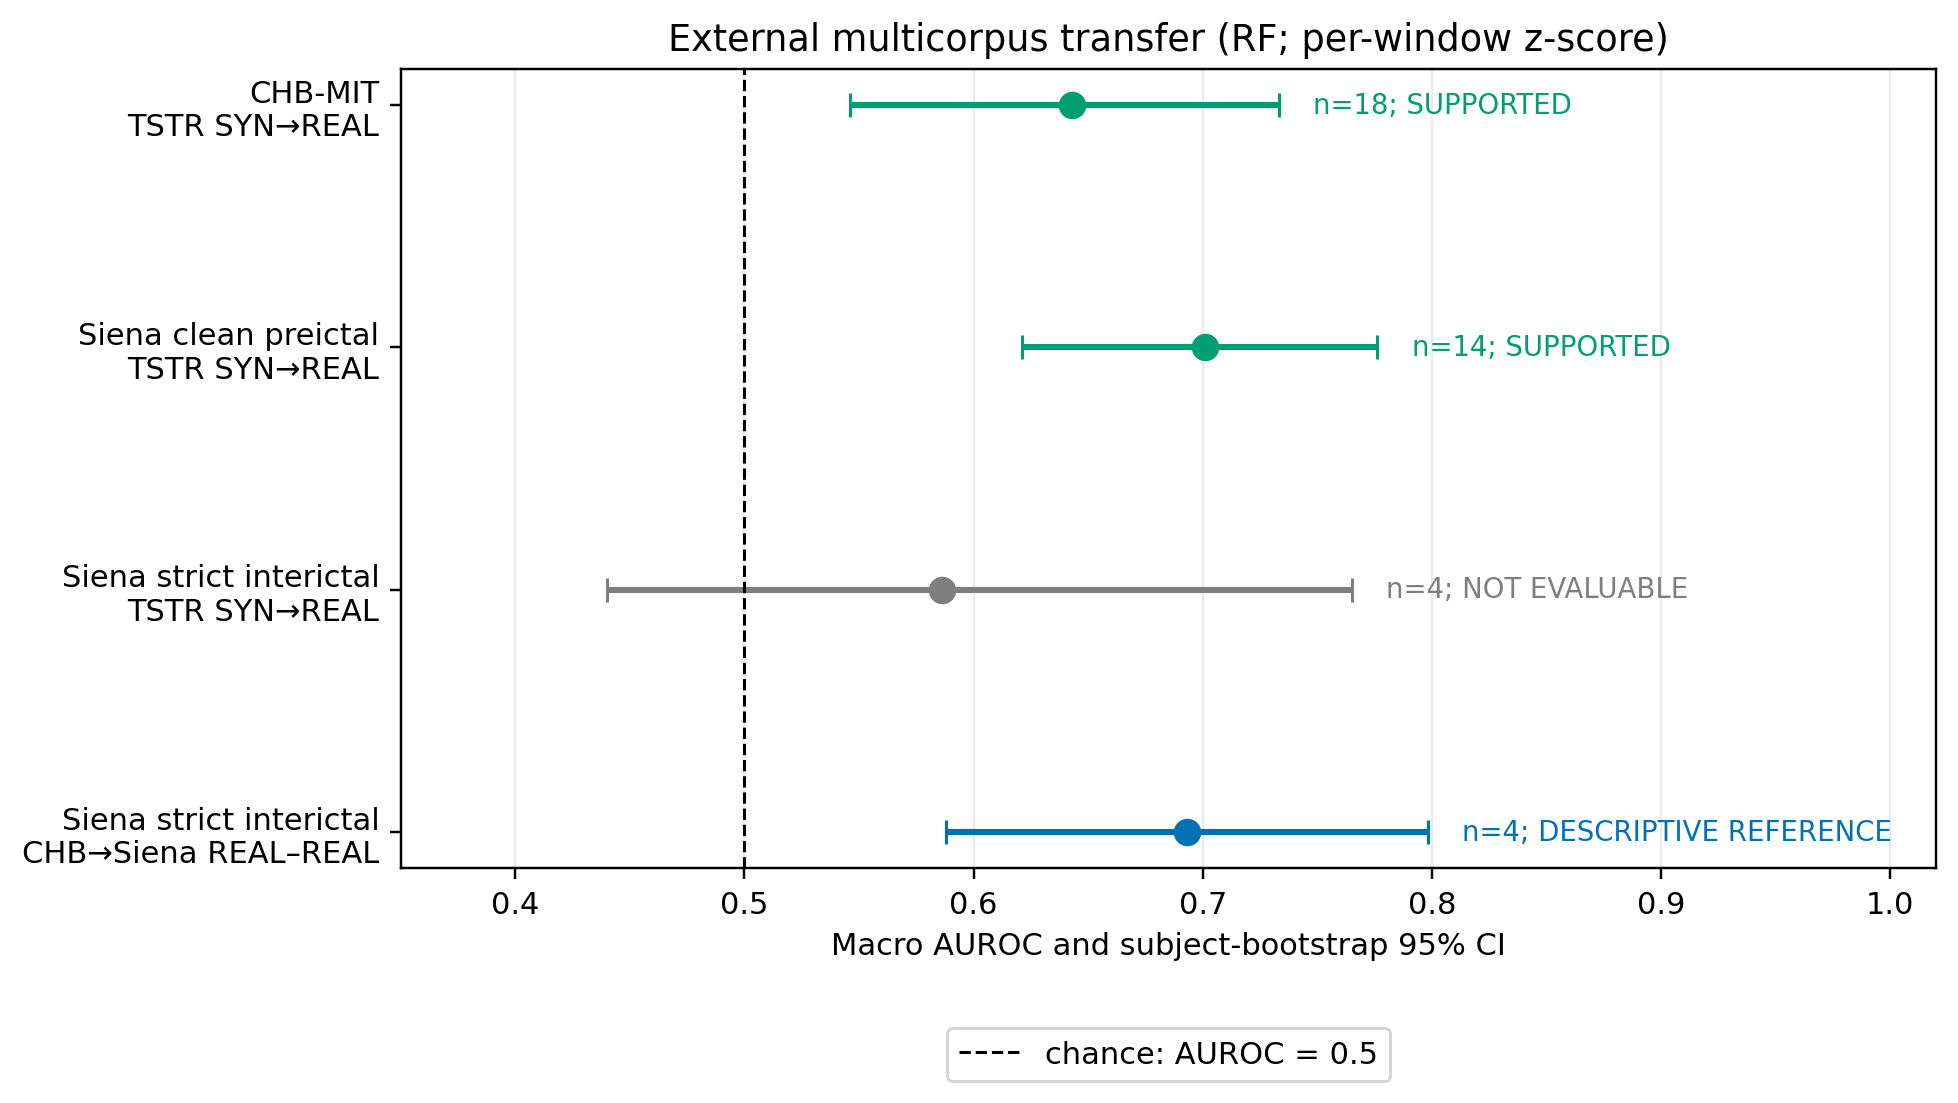

[Bloque 9] figura lista: 16_fig_auroc_forest (PNG/PDF)


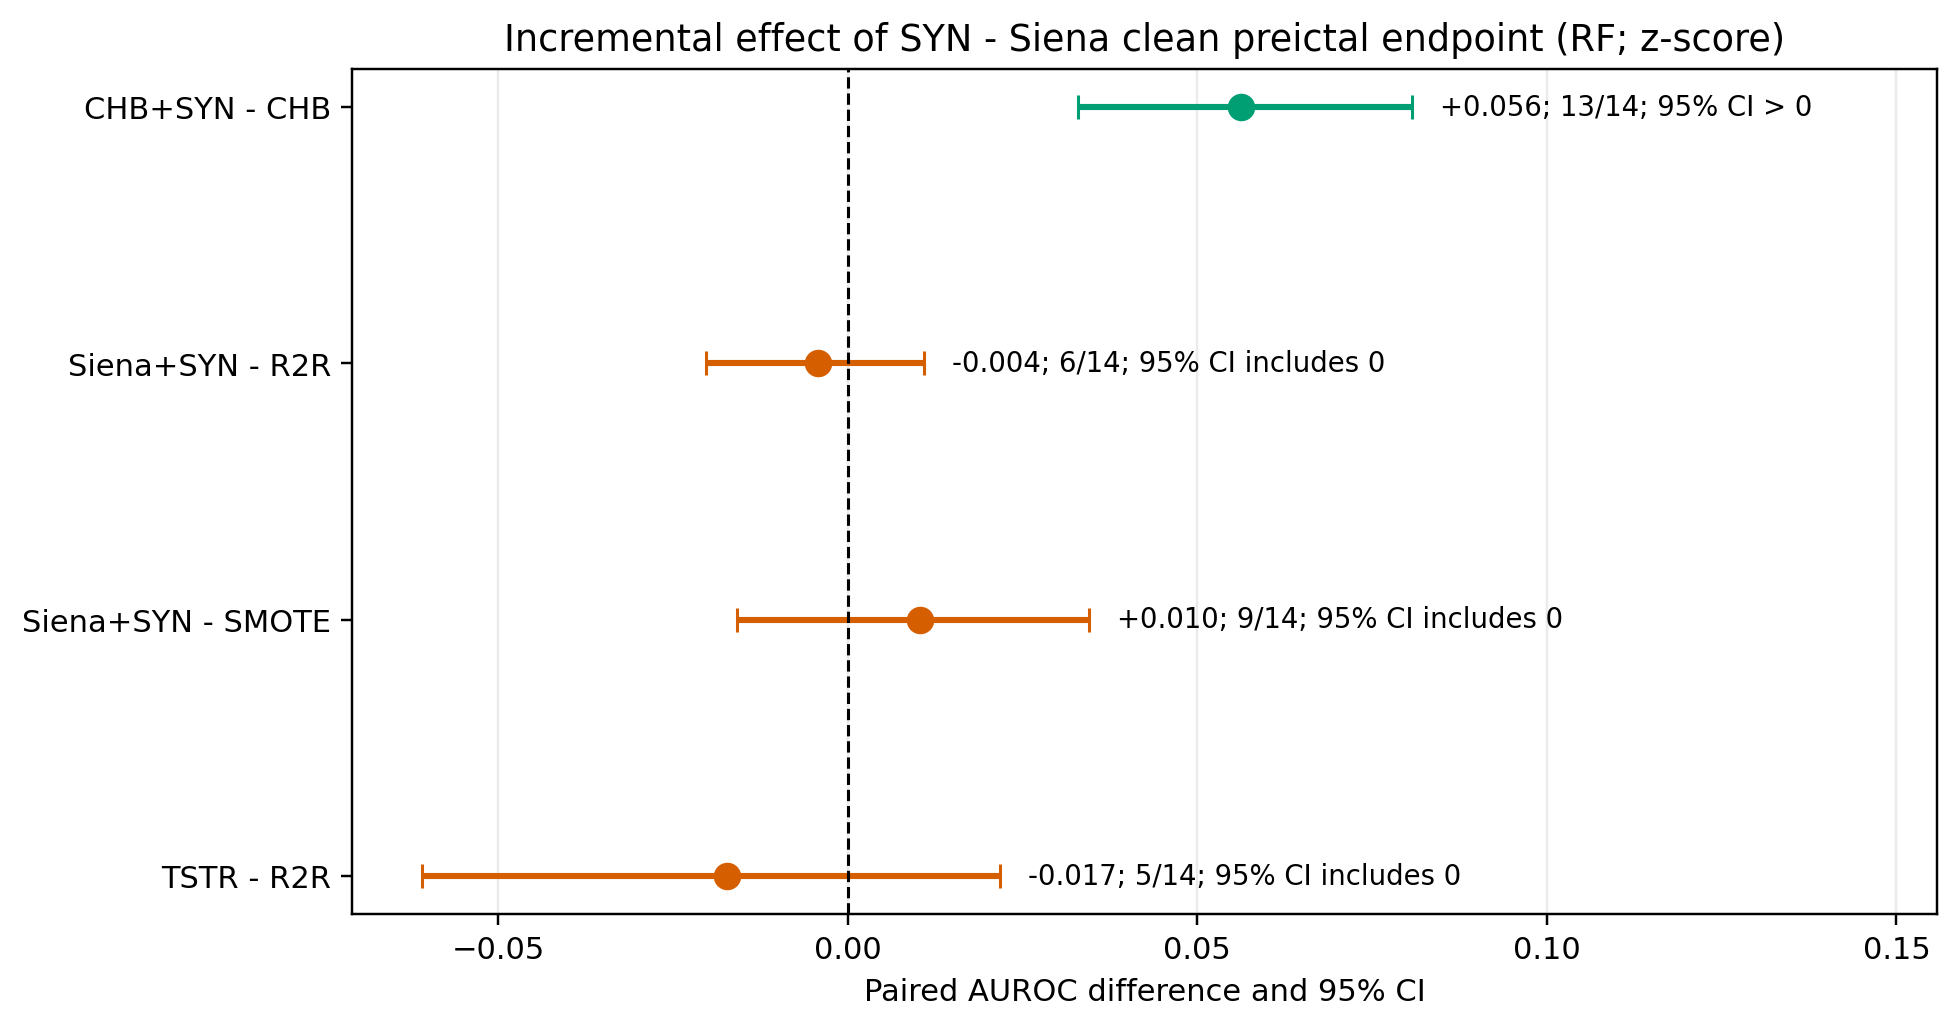

[Bloque 9] figura lista: 16_fig_syn_effect (PNG/PDF)


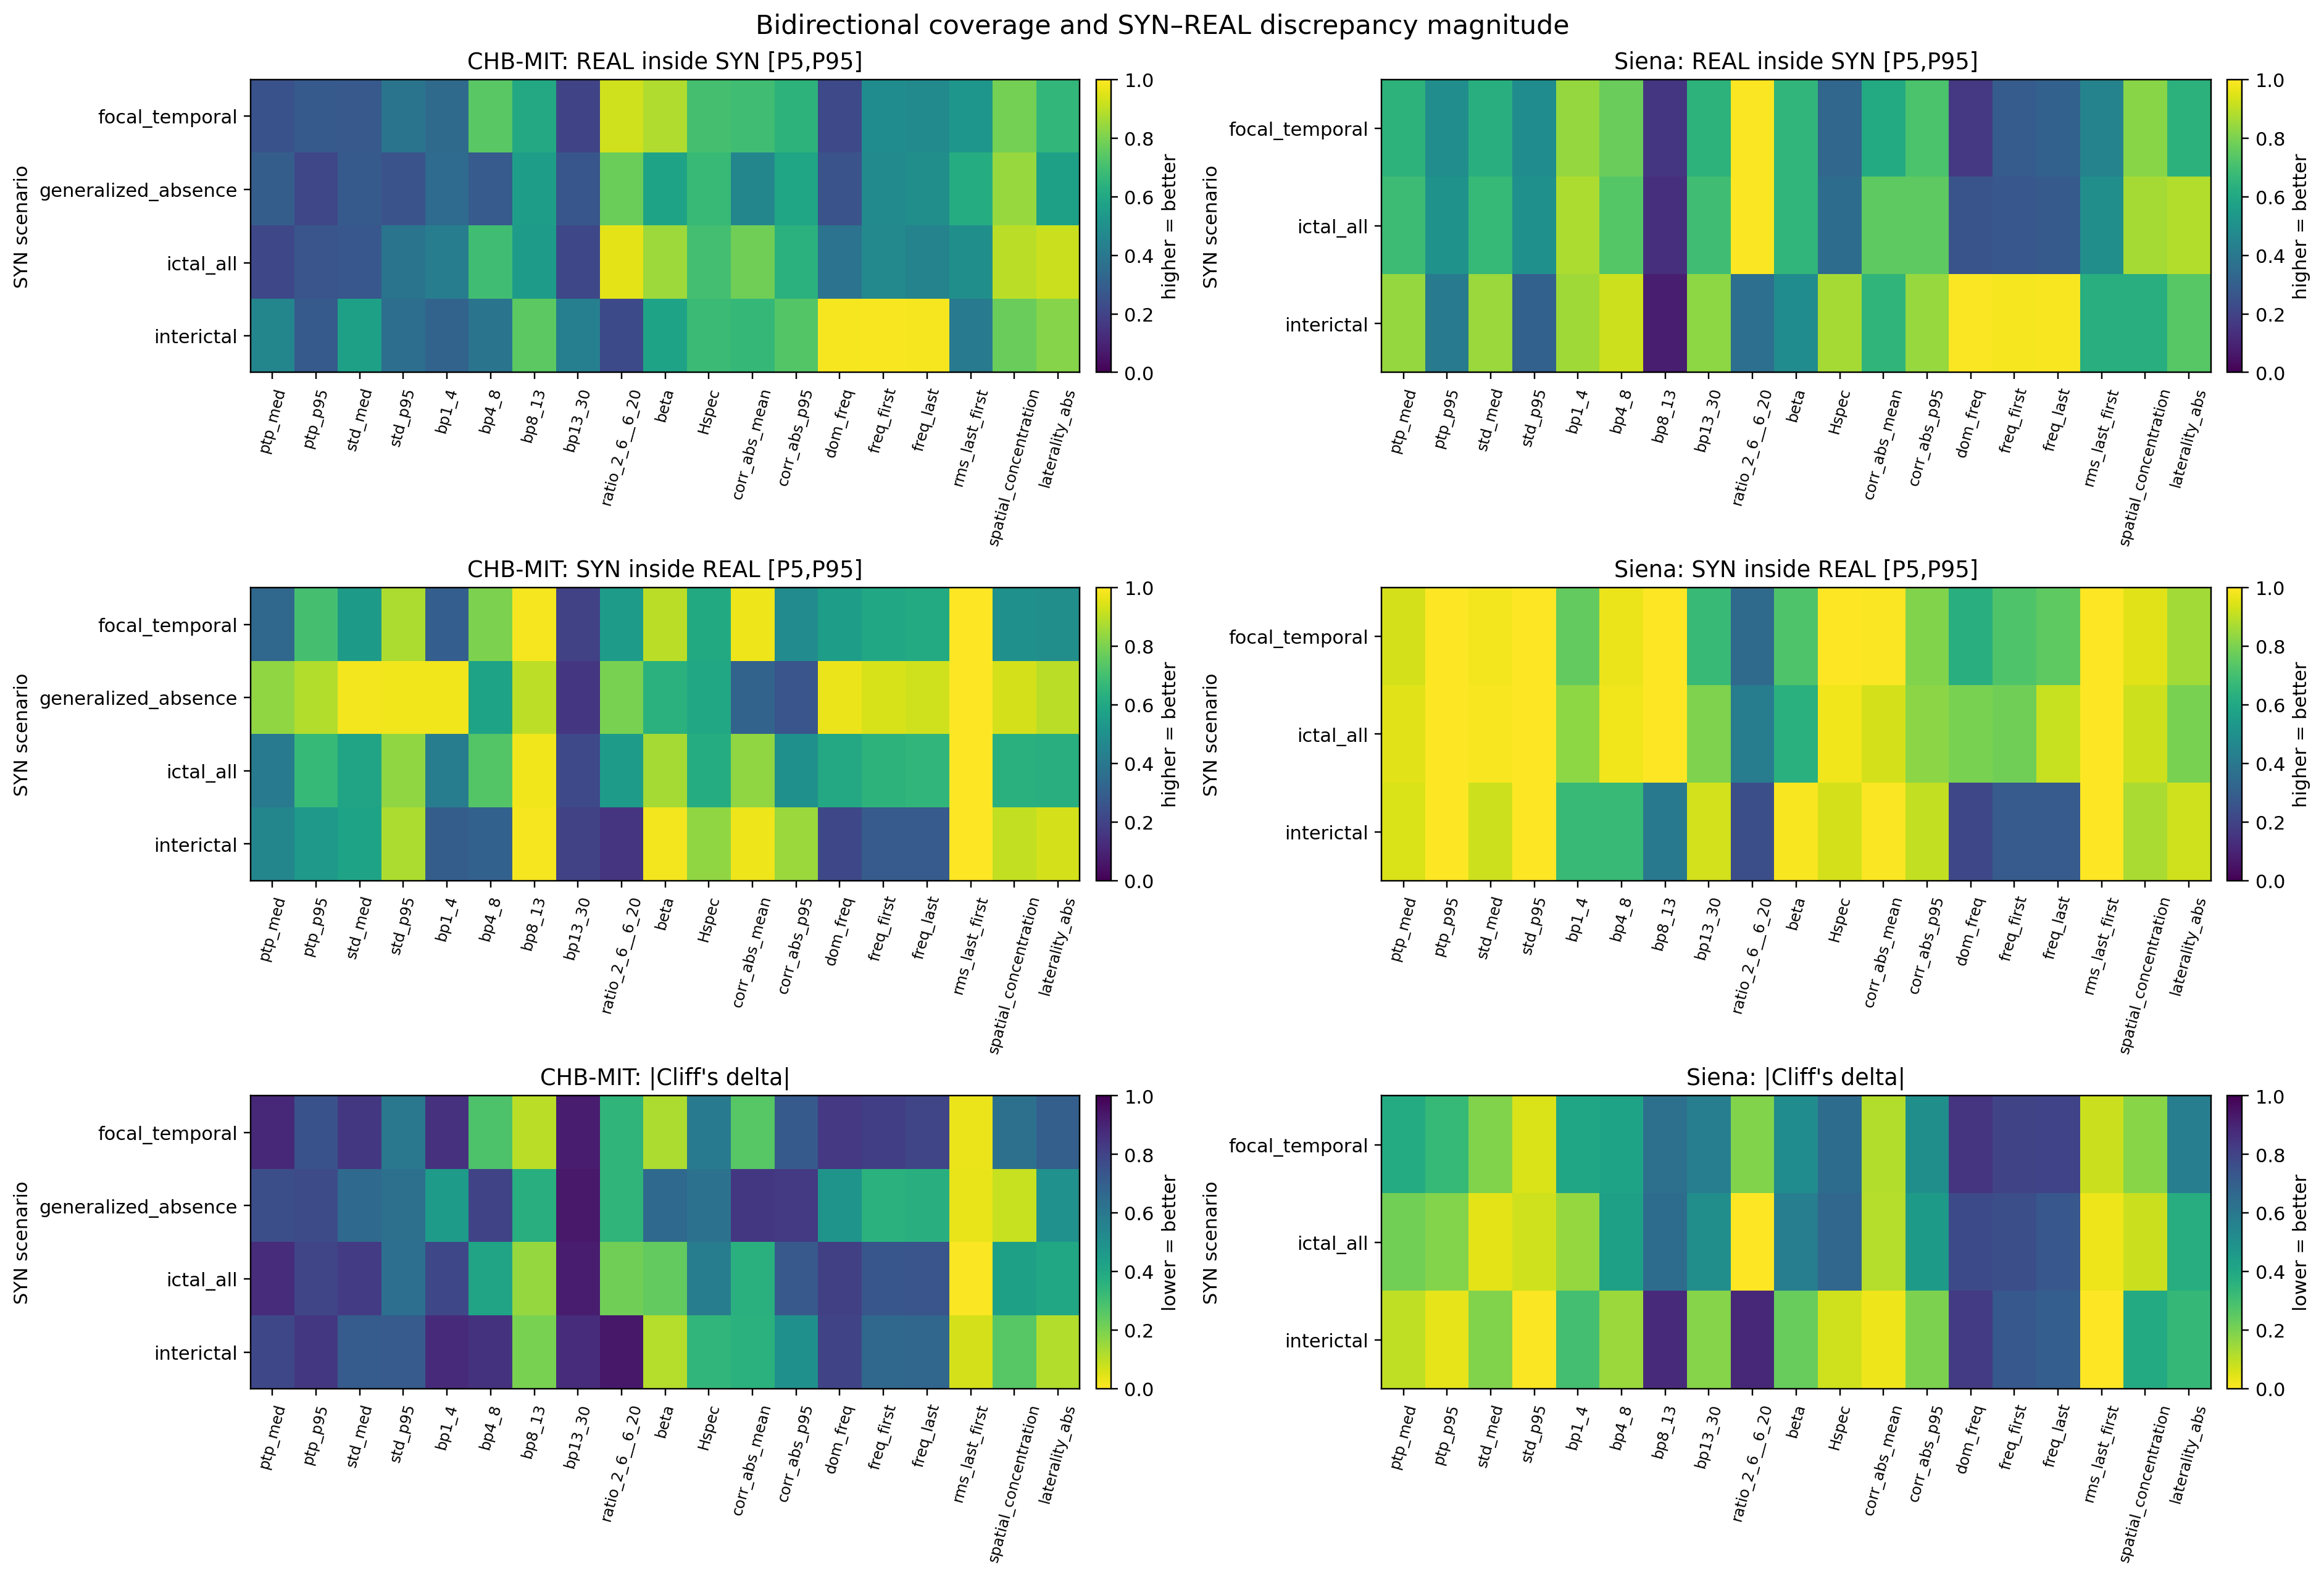

[Bloque 9] figura lista: 16_fig_morphology_fidelity (PNG/PDF)


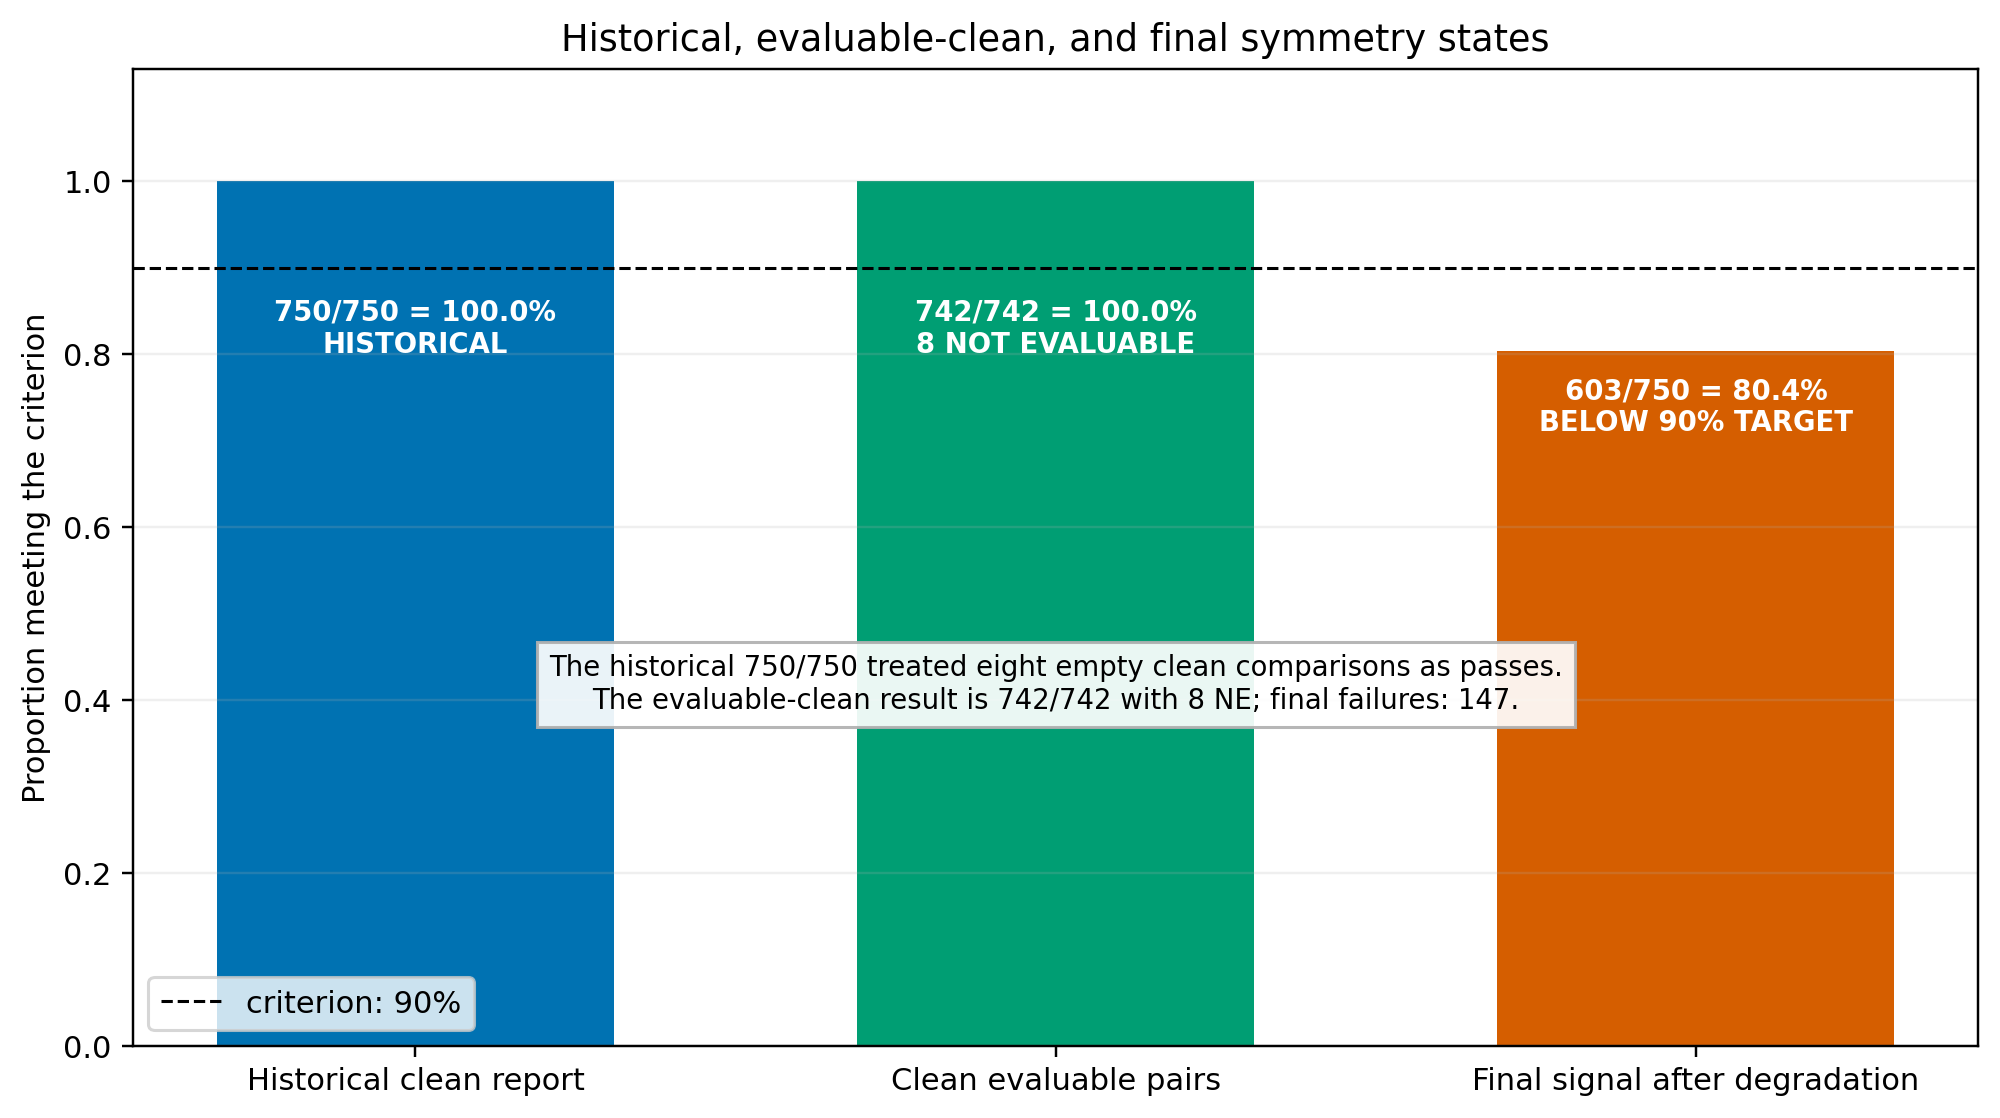

[Bloque 9] figura lista: 16_fig_symmetry_degradation (PNG/PDF)


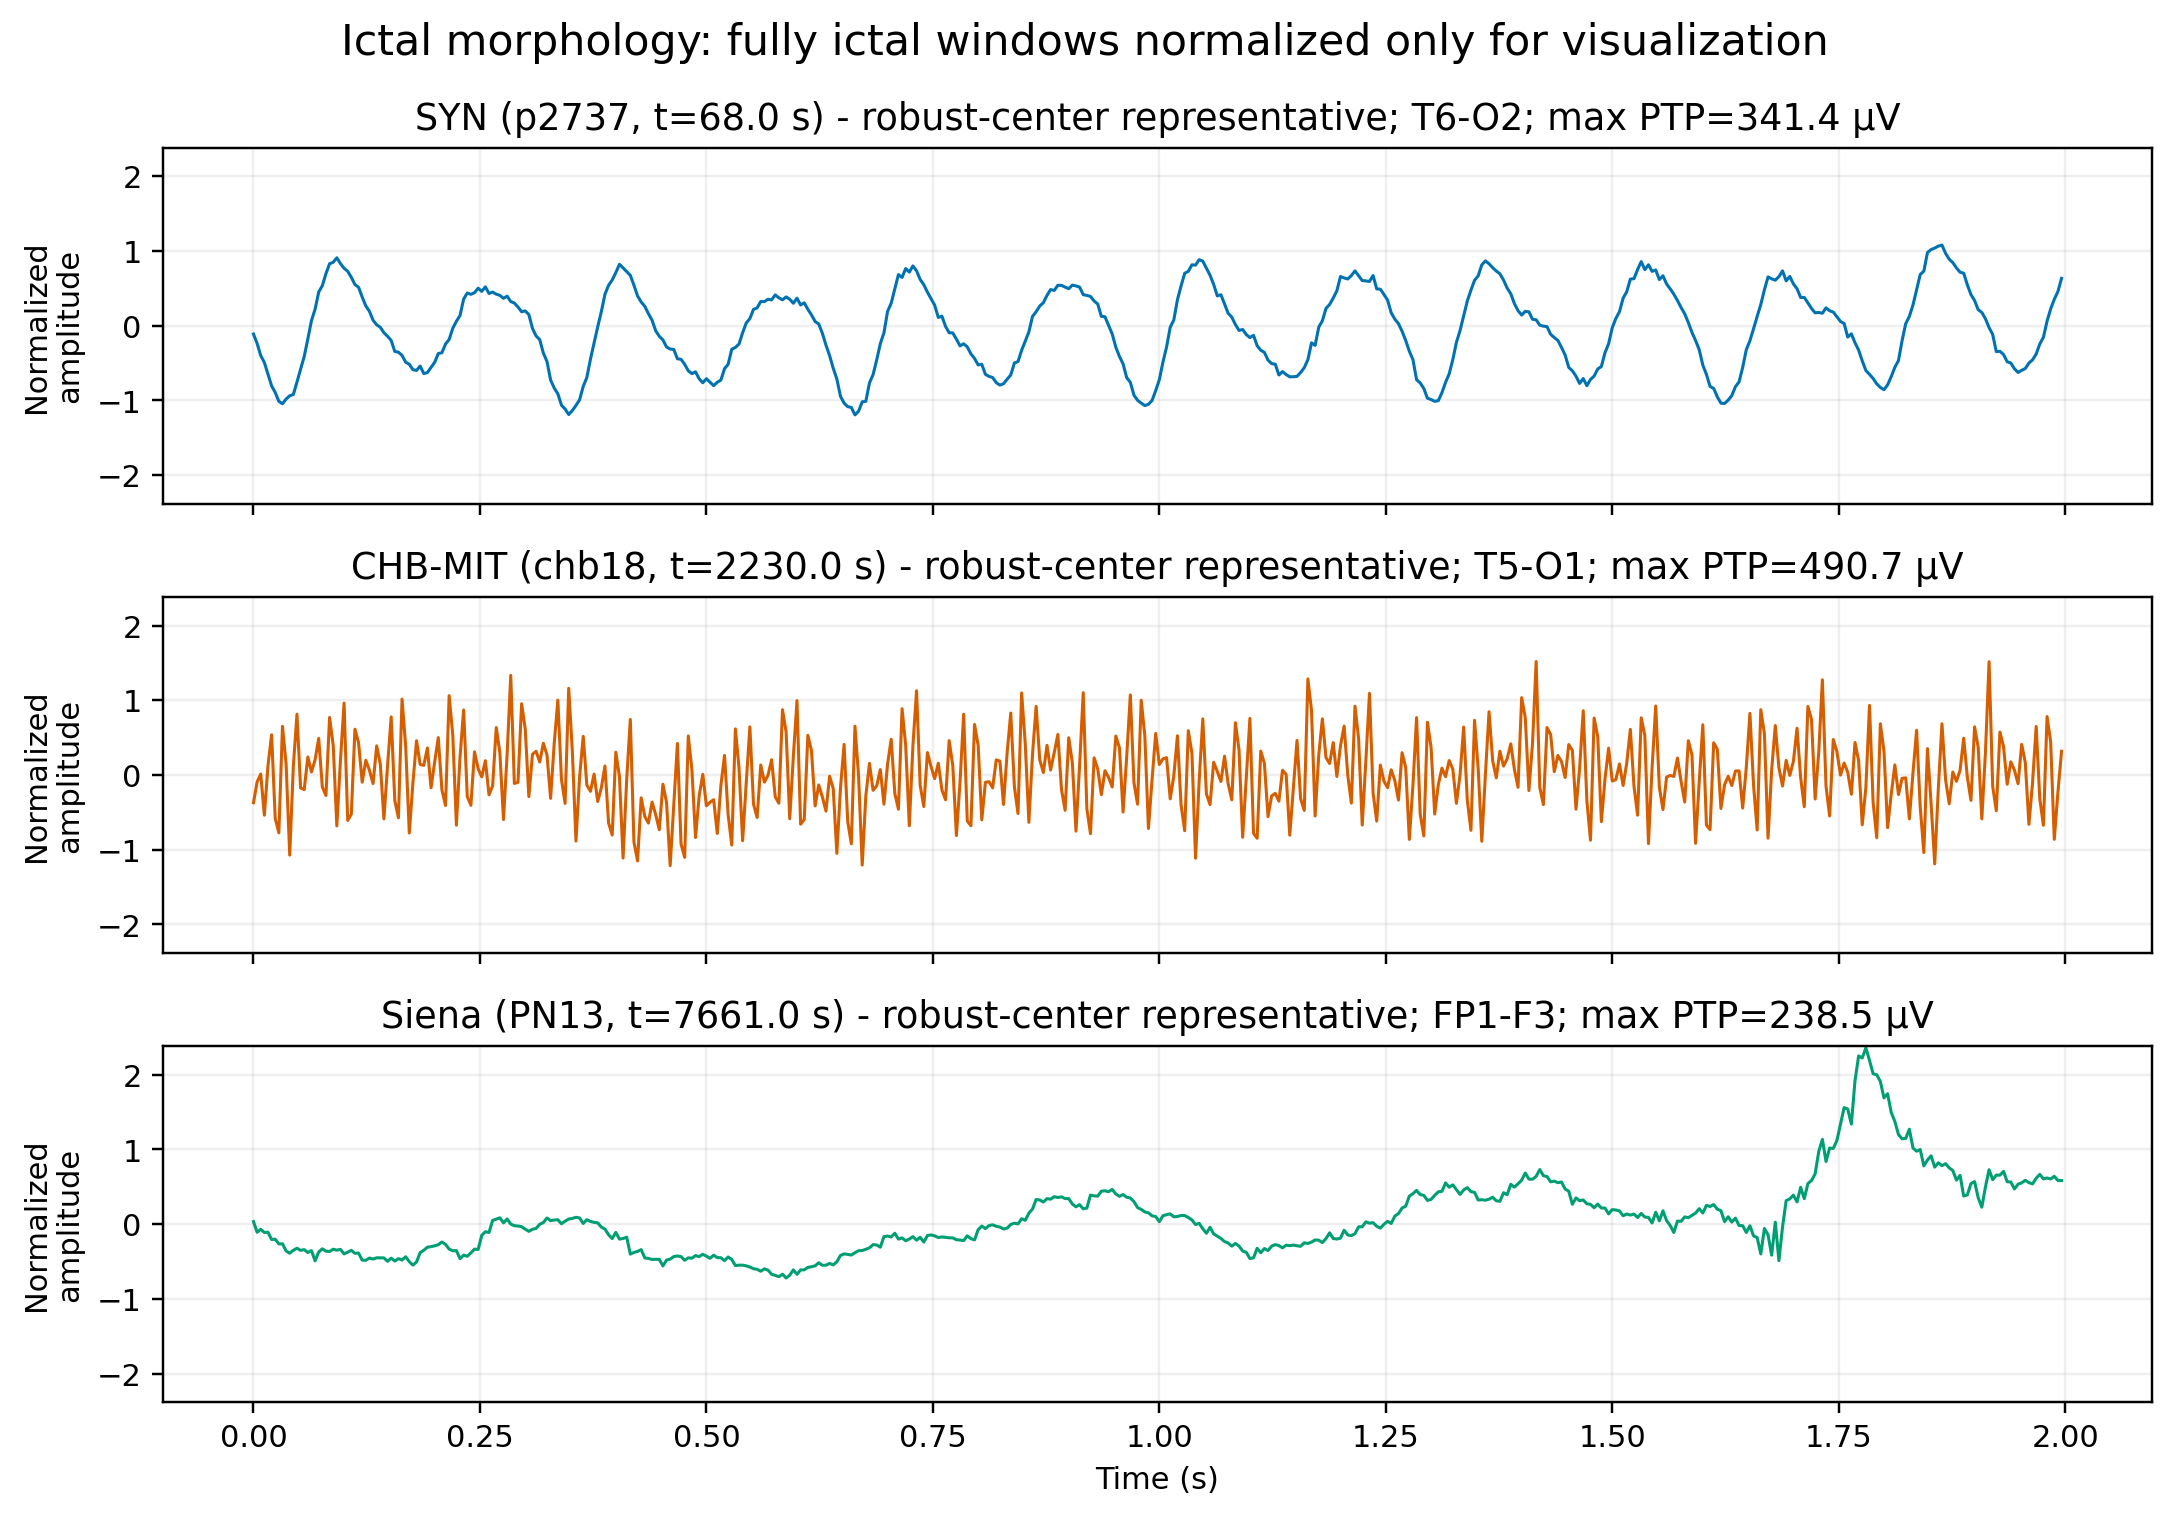

[Bloque 9] figura lista: 16_fig_signal_comparison (PNG/PDF)


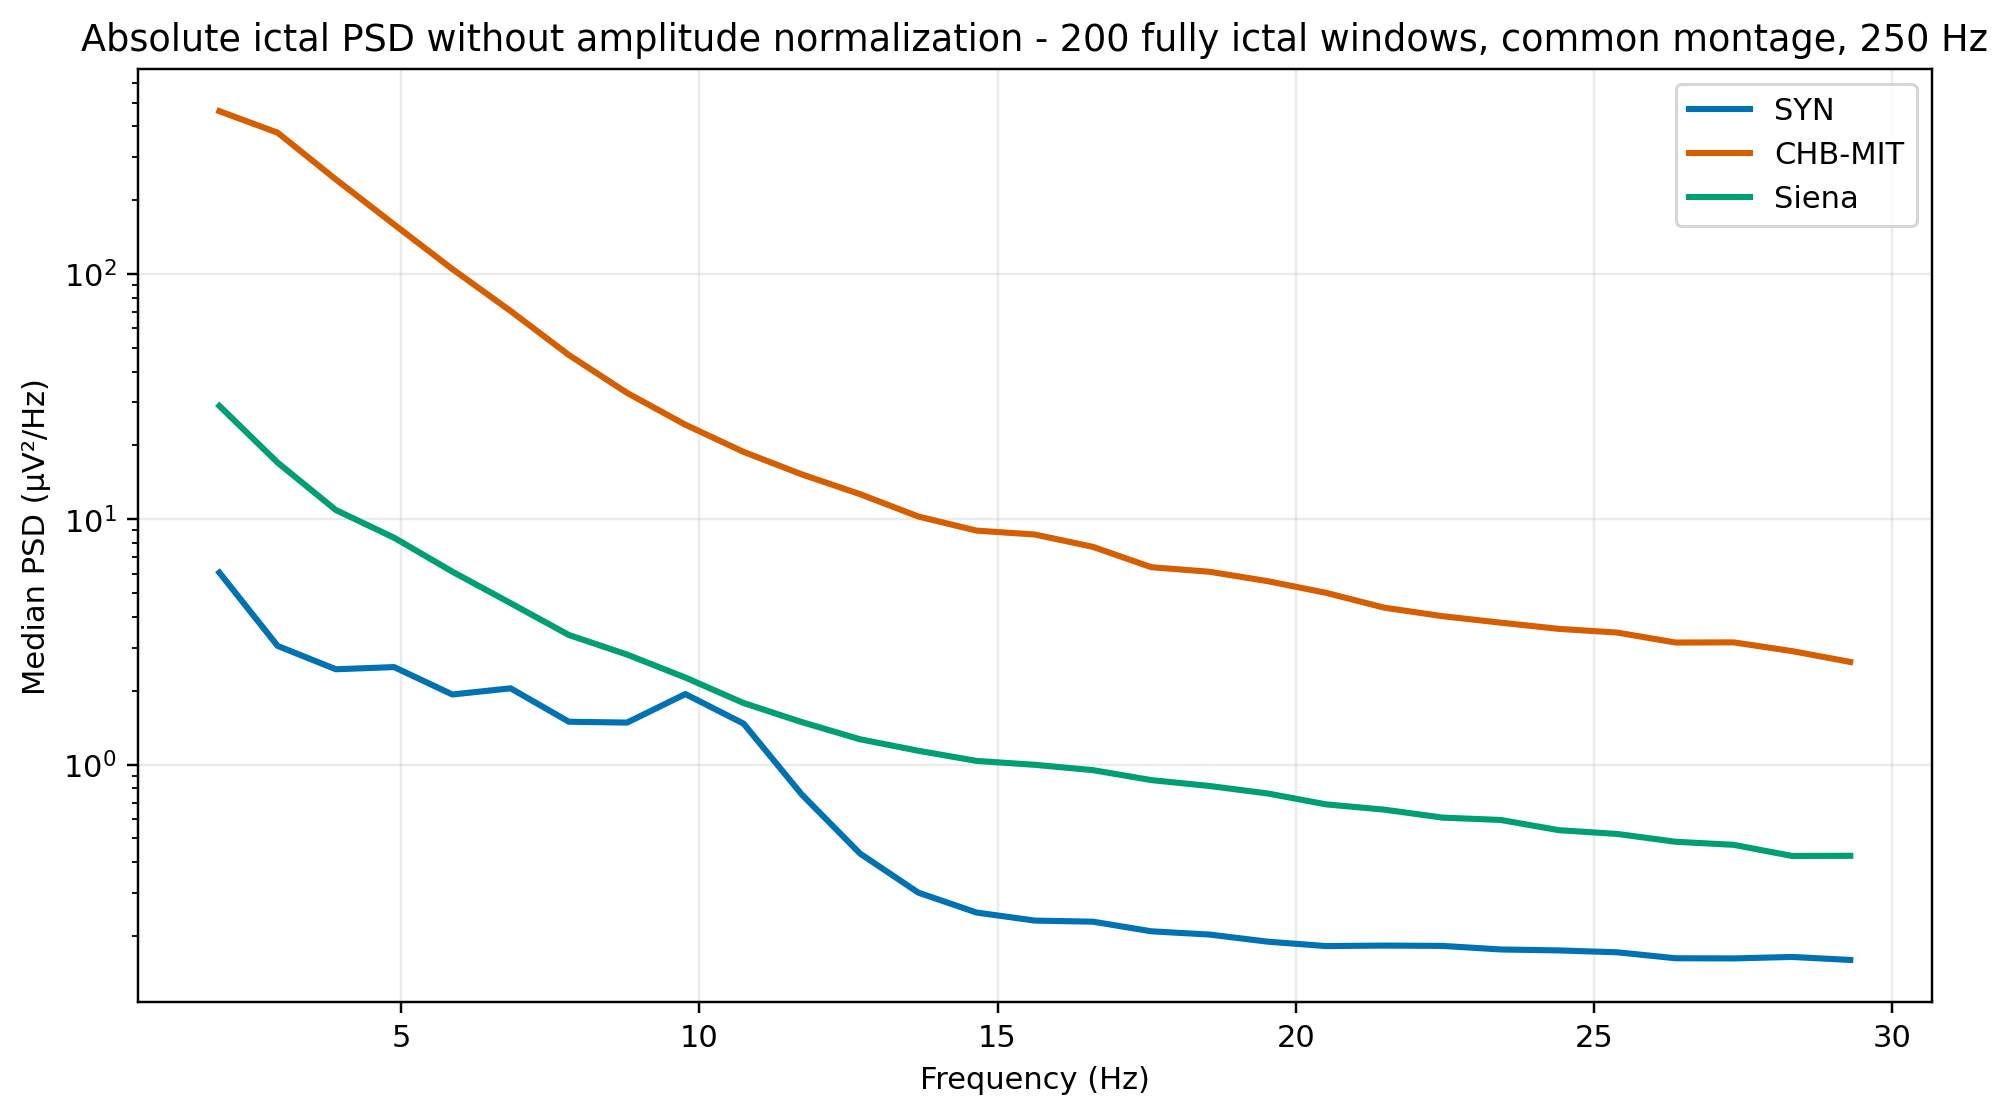

[Bloque 9] figura lista: 16_fig_psd_multicorpus (PNG/PDF)


**Productos de publicación: SUPPORTED.** Se guardaron tabla, leyendas, PNG, PDF y manifiesto con hashes.

[Bloque 9] seis figuras listas; iniciando auditoria de hashes y contratos


[Bloque 9] fuentes y productos verificados; comprobando contratos numericos


[Bloque 9] auditoria interna sin fallos; verificando migracion


**Accepted reference verified exactly.** No published product was modified.

[Run All] verificacion completada UTC: 2026-08-11T09:49:14Z


[Run All] lock liberado; ejecucion finalizada


In [10]:
# BLOQUE 9 — productos reproducibles para tesis y artículo
from IPython.display import Image, Markdown, display
import matplotlib.pyplot as plt

def migrate_symmetry_summary_traceability(path):
    path=Path(path)
    summary=json.loads(path.read_text(encoding="utf-8"))
    required={"generated_utc","source_generation_manifest_sha256","detail_csv","detail_csv_sha256"}
    missing=sorted(required-set(summary))
    if missing: raise RuntimeError("07 symmetry summary lacks required frozen fields: "+str(missing))
    prior_record=((PUBLISHED_AUDIT_SNAPSHOT or {}).get("source_migration",{}).get("symmetry_summary_trace_migration",{}))
    historical_file_sha=summary.get("validator_notebook_sha256",prior_record.get("historical_validator_notebook_file_sha256"))
    migrated={}
    for key,value in summary.items():
        if key in {"validator_notebook_sha256","validator_notebook_code_sha256","validator_notebook_hash_scope","traceability_migration_id"}: continue
        migrated[key]=("2.1-symmetry-evaluability-audit-code-hash" if key=="schema_version" else value)
        if key=="source_generation_manifest_sha256":
            migrated["validator_notebook_code_sha256"]=notebook_code_sha256(PROJECT_ROOT/"1_0_EEGSynthesizer_DATASET.ipynb")
            migrated["validator_notebook_hash_scope"]=NOTEBOOK_HASH_SCOPE
            migrated["traceability_migration_id"]=VALIDATION_MIGRATION_ID
    if migrated.get("schema_version")!="2.1-symmetry-evaluability-audit-code-hash": raise RuntimeError("07 symmetry schema migration failed")
    atomic_write_json(path,migrated)
    return {"status":"MIGRATED","historical_validator_notebook_file_sha256":historical_file_sha,
      "validator_notebook_code_sha256":migrated["validator_notebook_code_sha256"],"notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
      "generated_utc_frozen":migrated["generated_utc"]}

SYMMETRY_TRACE_MIGRATION=None
if MODE=="siena_external":
    SYMMETRY_TRACE_MIGRATION=migrate_symmetry_summary_traceability(OUT_DIR/"07_generalized_symmetry_summary.json")
    print("[Bloque 9] trazabilidad 07 preparada en staging; resultados científicos intactos",flush=True)

PUBLICATION_SOURCE_FILES = [
    "02_fidelity_featurewise.csv",
    "02b_morphology_coverage.csv",
    "03_cross_domain_loso.csv",
    "03b_cross_domain_bootstrap.csv",
    "05_final_summary.json",
    "07_generalized_symmetry_by_patient.csv",
    "07_generalized_symmetry_summary.json",
    "09_siena_fidelity_featurewise.csv",
    "09_siena_morphology_coverage.csv",
    "10_siena_real_real_by_subject.csv",
    "10_siena_real_real_reference.csv",
    "10_siena_mmd_by_subject.csv",
    "12_siena_laterality_audit.csv",
    "13_multicorpus_final_summary.json",
    "14_siena_ictal_preictal_integrity.json",
    "14_siena_ictal_preictal_paired_differences.csv",
]

PUBLICATION_FIGURES = [
    "16_fig_auroc_forest",
    "16_fig_syn_effect",
    "16_fig_morphology_fidelity",
    "16_fig_signal_comparison",
    "16_fig_psd_multicorpus",
    "16_fig_symmetry_degradation",
]

PUBLICATION_COLORS = {"SYN":"#0072B2", "CHB-MIT":"#D55E00", "Siena":"#009E73",
                      "SUPPORTED":"#009E73", "NOT SUPPORTED":"#D55E00",
                      "NOT EVALUABLE":"#7F7F7F", "REPORTED":"#0072B2"}
PUBLICATION_STATUS_LABELS = {"SUPPORTED":"SUPPORTED","NOT SUPPORTED":"FULL CRITERION NOT MET",
                             "NOT EVALUABLE":"NOT EVALUABLE","REPORTED":"DESCRIPTIVE REFERENCE"}

def save_publication_figure(fig, stem):
    png=OUT_DIR/f"{stem}.png"; pdf=OUT_DIR/f"{stem}.pdf"
    fig.savefig(png,dpi=220,bbox_inches="tight",facecolor="white")
    fig.savefig(pdf,bbox_inches="tight",facecolor="white",
                metadata={"Creator":"EEGSynthesizer","CreationDate":None,"ModDate":None})
    plt.close(fig); display(Image(filename=str(png)))
    print(f"[Bloque 9] figura lista: {stem} (PNG/PDF)",flush=True)
    return [png,pdf]

def publication_robust_center_representative(batch):
    features=np.asarray([one_feature(window,zscore=True) for window in batch],dtype=np.float64)
    center=np.median(features,axis=0)
    scale=stats.median_abs_deviation(features,axis=0,scale="normal")+1e-9
    return int(np.argmin(np.sum(((features-center)/scale)**2,axis=1)))

def publication_ictal_batches(n_pool=200):
    rng=np.random.default_rng(20260804)
    Xsyn=np.load(SYN_DIR/"X_test.npy",mmap_mode="r"); ysyn=np.load(SYN_DIR/"y_test.npy"); msyn=pd.read_csv(SYN_DIR/"window_metadata_test.csv")
    Xchb=np.load(REAL_DIR/"X_real.npy",mmap_mode="r"); ychb=np.load(REAL_DIR/"y_real.npy"); pchb=np.load(REAL_DIR/"pid_real.npy"); mchb=pd.read_csv(REAL_DIR/"real_window_metadata.csv")
    Xsiena=np.load(REAL_DIR/"siena_X.npy",mmap_mode="r"); ysiena=np.load(REAL_DIR/"siena_y.npy"); msiena=pd.read_csv(REAL_DIR/"siena_window_metadata.csv")
    external_chb=~np.isin(pchb.astype(str),sorted(DEV_CASES))
    specifications=[("SYN",Xsyn,np.flatnonzero((ysyn==1)&(msyn.ictal_fraction.to_numpy()>=0.999)),True),
                    ("CHB-MIT",Xchb,np.flatnonzero((ychb==1)&external_chb&(mchb.ictal_fraction.to_numpy()>=0.999)),False),
                    ("Siena",Xsiena,np.flatnonzero((ysiena==1)&(msiena.ictal_fraction.to_numpy()>=0.999)),False)]
    batches={}; selected_indices={}
    for domain,array,indices,is_referential in specifications:
        if len(indices)==0: raise RuntimeError(f"No hay ventanas ictales para {domain}")
        selected=rng.choice(indices,min(n_pool,len(indices)),replace=False)
        batch=np.asarray(array[selected],dtype=np.float32)
        if is_referential: batch=synthetic_to_bipolar(batch)
        if batch.shape[1:]!=(WIN_PTS,len(BIPOLAR)): raise RuntimeError(f"Forma inesperada para {domain}: {batch.shape}")
        if not np.isfinite(batch).all(): raise RuntimeError(f"NaN/Inf en lote gráfico {domain}")
        batches[domain]=batch; selected_indices[domain]=selected.astype(int)
    return batches,selected_indices

missing_publication_sources=[name for name in PUBLICATION_SOURCE_FILES if not (OUT_DIR/name).exists()]
heavy_publication_sources=[SYN_DIR/"X_test.npy",SYN_DIR/"y_test.npy",SYN_DIR/"window_metadata_test.csv",
                           REAL_DIR/"X_real.npy",REAL_DIR/"y_real.npy",REAL_DIR/"pid_real.npy",REAL_DIR/"real_window_metadata.csv",
                           REAL_DIR/"siena_X.npy",REAL_DIR/"siena_y.npy",REAL_DIR/"siena_window_metadata.csv"]
missing_heavy=[path.name for path in heavy_publication_sources if not path.exists()]

if MODE=="status":
    print("STATUS: inspección finalizada; no se descargaron, recalcularon ni modificaron artefactos.")
elif MODE!="siena_external":
    print("Block 9 skipped: complete publication products are generated only in siena_external staging.")
elif missing_publication_sources:
    raise RuntimeError("publication staging is incomplete: "+str(missing_publication_sources))
elif missing_heavy:
    raise RuntimeError("required heavy publication sources are missing: "+str(missing_heavy))
else:
    print("[Bloque 9] cargando fuentes y construyendo tabla",flush=True)
    summary_chb=json.loads((OUT_DIR/"05_final_summary.json").read_text(encoding="utf-8"))
    summary_multi=json.loads((OUT_DIR/"13_multicorpus_final_summary.json").read_text(encoding="utf-8"))
    summary_pre=json.loads((OUT_DIR/"14_siena_ictal_preictal_integrity.json").read_text(encoding="utf-8"))
    symmetry=json.loads((OUT_DIR/"07_generalized_symmetry_summary.json").read_text(encoding="utf-8"))
    paired=pd.read_csv(OUT_DIR/"14_siena_ictal_preictal_paired_differences.csv")
    laterality=pd.read_csv(OUT_DIR/"12_siena_laterality_audit.csv"); n_laterality=int(laterality.evaluable.astype(bool).sum())
    n_correct_laterality=int(laterality.loc[laterality.evaluable.astype(bool),"correct"].astype(bool).sum())

    chb=summary_chb["claims"]["external_TSTR_RF_zscore"]
    pre=summary_pre["TSTR_RF_zscore"]
    strict=summary_multi["siena_TSTR_RF_zscore"]
    aggregated_ictal=summary_multi["aggregated_siena_ictal_external"]
    focal=summary_multi["focal_temporal_external"]
    n_covered_features=int(aggregated_ictal["features_within_real_real_q95"]); n_evaluable_features=int(aggregated_ictal["features_evaluable"]); n_ne_features=int(aggregated_ictal["features_not_evaluable"])
    improvement=paired.loc[paired.comparison=="CHB_PLUS_SYN_minus_CHB"].iloc[0]
    publication_table=pd.DataFrame([
      {"Corpus":"CHB-MIT","Endpoint":"ictal vs. interictal","Estimando":"AUROC TSTR (RF; z-score/ventana)","Estimación":chb["macro_auc"],
       "IC95_inf":chb["ci95"][0],"IC95_sup":chb["ci95"][1],"Unidad/N":f"{chb['n_subjects']} sujetos","Resultado":PUBLICATION_STATUS_LABELS.get(chb["status"],chb["status"])},
      {"Corpus":"Siena","Endpoint":"ictal vs. preictal limpio (30-5 min; postictal excluido)","Estimando":"AUROC TSTR (RF; z-score/ventana)","Estimación":pre["macro_auc"],
       "IC95_inf":pre["ci95"][0],"IC95_sup":pre["ci95"][1],"Unidad/N":f"{pre['n_subjects']} sujetos","Resultado":PUBLICATION_STATUS_LABELS.get(pre["status"],pre["status"])},
      {"Corpus":"Siena","Endpoint":"ictal vs. interictal estricto","Estimando":"AUROC TSTR (RF; z-score/ventana)","Estimación":strict["macro_auc"],
       "IC95_inf":strict["ci95"][0],"IC95_sup":strict["ci95"][1],"Unidad/N":f"{strict['n_subjects']} sujetos","Resultado":"Estimación exploratoria: n < 10"},
      {"Corpus":"Siena","Endpoint":"ictal vs. preictal limpio (30-5 min; postictal excluido)","Estimando":"ΔAUROC CHB+SYN-CHB (RF; z-score/ventana)","Estimación":improvement.mean_auc_difference,
       "IC95_inf":improvement.ci95_low,"IC95_sup":improvement.ci95_high,"Unidad/N":f"{int(improvement.n_subjects)} sujetos","Resultado":PUBLICATION_STATUS_LABELS.get(improvement.status,improvement.status)},
      {"Corpus":"Siena","Endpoint":"ictal agregado","Estimando":"Mediana Wasserstein/IQR REAL-train dentro de q95 REAL-REAL","Estimación":aggregated_ictal["features_within_real_real_q95_fraction"],
       "IC95_inf":np.nan,"IC95_sup":np.nan,"Unidad/N":f"{n_evaluable_features} rasgos evaluables","Resultado":f"Dentro {n_covered_features}/{n_evaluable_features}; NE={n_ne_features}; criterio completo 19/19"},
      {"Corpus":"Siena","Endpoint":"lateralidad focal temporal","Estimando":"exactitud de lateralidad","Estimación":focal["laterality_accuracy"],
       "IC95_inf":np.nan,"IC95_sup":np.nan,"Unidad/N":f"{n_laterality} sujetos evaluables","Resultado":f"Descriptivo: concordancia {n_correct_laterality}/{n_laterality}; sin umbral confirmatorio"},
    ])
    publication_table.to_csv(OUT_DIR/"16_publication_multicorpus_table.csv",index=False)
    (OUT_DIR/"16_publication_multicorpus_table.tex").write_text(
        publication_table.to_latex(index=False,float_format=lambda value:f"{value:.4f}",na_rep="--"),encoding="utf-8")
    display(Markdown("## Tabla comparativa multicorpus"))
    display(publication_table.style.format({"Estimación":"{:.4f}","IC95_inf":"{:.4f}","IC95_sup":"{:.4f}"},na_rep="--"))
    print("[Bloque 9] tabla multicorpus lista",flush=True)

    # Forest plot de AUROC. Los endpoints se mantienen explícitos porque no son intercambiables.
    rr=summary_multi["siena_protocols_RF_zscore"]["CHB_TO_SIENA_REAL_REAL"]
    forest=pd.DataFrame([
      {"label":"CHB-MIT\nTSTR SYN→REAL","mean":chb["macro_auc"],"low":chb["ci95"][0],"high":chb["ci95"][1],"n":chb["n_subjects"],"status":chb["status"]},
      {"label":"Siena clean preictal\nTSTR SYN→REAL","mean":pre["macro_auc"],"low":pre["ci95"][0],"high":pre["ci95"][1],"n":pre["n_subjects"],"status":pre["status"]},
      {"label":"Siena strict interictal\nTSTR SYN→REAL","mean":strict["macro_auc"],"low":strict["ci95"][0],"high":strict["ci95"][1],"n":strict["n_subjects"],"status":strict["status"]},
      {"label":"Siena strict interictal\nCHB→Siena REAL–REAL","mean":rr["macro_auc"],"low":rr["ci95_low"],"high":rr["ci95_high"],"n":rr["n_subjects"],"status":"REPORTED"},
    ])
    fig,ax=plt.subplots(figsize=(9,5.2)); y=np.arange(len(forest))[::-1]
    for yi,row in zip(y,forest.itertuples()):
        color=PUBLICATION_COLORS.get(row.status,"#0072B2")
        ax.errorbar(row.mean,yi,xerr=[[row.mean-row.low],[row.high-row.mean]],fmt="o",ms=8,capsize=4,color=color,lw=2)
        ax.text(min(0.82,row.high+0.015),yi,f"n={row.n}; {PUBLICATION_STATUS_LABELS.get(row.status,row.status)}",va="center",fontsize=9,color=color)
    ax.axvline(.5,color="black",ls="--",lw=1,label="chance: AUROC = 0.5")
    ax.set(yticks=y,yticklabels=forest.label,xlim=(.35,1.02),xlabel="Macro AUROC and subject-bootstrap 95% CI",
           title="External multicorpus transfer (RF; per-window z-score)")
    ax.grid(axis="x",alpha=.25); ax.legend(loc="upper center",bbox_to_anchor=(.5,-.18)); fig.tight_layout()
    save_publication_figure(fig,"16_fig_auroc_forest")

    # Efectos pareados de añadir SYN en el endpoint Siena ictal-preictal.
    effect_order=["CHB_PLUS_SYN_minus_CHB","SIENA_PLUS_SYN_minus_R2R","SIENA_PLUS_SYN_minus_SMOTE","TSTR_minus_R2R"]
    effects=paired.set_index("comparison").loc[effect_order].reset_index()
    effect_labels={"CHB_PLUS_SYN_minus_CHB":"CHB+SYN - CHB","SIENA_PLUS_SYN_minus_R2R":"Siena+SYN - R2R",
                   "SIENA_PLUS_SYN_minus_SMOTE":"Siena+SYN - SMOTE","TSTR_minus_R2R":"TSTR - R2R"}
    fig,ax=plt.subplots(figsize=(9,4.8)); y=np.arange(len(effects))[::-1]
    for yi,row in zip(y,effects.itertuples()):
        color=PUBLICATION_COLORS.get(row.status,"#7F7F7F")
        ax.errorbar(row.mean_auc_difference,yi,
                    xerr=[[row.mean_auc_difference-row.ci95_low],[row.ci95_high-row.mean_auc_difference]],
                    fmt="o",ms=8,capsize=4,color=color,lw=2)
        interpretation=("95% CI > 0" if row.status=="SUPPORTED" else "95% CI includes 0")
        ax.text(row.ci95_high+.004,yi,f"{row.mean_auc_difference:+.3f}; {row.subjects_improved}/{row.n_subjects}; {interpretation}",va="center",fontsize=9)
    ax.axvline(0,color="black",ls="--",lw=1); ax.set_xlim(float(effects.ci95_low.min())-.01,float(effects.ci95_high.max())+.075); ax.set(yticks=y,yticklabels=[effect_labels[x] for x in effects.comparison],
      xlabel="Paired AUROC difference and 95% CI",title="Incremental effect of SYN - Siena clean preictal endpoint (RF; z-score)")
    ax.grid(axis="x",alpha=.25); fig.tight_layout(); save_publication_figure(fig,"16_fig_syn_effect")

    # Cobertura morfológica y fidelidad por corpus, clase y característica.
    chb_cov=pd.read_csv(OUT_DIR/"02b_morphology_coverage.csv"); siena_cov=pd.read_csv(OUT_DIR/"09_siena_morphology_coverage.csv")
    chb_fid=pd.read_csv(OUT_DIR/"02_fidelity_featurewise.csv"); siena_fid=pd.read_csv(OUT_DIR/"09_siena_fidelity_featurewise.csv")
    fig,axes=plt.subplots(3,2,figsize=(17,11.5),constrained_layout=True)
    panels=[(chb_cov,"real_inside_syn_05_95","CHB-MIT: REAL inside SYN [P5,P95]","coverage"),
            (siena_cov,"real_inside_syn_05_95","Siena: REAL inside SYN [P5,P95]","coverage"),
            (chb_cov,"syn_inside_real_05_95","CHB-MIT: SYN inside REAL [P5,P95]","coverage"),
            (siena_cov,"syn_inside_real_05_95","Siena: SYN inside REAL [P5,P95]","coverage"),
            (chb_fid,"cliffs_delta","CHB-MIT: |Cliff's delta|","effect"),
            (siena_fid,"cliffs_delta","Siena: |Cliff's delta|","effect")]
    for ax,(frame,value,title,kind) in zip(axes.flat,panels):
        matrix=frame.pivot(index="group",columns="feature",values=value).reindex(columns=FEATURE_NAMES)
        values=np.abs(matrix.to_numpy(dtype=float)) if kind=="effect" else matrix.to_numpy(dtype=float)
        image=ax.imshow(values,aspect="auto",vmin=0,vmax=1,cmap="viridis_r" if kind=="effect" else "viridis")
        ax.set(yticks=np.arange(len(matrix.index)),yticklabels=matrix.index,xticks=np.arange(len(matrix.columns)),xticklabels=matrix.columns,ylabel="SYN scenario")
        ax.tick_params(axis="x",rotation=75,labelsize=8); ax.set_title(title)
        colorbar=fig.colorbar(image,ax=ax,fraction=.025,pad=.02); colorbar.set_label("higher = better" if kind=="coverage" else "lower = better")
    fig.suptitle("Bidirectional coverage and SYN–REAL discrepancy magnitude",fontsize=14)
    save_publication_figure(fig,"16_fig_morphology_fidelity")

    # Historical, evaluable-clean, and final observable symmetry are distinct states.
    symmetry_detail_figure=pd.read_csv(OUT_DIR/"07_generalized_symmetry_by_patient.csv")
    symmetry_total=int(symmetry["n_generalized_events"]); historical_pass=int(symmetry["historical_indicator"]["pass_count"])
    clean_evaluable_mask=symmetry_detail_figure.clean_nondegraded_asymmetry.notna(); clean_evaluable_count=int(clean_evaluable_mask.sum())
    clean_pass_count=int(symmetry_detail_figure.loc[clean_evaluable_mask,"clean_nondegraded_symmetry_ok"].astype(bool).sum()); clean_ne_count=symmetry_total-clean_evaluable_count
    final_pass_detail=int(symmetry_detail_figure.final_all_channels_symmetry_ok.astype(bool).sum()); final_pass_summary=int(symmetry["final_all_channels"]["pass_count"])
    if (historical_pass,symmetry_total,clean_pass_count,clean_evaluable_count,clean_ne_count,final_pass_detail,final_pass_summary)!=(750,750,742,742,8,603,603):
        raise RuntimeError("symmetry source contract differs from historical 750/750, clean 742/742 + 8 NE, final 603/750")
    symmetry_labels=["Historical clean report","Clean evaluable pairs","Final signal after degradation"]
    symmetry_counts=[historical_pass,clean_pass_count,final_pass_detail]; symmetry_denominators=[symmetry_total,clean_evaluable_count,symmetry_total]
    symmetry_rates=[count/denominator for count,denominator in zip(symmetry_counts,symmetry_denominators)]
    symmetry_status=["REPORTED","SUPPORTED","NOT SUPPORTED"]; symmetry_display=["HISTORICAL","8 NOT EVALUABLE","BELOW 90% TARGET"]
    fig,ax=plt.subplots(figsize=(9.2,5.2)); bars=ax.bar(symmetry_labels,symmetry_rates,
      color=[PUBLICATION_COLORS.get(status,"#7F7F7F") for status in symmetry_status],width=.62)
    ax.axhline(symmetry["acceptance_rate"],color="black",ls="--",lw=1,label=f"criterion: {symmetry['acceptance_rate']:.0%}")
    for bar,rate,count,denominator,display_status in zip(bars,symmetry_rates,symmetry_counts,symmetry_denominators,symmetry_display):
        ypos=(symmetry["acceptance_rate"]-.035 if rate>=symmetry["acceptance_rate"] else rate-.03)
        ax.text(bar.get_x()+bar.get_width()/2,ypos,f"{count}/{denominator} = {rate:.1%}\n{display_status}",ha="center",va="top",color="white",fontweight="bold",fontsize=9)
    ax.text(.5,.37,f"The historical 750/750 treated eight empty clean comparisons as passes.\nThe evaluable-clean result is 742/742 with 8 NE; final failures: {symmetry_total-final_pass_detail}.",
            transform=ax.transAxes,ha="center",va="center",fontsize=9,bbox={"facecolor":"white","alpha":.92,"edgecolor":"#B0B0B0"})
    ax.set_ylim(0,1.13); ax.set_ylabel("Proportion meeting the criterion"); ax.set_title("Historical, evaluable-clean, and final symmetry states")
    ax.legend(loc="lower left"); ax.grid(axis="y",alpha=.2); fig.tight_layout(); save_publication_figure(fig,"16_fig_symmetry_degradation")

    generated_signal_outputs=[]
    if missing_heavy:
        print("Se omiten señales/PSD multicorpus; faltan artefactos pesados:",missing_heavy)
    else:
        batches,publication_indices=publication_ictal_batches()
        representative_positions={domain:publication_robust_center_representative(batch) for domain,batch in batches.items()}
        representatives={domain:batch[representative_positions[domain]] for domain,batch in batches.items()}
        colors={domain:PUBLICATION_COLORS[domain] for domain in representatives}
        t=np.arange(WIN_PTS)/FS; traces={}; channels={}; representative_rows=[]
        metadata_frames={"SYN":pd.read_csv(SYN_DIR/"window_metadata_test.csv"),"CHB-MIT":pd.read_csv(REAL_DIR/"real_window_metadata.csv"),
                         "Siena":pd.read_csv(REAL_DIR/"siena_window_metadata.csv")}
        for domain,window in representatives.items():
            channel=int(np.argmax(np.ptp(window,axis=0))); channels[domain]=channel
            traces[domain]=window[:,channel]-np.median(window[:,channel])
        raw_ptp={domain:float(np.ptp(trace)) for domain,trace in traces.items()}
        normalized={domain:trace/(np.percentile(np.abs(trace),95)+1e-12) for domain,trace in traces.items()}
        for domain,batch in batches.items():
            position=representative_positions[domain]; source_index=int(publication_indices[domain][position]); meta=metadata_frames[domain].iloc[source_index]
            subject=str(meta.get("subject_id",meta.get("patient_id",""))); subject=(f"p{int(subject):04d}" if domain=="SYN" else subject); event=str(meta.get("event_id","")); start=float(meta.get("start_s",meta.get("window_start_s",np.nan)))
            pool_ptp=np.max(np.ptp(batch,axis=1),axis=1); median_channel_ptp=float(np.median(np.ptp(representatives[domain],axis=0)))
            representative_rows.append({"domain":domain,"source_array_index":source_index,"subject_or_patient":subject,"event_id":event,
              "start_s":start,"ictal_fraction":float(meta.get("ictal_fraction",np.nan)),"scenario":str(meta.get("scenario","real_ictal")),
              "displayed_derivation":BIPOLAR[channels[domain]][0],"displayed_raw_ptp_uv":raw_ptp[domain],"median_channel_ptp_uv":median_channel_ptp,
              "max_ptp_percentile_within_pool":float(np.mean(pool_ptp<=raw_ptp[domain])),"pool_size":len(batch),"selection_seed":20260804,
              "selection_rule":"observed window nearest the coordinate-wise median after MAD scaling; maximum-PTP derivation displayed",
              "display_transform":"median-centered; divided by the channel 95th percentile of absolute amplitude"})
        representative_provenance=pd.DataFrame(representative_rows); representative_provenance.to_csv(OUT_DIR/"16_publication_representative_signals.csv",index=False)
        limit=max(np.percentile(np.abs(trace),99.5) for trace in normalized.values())*1.08
        fig,axes=plt.subplots(3,1,figsize=(10,7),sharex=True,sharey=True)
        for ax,domain in zip(axes,["SYN","CHB-MIT","Siena"]):
            ax.plot(t,normalized[domain],color=colors[domain],lw=1)
            row=representative_provenance[representative_provenance.domain==domain].iloc[0]
            ax.set_title(f"{domain} ({row.subject_or_patient}, t={row.start_s:.1f} s) - robust-center representative; {BIPOLAR[channels[domain]][0]}; max PTP={raw_ptp[domain]:.1f} µV")
            ax.set_ylabel("Normalized\namplitude"); ax.grid(alpha=.2); ax.set_ylim(-limit,limit)
        axes[-1].set_xlabel("Time (s)"); fig.suptitle("Ictal morphology: fully ictal windows normalized only for visualization",fontsize=14)
        fig.tight_layout(); generated_signal_outputs+=save_publication_figure(fig,"16_fig_signal_comparison")

        fig,ax=plt.subplots(figsize=(9,5.2))
        for domain,batch in batches.items():
            frequency,power=signal.welch(batch,fs=FS,nperseg=256,axis=1)
            spectrum=np.median(power,axis=(0,2)); mask=(frequency>=1)&(frequency<=30)
            ax.semilogy(frequency[mask],spectrum[mask],color=colors[domain],lw=2,label=domain)
        ax.set(xlabel="Frequency (Hz)",ylabel="Median PSD (µV²/Hz)",title="Absolute ictal PSD without amplitude normalization - 200 fully ictal windows, common montage, 250 Hz")
        ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); generated_signal_outputs+=save_publication_figure(fig,"16_fig_psd_multicorpus")

    captions=pd.DataFrame([
      {"archivo":"16_fig_auroc_forest","titulo":"External multicorpus transfer","interpretacion":"Random Forest on features extracted after per-channel, per-window z-score normalization; macro AUROC and subject-bootstrap 95% CI; each endpoint is interpreted separately.","alcance_inferencial":"External predictive utility by corpus; pediatric CHB-MIT and adult Siena remain independent domains."},
      {"archivo":"16_fig_syn_effect","titulo":"Incremental effect of SYN","interpretacion":"Random Forest with per-window z-score; paired AUROC differences and subject-bootstrap 95% CI for the Siena ictal versus clean-preictal endpoint.","alcance_inferencial":"Each comparison follows its prespecified 95% CI; no benefit is inferred when the interval includes zero."},
      {"archivo":"16_fig_morphology_fidelity","titulo":"Bidirectional coverage and morphological discrepancy","interpretacion":"Nineteen features; up to 600 deterministic windows per group and domain; REAL inside SYN, SYN inside REAL, and absolute Cliff effect.","alcance_inferencial":"Feature-wise morphological agreement between parametric SYN scenarios and the real ictal domain."},
      {"archivo":"16_fig_signal_comparison","titulo":"Representative ictal signals","interpretacion":"Observed fully ictal windows nearest the coordinate-wise median after MAD scaling; amplitude normalized only for visualization.","alcance_inferencial":"Traceable descriptive comparison complementing aggregate morphology metrics; indices and raw amplitudes are stored in 16_publication_representative_signals.csv."},
      {"archivo":"16_fig_psd_multicorpus","titulo":"Multicorpus ictal PSD","interpretacion":"Absolute median PSD from 200 fully ictal windows per corpus, 18 derivations, common montage, and 250 Hz.","alcance_inferencial":"Absolute spectral comparison preserving scale differences between domains and acquisition systems."},
      {"archivo":"16_fig_symmetry_degradation","titulo":"Three explicit symmetry states","interpretacion":"Separates the historical 750/750 report, the corrected 742/742 evaluable-clean result with eight not-evaluable cases, and the final 603/750 observable result.","alcance_inferencial":"Internal morphology robustness control under programmed acquisition degradation; historical and corrected denominators are not interchangeable."},
    ])
    captions.to_csv(OUT_DIR/"16_publication_captions.csv",index=False)
    figure_audit=pd.DataFrame([
      {"figura":"16_fig_auroc_forest","fuentes":"05_final_summary.json; 13_multicorpus_final_summary.json; 14_siena_ictal_preictal_integrity.json","verificacion":"RF z-score; estimaciones, IC95, n y contrato postictal coinciden con fuentes","uso_permitido":"transferencia externa por endpoint","alcance_inferencial":"utilidad predictiva por corpus y endpoint, sin combinar cohortes","estado":"SUPPORTED"},
      {"figura":"16_fig_syn_effect","fuentes":"14_siena_ictal_preictal_paired_differences.csv; 14_siena_ictal_preictal_integrity.json","verificacion":"RF z-score; diferencias pareadas, IC95, sujetos y cero solapamiento postictal coinciden","uso_permitido":"efecto del aumento con datos sintéticos en Siena ictal-preictal limpio","alcance_inferencial":"efecto pareado por sujeto bajo el endpoint declarado; no equivalencia clínica","estado":"SUPPORTED"},
      {"figura":"16_fig_morphology_fidelity","fuentes":"02/09 fidelity_featurewise y morphology_coverage","verificacion":"19 rasgos; cobertura bidireccional; valor absoluto de Cliff","uso_permitido":"describir cobertura y desplazamiento morfológico","alcance_inferencial":"concordancia por rasgos entre escenarios SYN y dominio ictal real","estado":"SUPPORTED"},
      {"figura":"16_fig_signal_comparison","fuentes":"SYN/CHB-MIT/Siena arrays and metadata with SHA256","verificacion":"fully ictal windows; deterministic robust-center representative; provenance stored","uso_permitido":"descriptive morphology comparison","alcance_inferencial":"traceable example complementing aggregate morphology metrics","estado":"SUPPORTED"},
      {"figura":"16_fig_psd_multicorpus","fuentes":"mismos lotes completamente ictales que la figura de señales","verificacion":"mediana de 200 ventanas x 18 derivaciones; PSD absoluta","uso_permitido":"comparar forma espectral y escala","alcance_inferencial":"comparación absoluta entre dominios y sistemas de adquisición","estado":"SUPPORTED"},
      {"figura":"16_fig_symmetry_degradation","fuentes":"07_generalized_symmetry_summary.json; 07_generalized_symmetry_by_patient.csv","verificacion":"historical 750/750; evaluable clean 742/742 plus 8 NE; final 603/750","uso_permitido":"separate historical, evaluable-clean, and final symmetry states","alcance_inferencial":"internal robustness under programmed degradation; denominators remain explicit","estado":"SUPPORTED"},
    ]); figure_audit.to_csv(OUT_DIR/"16_publication_figure_audit.csv",index=False)

    output_paths=[OUT_DIR/"16_publication_multicorpus_table.csv",OUT_DIR/"16_publication_multicorpus_table.tex",OUT_DIR/"16_publication_captions.csv",
                  OUT_DIR/"16_publication_figure_audit.csv"]
    if (OUT_DIR/"16_publication_representative_signals.csv").exists(): output_paths.append(OUT_DIR/"16_publication_representative_signals.csv")
    for stem in PUBLICATION_FIGURES:
        for suffix in (".png",".pdf"):
            candidate=OUT_DIR/f"{stem}{suffix}"
            if candidate.exists(): output_paths.append(candidate)
    expected_figure_names={f"{stem}{suffix}" for stem in PUBLICATION_FIGURES for suffix in ('.png','.pdf')}
    actual_figure_names={path.name for path in OUT_DIR.glob('16_fig_*') if path.suffix.lower() in {'.png','.pdf'}}
    if len(PUBLICATION_FIGURES)!=6 or actual_figure_names!=expected_figure_names:
        raise RuntimeError(f"publication requires exactly six PNG/PDF pairs; expected={sorted(expected_figure_names)}, actual={sorted(actual_figure_names)}")
    source_paths=[OUT_DIR/name for name in PUBLICATION_SOURCE_FILES]+heavy_publication_sources
    def logical_publication_source(path):
        path=Path(path)
        try: return PUBLISHED_OUT_DIR/path.relative_to(OUT_DIR)
        except ValueError: return path
    publication_manifest={
      "schema_version":"2.1-publication-products-code-hash",
      "generated_utc":VALIDATION_RUN_UTC,
      "validator_notebook_code_sha256":notebook_code_sha256(PROJECT_ROOT/"1_1_EEGSynthesizer_VALIDATION.ipynb"),
      "validator_notebook_hash_scope":NOTEBOOK_HASH_SCOPE,
      "sources":{str(logical_publication_source(path).relative_to(PROJECT_ROOT)).replace("\\","/"):{"bytes":path.stat().st_size,"sha256":sha256_file(path)} for path in source_paths},
      "outputs":{path.name:{"bytes":path.stat().st_size,"sha256":sha256_file(path)} for path in output_paths},
      "selection":{"eligibility":"ictal_fraction >= 0.999 in every corpus; CHB-MIT development subjects excluded",
                   "transfer_protocol":"Random Forest; z-score independently within each 2 s channel/window before feature extraction; subject bootstrap only when the test unit is a held-out real subject; TRTS is descriptive across real-training folds",
                   "siena_preictal_contract":"30 to 5 min before next seizure and at least 30 min after every previous seizure end; zero postictal overlap required",
                   "waveforms":"observed window nearest the coordinate-wise median after MAD scaling; maximum-PTP bipolar derivation displayed after representative selection; exact provenance in 16_publication_representative_signals.csv",
                   "siena_real_real_wasserstein":"normalization by the IQR of other Siena subjects in the same class; degenerate REAL-train scales are not evaluable",
                   "siena_subject_mmd":"one common RBF gamma per subject/class estimated only from other Siena subjects and reused for REAL-REAL and SYN-REAL",
                   "psd":"absolute median over 200 deterministic fully ictal windows and 18 bipolar derivations; no amplitude normalization"},
      "scope":"productos descriptivos y confirmatorios para publicación; los CSV/JSON numéricos son la fuente inferencial",
      "inference_scope":"plausibilidad morfológica operacional, cobertura por rasgos y utilidad de transferencia externa",
      "formal_clinical_equivalence_design_performed":False,
    }
    atomic_write_json(OUT_DIR/"16_publication_manifest.json",publication_manifest)
    display(Markdown("**Productos de publicación: SUPPORTED.** Se guardaron tabla, leyendas, PNG, PDF y manifiesto con hashes."))

    print("[Bloque 9] seis figuras listas; iniciando auditoria de hashes y contratos",flush=True)
    # Auditoría de reproducibilidad y trazabilidad regenerada en cada ejecución completa/status.
    audit_failures=[]
    def verify_expected(path,expected,label,logical_path=None):
        path=Path(path)
        actual=sha256_file(path) if path.exists() else None
        shown=Path(logical_path) if logical_path is not None else path
        if actual!=expected: audit_failures.append({"check":label,"path":str(shown.relative_to(PROJECT_ROOT)).replace('\\','/'),"expected":expected,"actual":actual})

    generation_manifest=json.loads((SYN_DIR/'generation_manifest.json').read_text(encoding='utf-8'))
    real_manifest=json.loads((REAL_DIR/'real_manifest.json').read_text(encoding='utf-8'))
    real_artifact_paths={'X':REAL_DIR/'X_real.npy','y':REAL_DIR/'y_real.npy','pid':REAL_DIR/'pid_real.npy','metadata':REAL_DIR/'real_window_metadata.csv'}
    siena_manifest=json.loads((REAL_DIR/'siena_manifest.json').read_text(encoding='utf-8'))
    source_artifact_integrity={}
    for lock_name,(lock_path,expected) in SOURCE_SHA256_LOCKS.items():
        actual=sha256_file(lock_path) if lock_path.is_file() else None; source_artifact_integrity[lock_name]=(actual==expected)
        if actual!=expected: audit_failures.append({'check':f'exact_source_lock:{lock_name}','expected':expected,'actual':actual})
    # Synthetic payload hashes are read only from the now-exactly-locked generation manifest.
    for rel,info in generation_manifest.get('files',{}).items(): verify_expected(SYN_DIR/rel,info.get('sha256'),f'locked_generation_payload:{rel}')
    def resolve_publication_source(rel):
        logical=PROJECT_ROOT/rel
        try: return OUT_DIR/logical.relative_to(PUBLISHED_OUT_DIR)
        except ValueError: return logical
    for rel,info in publication_manifest.get('sources',{}).items(): verify_expected(resolve_publication_source(rel),info.get('sha256'),f'publication_source:{rel}',PROJECT_ROOT/rel)
    for rel,info in publication_manifest.get('outputs',{}).items(): verify_expected(OUT_DIR/rel,info.get('sha256'),f'publication_output:{rel}')
    print("[Bloque 9] fuentes y productos verificados; comprobando contratos numericos",flush=True)

    current_validator_code_sha=notebook_code_sha256(PROJECT_ROOT/'1_1_EEGSynthesizer_VALIDATION.ipynb')
    current_generator_code_sha=notebook_code_sha256(PROJECT_ROOT/'1_0_EEGSynthesizer_DATASET.ipynb')
    current_generation_manifest_sha=sha256_file(SYN_DIR/'generation_manifest.json')
    calibration_snapshot=json.loads((OUT_DIR/'generator_calibration_audit.json').read_text(encoding='utf-8'))
    actual_development_profile_sha=sha256_file(OUT_DIR/'development_profile.json')
    historical_calibration=generation_manifest.get('development_calibration',{})
    build_provenance=generation_manifest.get('build_provenance',{})
    dataset_was_regenerated=bool(build_provenance.get('data_regenerated',False))
    historical_selected='candidate' if historical_calibration.get('selected_candidate',True) else 'baseline'
    current_selected='candidate' if calibration_snapshot.get('selected_candidate',True) else 'baseline'
    manifest_selected=generation_manifest.get('external_freeze',{}).get('selected','candidate')
    profile_reconciliation={
      'status':'SUPPORTED' if (historical_calibration.get('baseline_parameters')==calibration_snapshot.get('baseline_parameters') and
        calibration_snapshot.get('development_profile_sha256')==actual_development_profile_sha and
        historical_selected==current_selected==manifest_selected=='baseline') else 'NOT SUPPORTED',
      'historical_development_profile_sha256':historical_calibration.get('development_profile_sha256'),
      'current_snapshot_development_profile_sha256':calibration_snapshot.get('development_profile_sha256'),
      'actual_development_profile_sha256':actual_development_profile_sha,
      'historical_hash_preserved':True,
      'profile_hash_changed':historical_calibration.get('development_profile_sha256')!=actual_development_profile_sha,
      'current_snapshot_matches_actual_profile':calibration_snapshot.get('development_profile_sha256')==actual_development_profile_sha,
      'baseline_parameters_identical':historical_calibration.get('baseline_parameters')==calibration_snapshot.get('baseline_parameters'),
      'historical_selected_profile':historical_selected,'current_selected_profile':current_selected,
      'manifest_selected_profile':manifest_selected,'data_regenerated':dataset_was_regenerated,
      'data_impact':('dataset reconstructed from the current frozen snapshot' if dataset_was_regenerated else
        'none: baseline parameters and all recorded artifact hashes are unchanged')
    }
    cohort_measurement=pd.read_csv(SYN_DIR/'cohort_metadata.csv')
    required_measurement_columns={'scenario','measurement_clean','duration_s','co_artifact','target_ptp_uv','observed_ptp_uv','target_rel_error','amplitude_ok'}
    missing_measurement_columns=sorted(required_measurement_columns-set(cohort_measurement.columns))
    if missing_measurement_columns: audit_failures.append({'check':'measurement_columns','expected':sorted(required_measurement_columns),'actual':missing_measurement_columns})
    ictal_measurement=cohort_measurement[cohort_measurement.scenario!='none'].copy()
    clean_measurement=ictal_measurement.measurement_clean.astype(bool)
    fallback_measurement=ictal_measurement[~clean_measurement].copy()
    central_clean_capacity_s=WIN_SEC/(1.0-2.0*0.20)
    short_fallback=fallback_measurement.duration_s.lt(central_clean_capacity_s)
    amp_cfg=generation_manifest.get('config',{}).get('target_ptp_uv',{})
    amp_min=float(amp_cfg.get('min',150.0)); amp_max=float(amp_cfg.get('max',600.0)); amp_tol=float(amp_cfg.get('relative_tolerance',0.05))
    amplitude_contract=(ictal_measurement.amplitude_ok.astype(bool) & ictal_measurement.target_ptp_uv.between(amp_min,amp_max,inclusive='both') &
      ictal_measurement.observed_ptp_uv.between(amp_min,amp_max,inclusive='both') & ictal_measurement.target_rel_error.le(amp_tol))
    measurement_context={
      'n_ictal_events':int(len(ictal_measurement)),'clean_measurement_count':int(clean_measurement.sum()),
      'clean_measurement_rate':float(clean_measurement.mean()),'fallback_count':int((~clean_measurement).sum()),
      'fallback_rate':float((~clean_measurement).mean()),'fallback_short_central_region_count':int(short_fallback.sum()),
      'fallback_no_clean_full_window_count':int((~short_fallback).sum()),
      'fallback_with_co_injected_artifact_count':int(fallback_measurement.co_artifact.astype(bool).sum()),
      'fallback_without_co_injected_artifact_count':int((~fallback_measurement.co_artifact.astype(bool)).sum()),
      'central_clean_window_duration_threshold_s':float(central_clean_capacity_s),
    }
    symmetry_context=symmetry.get('amplitude_measurement_context',{})
    symmetry_reconciliation=symmetry.get('development_profile_reconciliation',{})
    measurement_detail=pd.read_csv(OUT_DIR/'07_generalized_symmetry_by_patient.csv')
    measurement_checks={
      'profile_reconciliation_supported':profile_reconciliation['status']=='SUPPORTED',
      'profile_reconciliation_matches_1_0':symmetry_reconciliation==profile_reconciliation,
      'measurement_context_matches_1_0':symmetry_context==measurement_context,
      'measurement_total_1500':measurement_context['n_ictal_events']==1500,
      'measurement_clean_1459':measurement_context['clean_measurement_count']==1459,
      'measurement_fallback_41':measurement_context['fallback_count']==41,
      'measurement_short_fallback_24':measurement_context['fallback_short_central_region_count']==24,
      'measurement_no_clean_full_window_17':measurement_context['fallback_no_clean_full_window_count']==17,
      'measurement_coartifact_16':measurement_context['fallback_with_co_injected_artifact_count']==16,
      'measurement_without_coartifact_25':measurement_context['fallback_without_co_injected_artifact_count']==25,
      'amplitude_contract_1500':int(amplitude_contract.sum())==1500,
      'generalized_detail_fallback_41':('measurement_clean' in measurement_detail and int((~measurement_detail.measurement_clean.astype(bool)).sum())==41),
    }
    for label,ok in measurement_checks.items():
        if not ok: audit_failures.append({'check':label,'expected':True,'actual':False})
    real_builder_sha=real_manifest.get('builder_notebook_sha256')
    siena_builder_sha=siena_manifest.get('validator_notebook_sha256')
    source_migration={
      'migration_id':VALIDATION_MIGRATION_ID,
      'authorized_change_scopes':list(AUTHORIZED_CHANGE_SCOPES),
      'current_validator_notebook_code_sha256':current_validator_code_sha,
      'current_generator_notebook_code_sha256':current_generator_code_sha,
      'notebook_hash_scope':NOTEBOOK_HASH_SCOPE,
      'historical_real_builder_notebook_file_sha256':real_builder_sha,
      'historical_siena_builder_notebook_file_sha256':siena_builder_sha,
      'historical_builder_sha_does_not_trigger_rebuild':True,
      'symmetry_summary_trace_migration':SYMMETRY_TRACE_MIGRATION,
      'exact_source_locks':{name:row[1] for name,row in SOURCE_SHA256_LOCKS.items()},
      'all_exact_source_locks_valid':all(source_artifact_integrity.values()),
      'matrix_builders_forbidden':True,
      'validation_run_utc':VALIDATION_RUN_UTC,
    }
    traceability_checks={
      'generation_manifest_frozen':bool(generation_manifest.get('external_freeze',{}).get('frozen',False)),
      'all_exact_source_locks_valid':all(source_artifact_integrity.values()),
      'generation_manifest_exact_lock':current_generation_manifest_sha==SOURCE_SHA256_LOCKS['generation_manifest'][1],
      'chb_schema_current':real_manifest.get('schema_version')=='5.2-real',
      'chb_builder_contract_current':real_manifest.get('builder_contract_sha256')==contract_sha256(real_builder_contract('all')),
      'siena_schema_current':siena_manifest.get('schema_version')=='1.1-siena-multicorpus',
      'siena_uses_locked_synthetic_manifest':siena_manifest.get('synthetic_manifest_sha256')==SOURCE_SHA256_LOCKS['generation_manifest'][1],
      'multicorpus_summary_matches_validator':summary_multi.get('validation',{}).get('notebook_code_sha256')==current_validator_code_sha and summary_multi.get('validation',{}).get('notebook_hash_scope')==NOTEBOOK_HASH_SCOPE,
      'preictal_summary_matches_validator':summary_pre.get('source_integrity',{}).get('validator_notebook_code_sha256')==current_validator_code_sha and summary_pre.get('source_integrity',{}).get('validator_notebook_hash_scope')==NOTEBOOK_HASH_SCOPE,
      'preictal_summary_matches_siena_manifest':summary_pre.get('source_integrity',{}).get('siena_manifest_sha256')==sha256_file(REAL_DIR/'siena_manifest.json'),
      'publication_manifest_matches_validator':publication_manifest.get('validator_notebook_code_sha256')==current_validator_code_sha and publication_manifest.get('validator_notebook_hash_scope')==NOTEBOOK_HASH_SCOPE,
      'symmetry_detail_matches_summary':symmetry.get('detail_csv_sha256')==sha256_file(OUT_DIR/'07_generalized_symmetry_by_patient.csv'),
      'symmetry_matches_locked_synthetic_manifest':symmetry.get('source_generation_manifest_sha256')==SOURCE_SHA256_LOCKS['generation_manifest'][1],
      'development_profile_lineage_reconciled':profile_reconciliation['status']=='SUPPORTED',
      'measurement_context_independently_verified':all(measurement_checks.values()),
    }
    for label,ok in traceability_checks.items():
        if not ok: audit_failures.append({"check":label,"expected":True,"actual":False})

    siena_meta_audit=pd.read_csv(REAL_DIR/'siena_window_metadata.csv')
    pre_mask=siena_meta_audit.phase.astype(str).eq('preictal'); strict_mask=siena_meta_audit.phase.astype(str).eq('interictal_strict')
    phase_checks={
      'preictal_postictal_overlap_windows':int((pre_mask & siena_meta_audit.seconds_since_previous_end.lt(1800)).sum()),
      'preictal_outside_30_to_5_min_windows':int((pre_mask & ~siena_meta_audit.seconds_to_next_onset.between(300,1800,inclusive='both')).sum()),
      'strict_interictal_inside_4h_windows':int((strict_mask & siena_meta_audit.nearest_seizure_distance_s.lt(4*3600)).sum()),
    }
    for label,count in phase_checks.items():
        if count!=0: audit_failures.append({"check":label,"expected":0,"actual":count})

    # Contratos numéricos verificables desde los artefactos finales, no solo desde el código.
    chb_protocol_audit=pd.read_csv(OUT_DIR/'03_cross_domain_loso.csv')
    chb_protocol_summary_audit=pd.read_csv(OUT_DIR/'03b_cross_domain_bootstrap.csv')
    rr_detail_audit=pd.read_csv(OUT_DIR/'10_siena_real_real_by_subject.csv')
    rr_summary_audit=pd.read_csv(OUT_DIR/'10_siena_real_real_reference.csv')
    mmd_audit=pd.read_csv(OUT_DIR/'10_siena_mmd_by_subject.csv')
    chb_pooled_iqr_audit=pd.read_csv(OUT_DIR/'02_fidelity_featurewise.csv'); chb_subject_iqr_audit=pd.read_csv(OUT_DIR/'02c_fidelity_by_subject.csv')
    siena_pooled_iqr_audit=pd.read_csv(OUT_DIR/'09_siena_fidelity_featurewise.csv')
    trts_detail_columns={'subject','test_subject_id','omitted_real_subject_id','mode','model','protocol','evaluation_unit','test_set_sha256'}
    trts_summary_columns={'mode','model','protocol','metric','macro_mean','ci95_low','ci95_high','n_subjects','n_test_subjects','n_models','sd_between_models','median','q25','q75','iqr','min','max','range','interval_type','variation_unit'}
    rr_detail_columns={'subject','class','feature','comparison','status','ne_reason','q25_real_train','q75_real_train','iqr_real_train','iqr_tolerance','wasserstein_raw','wasserstein_over_real_train_iqr'}
    rr_summary_columns={'class','feature','status','n_subjects_total','n_subjects_evaluable','n_subjects_ne','syn_within_real_real_q95'}
    mmd_columns={'subject','class','status','ne_reason','gamma_source','median_positive_reference_distance','gamma','mmd2_real_real','mmd2_syn_real','mmd_difference_syn_minus_real'}
    pooled_iqr_columns={'wasserstein','wasserstein_raw','wasserstein_over_real_iqr','status','ne_reason','normalization_source','q25_real_train','q75_real_train','iqr_real_train','iqr_tolerance'}
    numeric_contract_checks={
      'trts_detail_schema':trts_detail_columns.issubset(chb_protocol_audit.columns),
      'trts_summary_schema':trts_summary_columns.issubset(chb_protocol_summary_audit.columns),
      'siena_real_train_iqr_detail_schema':rr_detail_columns.issubset(rr_detail_audit.columns),
      'siena_real_train_iqr_summary_schema':rr_summary_columns.issubset(rr_summary_audit.columns),
      'siena_common_gamma_mmd_schema':mmd_columns.issubset(mmd_audit.columns),
      'chb_pooled_iqr_schema':pooled_iqr_columns.issubset(chb_pooled_iqr_audit.columns),
      'chb_subject_iqr_schema':pooled_iqr_columns.issubset(chb_subject_iqr_audit.columns),
      'siena_pooled_iqr_schema':pooled_iqr_columns.issubset(siena_pooled_iqr_audit.columns),
    }
    if numeric_contract_checks['trts_detail_schema'] and numeric_contract_checks['trts_summary_schema']:
        trts_detail=chb_protocol_audit[chb_protocol_audit.protocol.eq('TRTS')].copy()
        trts_summary=chb_protocol_summary_audit[chb_protocol_summary_audit.protocol.eq('TRTS')].copy()
        numeric_contract_checks.update({
          'trts_rows_present':len(trts_detail)>0 and len(trts_summary)>0,
          'trts_unit_is_real_training_fold_model':len(trts_detail)>0 and trts_detail.evaluation_unit.eq('REAL_TRAINING_FOLD_MODEL').all(),
          'trts_has_no_held_out_real_subject':len(trts_detail)>0 and trts_detail.test_subject_id.isna().all(),
          'trts_records_omitted_real_subject':len(trts_detail)>0 and trts_detail.omitted_real_subject_id.notna().all() and trts_detail.subject.astype(str).eq(trts_detail.omitted_real_subject_id.astype(str)).all(),
          'trts_uses_one_fixed_syn_test_set_per_mode':len(trts_detail)>0 and set(trts_detail['mode'].astype(str))=={'raw','zscore'} and trts_detail.test_set_sha256.notna().all() and trts_detail.groupby('mode').test_set_sha256.nunique(dropna=True).eq(1).all(),
          'trts_has_no_bootstrap_interval':len(trts_summary)>0 and trts_summary.interval_type.eq('NONE').all() and trts_summary.n_subjects.eq(0).all() and trts_summary.ci95_low.isna().all() and trts_summary.ci95_high.isna().all(),
          'trts_reports_exactly_18_models':len(trts_summary)==8 and trts_summary.variation_unit.eq('REAL_TRAINING_FOLD_MODEL').all() and trts_summary.n_models.eq(18).all(),
          'trts_descriptive_fields_finite':np.isfinite(trts_summary[['macro_mean','sd_between_models','median','q25','q75','iqr','min','max','range']].to_numpy(dtype=float)).all(),
        })
    else:
        numeric_contract_checks.update({'trts_rows_present':False,'trts_unit_is_real_training_fold_model':False,'trts_has_no_held_out_real_subject':False,
          'trts_records_omitted_real_subject':False,'trts_uses_one_fixed_syn_test_set_per_mode':False,'trts_has_no_bootstrap_interval':False,
          'trts_reports_exactly_18_models':False,'trts_descriptive_fields_finite':False})
    finite_subject_count_matches=True
    if numeric_contract_checks['trts_summary_schema']:
        for row in chb_protocol_summary_audit[chb_protocol_summary_audit.protocol.ne('TRTS')].itertuples():
            detail_group=chb_protocol_audit[(chb_protocol_audit['mode']==row.mode)&(chb_protocol_audit.model==row.model)&(chb_protocol_audit.protocol==row.protocol)]
            expected_n=int(detail_group.loc[np.isfinite(detail_group[row.metric]),'subject'].nunique())
            finite_subject_count_matches &= (int(row.n_subjects)==expected_n and int(row.n_test_subjects)==expected_n)
    numeric_contract_checks['non_trts_subject_counts_use_finite_metrics']=bool(finite_subject_count_matches)
    if numeric_contract_checks['siena_common_gamma_mmd_schema']:
        mmd_evaluable=mmd_audit[mmd_audit.status.eq('EVALUABLE')].copy(); mmd_ne=mmd_audit[mmd_audit.status.eq('NOT EVALUABLE')].copy()
        gamma_expected=1.0/(2.0*np.square(mmd_evaluable.median_positive_reference_distance.to_numpy(dtype=float))) if len(mmd_evaluable) else np.asarray([])
        numeric_contract_checks.update({
          'mmd_evaluable_rows_present':len(mmd_evaluable)>0,
          'mmd_gamma_is_real_train_only':len(mmd_evaluable)>0 and mmd_evaluable.gamma_source.eq('SIENA_OTHER_SUBJECTS_REAL_TRAIN').all(),
          'mmd_gamma_is_positive_finite':len(mmd_evaluable)>0 and np.isfinite(mmd_evaluable.gamma).all() and mmd_evaluable.gamma.gt(0).all(),
          'mmd_gamma_matches_reference_median':len(mmd_evaluable)>0 and np.allclose(mmd_evaluable.gamma.to_numpy(dtype=float),gamma_expected,rtol=1e-12,atol=0.0),
          'mmd_delta_uses_paired_common_gamma_results':len(mmd_evaluable)>0 and np.allclose(mmd_evaluable.mmd_difference_syn_minus_real.to_numpy(dtype=float),
            mmd_evaluable.mmd2_syn_real.to_numpy(dtype=float)-mmd_evaluable.mmd2_real_real.to_numpy(dtype=float),rtol=1e-12,atol=1e-12),
          'mmd_not_evaluable_rows_have_no_numeric_result':len(mmd_ne)==0 or mmd_ne[['gamma','mmd2_real_real','mmd2_syn_real','mmd_difference_syn_minus_real']].isna().all().all(),
        })
    else:
        numeric_contract_checks.update({'mmd_evaluable_rows_present':False,'mmd_gamma_is_real_train_only':False,'mmd_gamma_is_positive_finite':False,
          'mmd_gamma_matches_reference_median':False,'mmd_delta_uses_paired_common_gamma_results':False,'mmd_not_evaluable_rows_have_no_numeric_result':False})
    independent_mmd_matches=True; independent_mmd_rows=0
    if numeric_contract_checks['siena_common_gamma_mmd_schema']:
        for subject in sorted(set(pidsi.tolist())):
            audit_rng=np.random.default_rng(SEED+stable_int('mmd_'+subject))
            for cls in (0,1):
                te=np.flatnonzero((pidsi==subject)&(ysi==cls)); tr=np.flatnonzero((pidsi!=subject)&(ysi==cls)); sy=np.flatnonzero(ys==cls)
                stored=mmd_audit[(mmd_audit.subject.astype(str)==str(subject))&(mmd_audit['class']==cls)]
                if len(stored)!=1: independent_mmd_matches=False; continue
                stored=stored.iloc[0]; independent_mmd_rows+=1
                if min(len(te),len(tr),len(sy))<2:
                    independent_mmd_matches &= stored.status=='NOT EVALUABLE'; continue
                te=audit_rng.choice(te,min(250,len(te)),False); tr=audit_rng.choice(tr,min(250,len(tr)),False); sy=audit_rng.choice(sy,min(250,len(sy)),False)
                audit_scaler=StandardScaler().fit(Fsi_raw[tr]); a=audit_scaler.transform(Fsi_raw[te]); b=audit_scaler.transform(Fsi_raw[tr]); c=audit_scaler.transform(Fs_raw[sy])
                distance=cdist(b,b,'euclidean'); positive=distance[np.triu_indices(len(b),k=1)]; positive=positive[np.isfinite(positive)&(positive>0)]
                if not len(positive): independent_mmd_matches &= stored.status=='NOT EVALUABLE'; continue
                median_distance=float(np.median(positive))
                if median_distance<=NUMERIC_DEGENERACY_FACTOR*np.finfo(np.float64).eps: independent_mmd_matches &= stored.status=='NOT EVALUABLE'; continue
                gamma=float(1.0/(2.0*median_distance**2))
                kx=np.exp(-gamma*cdist(a,a,'sqeuclidean')); kb=np.exp(-gamma*cdist(b,b,'sqeuclidean')); kc=np.exp(-gamma*cdist(c,c,'sqeuclidean'))
                kab=np.exp(-gamma*cdist(a,b,'sqeuclidean')); kac=np.exp(-gamma*cdist(a,c,'sqeuclidean')); np.fill_diagonal(kx,0); np.fill_diagonal(kb,0); np.fill_diagonal(kc,0)
                rr_direct=float(kx.sum()/(len(a)*(len(a)-1))+kb.sum()/(len(b)*(len(b)-1))-2*kab.mean())
                sr_direct=float(kx.sum()/(len(a)*(len(a)-1))+kc.sum()/(len(c)*(len(c)-1))-2*kac.mean())
                actual=np.asarray([stored.gamma,stored.mmd2_real_real,stored.mmd2_syn_real,stored.mmd_difference_syn_minus_real],dtype=float)
                expected=np.asarray([gamma,rr_direct,sr_direct,sr_direct-rr_direct],dtype=float)
                independent_mmd_matches &= stored.status=='EVALUABLE' and np.isfinite(actual).all() and np.allclose(actual,expected,rtol=1e-12,atol=1e-12)
    mmd_ictal_csv=mmd_audit[mmd_audit['class']==1].copy(); mmd_ictal_ne_csv=mmd_ictal_csv[mmd_ictal_csv.status!='EVALUABLE']
    mmd_ne_counts_csv={str(key):int(value) for key,value in mmd_ictal_ne_csv.ne_reason.value_counts().to_dict().items()}
    numeric_contract_checks.update({
      'mmd_independently_recomputed_from_matrices':independent_mmd_matches and independent_mmd_rows==len(mmd_audit),
      'mmd_json_counts_match_csv':int(aggregated_ictal.get('mmd_subjects_total',-1))==len(mmd_ictal_csv) and int(aggregated_ictal.get('mmd_subjects_evaluable',-1))==int((mmd_ictal_csv.status=='EVALUABLE').sum()) and int(aggregated_ictal.get('mmd_subjects_not_evaluable',-1))==len(mmd_ictal_ne_csv),
      'mmd_json_ne_reasons_match_csv':aggregated_ictal.get('mmd_ne_reason_counts')==mmd_ne_counts_csv,
    })
    if numeric_contract_checks['siena_real_train_iqr_detail_schema'] and numeric_contract_checks['siena_real_train_iqr_summary_schema']:
        rr_evaluable=rr_detail_audit[rr_detail_audit.status.eq('EVALUABLE')].copy(); rr_ne=rr_detail_audit[rr_detail_audit.status.eq('NOT EVALUABLE')].copy()
        scale_uniqueness=rr_detail_audit.groupby(['subject','class','feature'])[['q25_real_train','q75_real_train','iqr_real_train','iqr_tolerance']].nunique(dropna=False)
        normalized_expected=rr_evaluable.wasserstein_raw.to_numpy(dtype=float)/rr_evaluable.iqr_real_train.to_numpy(dtype=float) if len(rr_evaluable) else np.asarray([])
        numeric_contract_checks.update({
          'wasserstein_evaluable_rows_present':len(rr_evaluable)>0,
          'wasserstein_scale_is_positive_and_nondegenerate':len(rr_evaluable)>0 and np.isfinite(rr_evaluable.iqr_real_train).all() and rr_evaluable.iqr_real_train.gt(rr_evaluable.iqr_tolerance).all(),
          'wasserstein_normalized_by_real_train_iqr':len(rr_evaluable)>0 and np.allclose(rr_evaluable.wasserstein_over_real_train_iqr.to_numpy(dtype=float),normalized_expected,rtol=1e-12,atol=1e-12),
          'wasserstein_not_evaluable_has_no_normalized_value':len(rr_ne)==0 or rr_ne.wasserstein_over_real_train_iqr.isna().all(),
          'wasserstein_scale_shared_across_comparisons':bool((scale_uniqueness<=1).all().all()),
          'wasserstein_summary_has_38_class_feature_rows':len(rr_summary_audit)==2*len(FEATURE_NAMES),
        })
    else:
        numeric_contract_checks.update({'wasserstein_evaluable_rows_present':False,'wasserstein_scale_is_positive_and_nondegenerate':False,
          'wasserstein_normalized_by_real_train_iqr':False,'wasserstein_not_evaluable_has_no_normalized_value':False,
          'wasserstein_scale_shared_across_comparisons':False,'wasserstein_summary_has_38_class_feature_rows':False})
    independent_iqr_matches=True; independent_iqr_groups=0
    if numeric_contract_checks['siena_real_train_iqr_detail_schema']:
        for (subject,cls,feature),group in rr_detail_audit.groupby(['subject','class','feature'],sort=True):
            feature_index=FEATURE_NAMES.index(str(feature)); values=np.asarray(Fsi_raw[(pidsi!=str(subject))&(ysi==int(cls)),feature_index],dtype=float); values=values[np.isfinite(values)]
            if len(values)<IQR_MIN_REAL_TRAIN: independent_iqr_matches=False; continue
            q25,q75=np.quantile(values,[0.25,0.75],method='linear'); iqr=float(q75-q25); tolerance=float(NUMERIC_DEGENERACY_FACTOR*np.finfo(np.float64).eps*max(1.0,abs(float(q25)),abs(float(q75))))
            expected_scale=np.asarray([q25,q75,iqr,tolerance],dtype=float); stored_scale=group[['q25_real_train','q75_real_train','iqr_real_train','iqr_tolerance']].to_numpy(dtype=float)
            independent_iqr_matches &= np.isfinite(stored_scale).all() and np.allclose(stored_scale,np.tile(expected_scale,(len(group),1)),rtol=1e-12,atol=1e-12); independent_iqr_groups+=1
            expected_status='EVALUABLE' if iqr>tolerance else 'NOT EVALUABLE'
            complete=group[(group.n_test>0)&(group.n_source>0)]
            independent_iqr_matches &= len(complete)==0 or complete.status.eq(expected_status).all()
    degenerate_rr=rr_detail_audit[rr_detail_audit.ne_reason.eq('DEGENERATE_REAL_TRAIN_IQR') & rr_detail_audit.n_test.gt(0) & rr_detail_audit.n_source.gt(0)]
    rr_ictal_csv=rr_summary_audit[rr_summary_audit['class']==1].copy(); rr_ictal_eval_csv=rr_ictal_csv[rr_ictal_csv.status.eq('EVALUABLE')]
    rr_within_csv=int(rr_ictal_eval_csv.syn_within_real_real_q95.astype(bool).sum()) if len(rr_ictal_eval_csv) else 0
    pooled_frames=[chb_pooled_iqr_audit,chb_subject_iqr_audit,siena_pooled_iqr_audit]
    pooled_ne_raw_ok=all(frame.loc[frame.status.eq('NOT EVALUABLE'),'wasserstein_raw'].notna().all() and frame.loc[frame.status.eq('NOT EVALUABLE'),'wasserstein_over_real_iqr'].isna().all() for frame in pooled_frames)
    numeric_contract_checks.update({
      'iqr_independently_recomputed_from_matrices':independent_iqr_matches and independent_iqr_groups==2*len(FEATURE_NAMES)*len(set(pidsi.tolist())),
      'raw_wasserstein_preserved_for_degenerate_iqr':len(degenerate_rr)==0 or (np.isfinite(degenerate_rr.wasserstein_raw).all() and degenerate_rr.wasserstein_over_real_train_iqr.isna().all()),
      'pooled_and_subject_iqr_ne_preserve_raw':pooled_ne_raw_ok,
      'subject_iqr_uses_other_real_subjects':numeric_contract_checks['chb_subject_iqr_schema'] and chb_subject_iqr_audit.normalization_source.eq('OTHER_REAL_SUBJECTS_SAME_CLASS').all(),
      'wasserstein_json_counts_match_csv':int(aggregated_ictal.get('features_total',-1))==len(rr_ictal_csv) and int(aggregated_ictal.get('features_evaluable',-1))==len(rr_ictal_eval_csv) and int(aggregated_ictal.get('features_not_evaluable',-1))==len(rr_ictal_csv)-len(rr_ictal_eval_csv) and int(aggregated_ictal.get('features_within_real_real_q95',-1))==rr_within_csv and int(aggregated_ictal.get('features_outside_real_real_q95',-1))==len(rr_ictal_eval_csv)-rr_within_csv,
    })
    chb_tstr_detail=chb_protocol_audit[(chb_protocol_audit['mode']=='zscore')&(chb_protocol_audit.model=='RF')&(chb_protocol_audit.protocol=='TSTR')]
    chb_tstr_finite_n=int(chb_tstr_detail.loc[np.isfinite(chb_tstr_detail.roc_auc),'subject'].nunique())
    siena_transfer_audit=pd.read_csv(OUT_DIR/'11_siena_transfer_loso.csv'); siena_tstr_detail=siena_transfer_audit[(siena_transfer_audit['mode']=='zscore')&(siena_transfer_audit.model=='RF')&(siena_transfer_audit.protocol=='TSTR_SYN_TO_SIENA')]
    siena_tstr_finite_n=int(siena_tstr_detail.loc[np.isfinite(siena_tstr_detail.roc_auc),'subject'].nunique())
    expected_aggregated_status=('NOT SUPPORTED' if len(rr_ictal_eval_csv)-rr_within_csv else ('NOT EVALUABLE' if len(rr_ictal_csv)-len(rr_ictal_eval_csv) else 'SUPPORTED'))
    numeric_contract_checks.update({
      'aggregated_and_focal_siena_claims_are_separate':('aggregated_siena_ictal_external' in summary_multi and 'focal_temporal_external' in summary_multi),
      'siena_integrity_product_uses_aggregate_not_focal_terminology':('complete_focal_morphology' not in siena_integrity_summary.get('prospective_acceptance_criteria',{}) and 'complete_aggregated_ictal_morphology' in siena_integrity_summary.get('prospective_acceptance_criteria',{})),
      'aggregated_siena_claim_records_ne':{'features_evaluable','features_not_evaluable','features_within_real_real_q95','features_outside_real_real_q95'}.issubset(aggregated_ictal),
      'focal_siena_claim_has_no_aggregated_coverage_fields':not {'features_total','features_evaluable','features_not_evaluable','features_within_real_real_q95','features_outside_real_real_q95','features_within_real_real_q95_fraction'}.intersection(focal),
      'chb_finite_subject_count_matches_json':chb_tstr_finite_n==int(chb.get('n_subjects',-1)),
      'chb_supported_claim_has_at_least_10_subjects':chb.get('status')!='SUPPORTED' or chb_tstr_finite_n>=10,
      'siena_finite_subject_count_matches_json':siena_tstr_finite_n==int(strict.get('n_subjects',-1)),
      'siena_supported_claim_has_at_least_10_subjects':strict.get('status')!='SUPPORTED' or siena_tstr_finite_n>=10,
      'aggregated_siena_status_matches_csv':aggregated_ictal.get('status')==expected_aggregated_status,
    })
    for label,ok in numeric_contract_checks.items():
        if not bool(ok): audit_failures.append({'check':f'numeric_contract:{label}','expected':True,'actual':False})

    notebook_audit={}
    absolute_user_path=re.compile(r'[A-Za-z]:[\\/]Users[\\/]',re.I)
    historical_notebook_audit=(PUBLISHED_AUDIT_SNAPSHOT or {}).get('notebooks',{})
    for name in ('1_0_EEGSynthesizer_DATASET.ipynb','1_1_EEGSynthesizer_VALIDATION.ipynb'):
        nb=json.loads((PROJECT_ROOT/name).read_text(encoding='utf-8')); compile_errors=[]
        for index,cell in enumerate(nb.get('cells',[])):
            if cell.get('cell_type')=='code':
                try: compile(''.join(cell.get('source',[])),f'{name}:cell_{index}','exec')
                except Exception as exc: compile_errors.append({'cell':index,'error':repr(exc)})
        source_text='\n'.join(''.join(cell.get('source',[])) for cell in nb.get('cells',[]))
        deprecated_representative_naming=(source_text.lower().count('med'+'oid') if name=='1_1_EEGSynthesizer_VALIDATION.ipynb' else 0)
        historical_row=historical_notebook_audit.get(name,{})
        historical_file_sha=historical_row.get('historical_notebook_file_sha256',historical_row.get('sha256'))
        execution_source_check=(saved_vs_executed_source_check(PROJECT_ROOT/name) if name=='1_1_EEGSynthesizer_VALIDATION.ipynb' else
          {'status':'NOT APPLICABLE','reason':'1_0 executes in a separate Jupyter kernel','saved_code_cells':len(notebook_code_sources(PROJECT_ROOT/name)),'compared_entries':0,'mismatch_indices':[]})
        notebook_audit[name]={'code_sha256':notebook_code_sha256(PROJECT_ROOT/name),'hash_scope':NOTEBOOK_HASH_SCOPE,
          'historical_notebook_file_sha256':historical_file_sha,'cells':len(nb.get('cells',[])),
          'stored_output_cells':sum(bool(cell.get('outputs')) for cell in nb.get('cells',[]) if cell.get('cell_type')=='code'),
          'compile_errors':compile_errors,'absolute_workstation_paths':len(absolute_user_path.findall(source_text)),
          'deprecated_representative_naming':deprecated_representative_naming,'stored_outputs_are_informational':True,
          'saved_vs_executed_source_check':execution_source_check}
        source_mismatch=(name=='1_1_EEGSynthesizer_VALIDATION.ipynb' and execution_source_check.get('status')!='SUPPORTED')
        if compile_errors or notebook_audit[name]['absolute_workstation_paths'] or deprecated_representative_naming or source_mismatch:
            audit_failures.append({'check':f'notebook_integrity:{name}','actual':notebook_audit[name]})

    current_scientific_results={'CHB_MIT_TSTR_RF_zscore':chb,'Siena_TSTR_RF_zscore_clean_preictal':pre,
      'Siena_TSTR_RF_zscore_strict_interictal':strict,'aggregated_siena_ictal_external':aggregated_ictal,
      'focal_temporal_external':focal,
      'final_amplitude_contract':{'status':'SUPPORTED' if int(amplitude_contract.sum())==len(amplitude_contract) else 'NOT SUPPORTED',
        'pass_count':int(amplitude_contract.sum()),'total_count':int(len(amplitude_contract))},
      'universal_clean_measurement':{'status':'SUPPORTED' if bool(clean_measurement.all()) else 'NOT SUPPORTED',
        'pass_count':int(clean_measurement.sum()),'total_count':int(len(clean_measurement))}}
    current_primary_results={
      'CHB_MIT_TSTR_RF_zscore':{'status':str(chb['status']),'macro_auc':float(chb['macro_auc']),
        'ci95':[float(chb['ci95'][0]),float(chb['ci95'][1])],'n_subjects':int(chb['n_subjects'])},
      'Siena_TSTR_RF_zscore_clean_preictal':{'status':str(pre['status']),'macro_auc':float(pre['macro_auc']),
        'ci95':[float(pre['ci95'][0]),float(pre['ci95'][1])],'n_subjects':int(pre['n_subjects'])},
      'CHB_PLUS_SYN_minus_CHB':{'status':str(improvement['status']),'mean_auc_difference':float(improvement['mean_auc_difference']),
        'ci95_low':float(improvement['ci95_low']),'ci95_high':float(improvement['ci95_high']),
        'subjects_improved':int(improvement['subjects_improved']),'n_subjects':int(improvement['n_subjects'])},
    }
    def normalize_scientific_reference(value):
        if isinstance(value,dict): return {str(key):normalize_scientific_reference(item) for key,item in value.items()}
        if isinstance(value,(list,tuple)): return [normalize_scientific_reference(item) for item in value]
        if isinstance(value,(bool,np.bool_)): return bool(value)
        if isinstance(value,(int,np.integer)): return int(value)
        if isinstance(value,(float,np.floating)): return float(value) if np.isfinite(value) else None
        if value is pd.NA: return None
        return value
    def canonical_reference_sha256(value):
        payload=json.dumps(normalize_scientific_reference(value),sort_keys=True,separators=(',',':'),ensure_ascii=False,allow_nan=False).encode('utf-8')
        return hashlib.sha256(payload).hexdigest()
    def compare_published_reference(expected,actual,path='locked_primary_results'):
        differences=[]
        if isinstance(expected,dict):
            if not isinstance(actual,dict): return [{'path':path,'expected_type':'dict','actual_type':type(actual).__name__}]
            for key in actual:
                if key not in expected: differences.append({'path':path+'.'+str(key),'reason':'unexpected'})
            for key,value in expected.items():
                if key not in actual: differences.append({'path':path+'.'+key,'reason':'missing'})
                else: differences.extend(compare_published_reference(value,actual[key],path+'.'+key))
        elif isinstance(expected,list):
            if not isinstance(actual,list) or len(expected)!=len(actual): differences.append({'path':path,'expected':expected,'actual':actual})
            else:
                for index,(left,right) in enumerate(zip(expected,actual)): differences.extend(compare_published_reference(left,right,f'{path}[{index}]'))
        elif isinstance(expected,(int,float,np.integer,np.floating)) and not isinstance(expected,(bool,np.bool_)):
            if not isinstance(actual,(int,float,np.integer,np.floating)) or not np.isfinite(float(expected)) or not np.isfinite(float(actual)) or abs(float(expected)-float(actual))>1e-12:
                differences.append({'path':path,'expected':expected,'actual':actual,'reason':'nonfinite_or_difference_gt_1e-12'})
        elif expected!=actual: differences.append({'path':path,'expected':expected,'actual':actual})
        return differences
    locked_primary_differences=compare_published_reference(LOCKED_PRIMARY_RESULTS,current_primary_results)
    if locked_primary_differences: audit_failures.append({'check':'locked_primary_results','tolerance':1e-12,'differences':locked_primary_differences[:20]})
    candidate_scientific_reference=normalize_scientific_reference(current_scientific_results)
    candidate_scientific_reference_sha256=canonical_reference_sha256(candidate_scientific_reference)

    candidate_product_names=[name for name in VALIDATION_PRODUCT_NAMES if name!='15_reproducibility_audit.json']
    if len(candidate_product_names)!=46: raise RuntimeError('candidate product contract must contain exactly 46 files before audit 15')
    missing_candidate=[name for name in candidate_product_names if not (OUT_DIR/name).is_file()]
    new_destination=[name for name in PROMOTION_PRODUCT_NAMES if not (PUBLISHED_OUT_DIR/name).is_file()]
    if missing_candidate or new_destination or not STATE_PATH.is_file() or not PUBLISHED_STATE_PATH.is_file():
        raise RuntimeError(f'candidate/destination snapshot incomplete; missing_candidate={missing_candidate}, new_destination={new_destination}')
    candidate_product_sha256={name:sha256_file(OUT_DIR/name) for name in candidate_product_names}
    candidate_trace_product_sha256={name:sha256_file(OUT_DIR/name) for name in TRACE_PRODUCT_NAMES}
    candidate_state_sha256=sha256_file(STATE_PATH)
    candidate_notebook_code_sha256={name:row['code_sha256'] for name,row in notebook_audit.items()}
    if len(candidate_product_sha256)!=46 or set(candidate_trace_product_sha256)!=set(TRACE_PRODUCT_NAMES): raise RuntimeError('all 46 scientific/publication products plus the 07 trace product are required')
    immutable_product_sha256={name:sha256_file(PUBLISHED_OUT_DIR/name) for name in IMMUTABLE_PRODUCT_NAMES}
    immutable_candidate_mismatches=[name for name in IMMUTABLE_PRODUCT_NAMES if sha256_file(OUT_DIR/name)!=immutable_product_sha256[name]]
    if immutable_candidate_mismatches: raise RuntimeError('trace-only migration changed immutable products: '+str(immutable_candidate_mismatches))
    if audit_failures: raise RuntimeError(f'candidate reproducibility audit failed before migration: {audit_failures[:5]}')
    print("[Bloque 9] auditoria interna sin fallos; verificando migracion",flush=True)
    historical_reference=(PUBLISHED_AUDIT_SNAPSHOT or {}).get('historical_published_scientific_reference',PUBLISHED_SCIENTIFIC_REFERENCE)
    superseded_pending_reviews=list((PUBLISHED_AUDIT_SNAPSHOT or {}).get('superseded_pending_reviews',[]))
    legacy_superseded=(PUBLISHED_AUDIT_SNAPSHOT or {}).get('superseded_pending_review')
    if isinstance(legacy_superseded,dict) and legacy_superseded.get('present') and not superseded_pending_reviews: superseded_pending_reviews.append(legacy_superseded)
    if PUBLISHED_MIGRATION_STATUS=='PENDING_REVIEW' and REFERENCE_MIGRATION_RESTART:
        rejected_sha=sha256_file(PUBLISHED_AUDIT_PATH)
        if not any(row.get('audit_sha256')==rejected_sha for row in superseded_pending_reviews):
            superseded_pending_reviews.append({'present':True,'audit_sha256':rejected_sha,'promoted':False,
              'reason':'reviewer rejected non-frozen generated_utc/completed_utc in trace-only products'})
    previous_accepted_migrations=list((PUBLISHED_AUDIT_SNAPSHOT or {}).get('previous_accepted_migrations',[]))
    if PUBLISHED_MIGRATION_STATUS=='ACCEPTED' and PUBLISHED_REFERENCE_MIGRATION.get('migration_id')!=VALIDATION_MIGRATION_ID:
        previous_id=PUBLISHED_REFERENCE_MIGRATION.get('migration_id'); previous_audit_sha=sha256_file(PUBLISHED_AUDIT_PATH)
        if not any(row.get('migration_id')==previous_id for row in previous_accepted_migrations):
            previous_accepted_migrations.append({'migration_id':previous_id,'status':'ACCEPTED','audit_sha256':previous_audit_sha,
              'superseded_by':VALIDATION_MIGRATION_ID,'scientific_reference_sha256':PUBLISHED_REFERENCE_MIGRATION.get('candidate_scientific_reference_sha256')})
    reproducibility_audit={
      'schema_version':'6.3-runall-stable-code-hash-migration',
      'audited_utc':VALIDATION_RUN_UTC,
      'scope':'locked-source, staged two-pass multicorpus validation; no matrix builder or implicit reference acceptance',
      'environment':{'python':sys.version.split()[0],**{pkg:importlib.metadata.version(pkg) for pkg in ('numpy','pandas','scipy','scikit-learn','mne','matplotlib')}},
      'execution_contract':{'published_out_dir':str(PUBLISHED_OUT_DIR.relative_to(PROJECT_ROOT)).replace('\\','/'),
        'candidate_out_dir':str(OUT_DIR.relative_to(PROJECT_ROOT)).replace('\\','/'),'migration_phase':MIGRATION_PHASE,
        'audited_existing_products':48,'candidate_products_before_audit':46,'candidate_trace_products':1,'promoted_trace_products':5,'promoted_destinations_including_state':6,'immutable_products':43,'matrix_builders_forbidden':True,
        'notebook_hash_scope':NOTEBOOK_HASH_SCOPE,'stored_outputs_allowed':True},
      'notebooks':notebook_audit,'phase_classifier_unit_tests':SIENA_PHASE_CLASSIFIER_TESTS,
      'siena_phase_integrity':phase_checks,'traceability':traceability_checks,
      'source_migration':source_migration,'source_artifact_integrity':source_artifact_integrity,'exact_source_lock_report':locked_source_report,
      'numeric_contract_checks':numeric_contract_checks,
      'numeric_contract_context':{'mmd_ictal_total':int(len(mmd_ictal_csv)),'mmd_ictal_not_evaluable':int(len(mmd_ictal_ne_csv)),
        'mmd_ictal_ne_reason_counts':mmd_ne_counts_csv,'degenerate_iqr_wasserstein_rows_with_raw':int(len(degenerate_rr))},
      'development_profile_reconciliation':profile_reconciliation,
      'amplitude_measurement_context':measurement_context,'measurement_context_checks':measurement_checks,
      'scientific_results':candidate_scientific_reference,
      'historical_published_scientific_reference':historical_reference,
      'candidate_scientific_reference':candidate_scientific_reference,
      'published_scientific_reference':historical_reference,
      'locked_primary_results':LOCKED_PRIMARY_RESULTS,'current_primary_results':current_primary_results,
      'locked_primary_results_check':{'status':'SUPPORTED','absolute_tolerance':1e-12,'differences':[]},
      'publication_products':{'manifest_sha256':sha256_file(OUT_DIR/'16_publication_manifest.json'),
        'outputs_verified':len(publication_manifest.get('outputs',{})),'sources_verified':len(publication_manifest.get('sources',{})),
        'candidate_product_sha256':candidate_product_sha256,'candidate_trace_product_sha256':candidate_trace_product_sha256},
      'prior_failed_staging':{'observed_file_count':165,'bytes':4122635,'checkpoint_files':92,'candidate_files':73,
        'promoted':False,'cleanup_status':'REMOVED_BEFORE_TRACE_MIGRATION','reason':'legacy full-file notebook hash/output gate'},
      'superseded_pending_reviews':superseded_pending_reviews,
      'previous_accepted_migrations':previous_accepted_migrations,
      'failures':[],'verdict':'SUPPORTED',
      'interpretation':'Scientific-reference changes require an explicit second pass; exact source locks and product hashes are fail-closed.'
    }

    def promote_validation_snapshot_transactionally():
        backup_root=WORK_ROOT/'validation_promotion_backup'; backup_out=backup_root/'validation_q1_assets'; backup_state=backup_root/'reproducibility_state.json'
        if backup_root.resolve().parent!=WORK_ROOT.resolve(): raise RuntimeError('unsafe promotion backup path')
        if backup_root.exists(): shutil.rmtree(backup_root)
        temporary=[]; replacement_started=False
        try:
            backup_out.mkdir(parents=True,exist_ok=False)
            immutable_before={name:sha256_file(PUBLISHED_OUT_DIR/name) for name in IMMUTABLE_PRODUCT_NAMES}
            if immutable_before!=immutable_product_sha256: raise RuntimeError('immutable products changed after candidate review')
            for name in TRACEABILITY_PROMOTION_PRODUCT_NAMES: shutil.copy2(PUBLISHED_OUT_DIR/name,backup_out/name)
            shutil.copy2(PUBLISHED_STATE_PATH,backup_state)
            for name in TRACEABILITY_PROMOTION_PRODUCT_NAMES:
                destination=PUBLISHED_OUT_DIR/name; temp=destination.with_name(destination.name+'.migration.part')
                if temp.exists(): temp.unlink()
                temporary.append(temp); shutil.copy2(OUT_DIR/name,temp)
            state_temp=PUBLISHED_STATE_PATH.with_name(PUBLISHED_STATE_PATH.name+'.migration.part')
            if state_temp.exists(): state_temp.unlink()
            temporary.append(state_temp); shutil.copy2(STATE_PATH,state_temp)
            replacement_started=True
            for name in TRACEABILITY_PROMOTION_PRODUCT_NAMES: os.replace(PUBLISHED_OUT_DIR/(name+'.migration.part'),PUBLISHED_OUT_DIR/name)
            os.replace(state_temp,PUBLISHED_STATE_PATH)
            promoted_bad=[name for name in TRACEABILITY_PROMOTION_PRODUCT_NAMES if sha256_file(PUBLISHED_OUT_DIR/name)!=sha256_file(OUT_DIR/name)]
            immutable_after={name:sha256_file(PUBLISHED_OUT_DIR/name) for name in IMMUTABLE_PRODUCT_NAMES}
            if promoted_bad or immutable_after!=immutable_before or sha256_file(PUBLISHED_STATE_PATH)!=candidate_state_sha256: raise RuntimeError('post-promotion hash mismatch or immutable-product change: '+str(promoted_bad))
        except BaseException as promotion_exc:
            rollback_errors=[]
            if replacement_started:
                for name in TRACEABILITY_PROMOTION_PRODUCT_NAMES:
                    try:
                        restore=PUBLISHED_OUT_DIR/(name+'.rollback.part'); shutil.copy2(backup_out/name,restore); os.replace(restore,PUBLISHED_OUT_DIR/name)
                    except BaseException as rollback_exc: rollback_errors.append(f'{name}:{rollback_exc!r}')
                try:
                    restore_state=PUBLISHED_STATE_PATH.with_name(PUBLISHED_STATE_PATH.name+'.rollback.part'); shutil.copy2(backup_state,restore_state); os.replace(restore_state,PUBLISHED_STATE_PATH)
                except BaseException as rollback_exc: rollback_errors.append(f'state:{rollback_exc!r}')
            if rollback_errors: raise RuntimeError(f'promotion failed and rollback was incomplete: {rollback_errors}') from promotion_exc
            if backup_root.exists(): shutil.rmtree(backup_root)
            raise
        finally:
            for temp in temporary:
                try:
                    if temp.exists(): temp.unlink()
                except BaseException: pass
        if backup_root.exists(): shutil.rmtree(backup_root)

    if MIGRATION_PHASE=='CREATE_PENDING':
        pending_migration={'migration_id':VALIDATION_MIGRATION_ID,'status':'PENDING_REVIEW','validation_run_utc':VALIDATION_RUN_UTC,
          'authorized_change_scopes':list(AUTHORIZED_CHANGE_SCOPES),
          'notebook_hash_scope':NOTEBOOK_HASH_SCOPE,'candidate_notebook_code_sha256':candidate_notebook_code_sha256,
          'candidate_staging':str(VALIDATION_STAGE_ROOT.relative_to(PROJECT_ROOT)).replace('\\','/'),
          'candidate_scientific_reference_sha256':candidate_scientific_reference_sha256,'candidate_product_sha256':candidate_product_sha256,
          'candidate_trace_product_sha256':candidate_trace_product_sha256,
          'candidate_reproducibility_state_sha256':candidate_state_sha256,
          'candidate_product_count':46,'candidate_trace_product_count':1,'audited_existing_product_count':48,
          'promotion_product_names':list(TRACEABILITY_PROMOTION_PRODUCT_NAMES),'immutable_product_sha256':immutable_product_sha256,
          'promotion_product_count':5,'destination_product_count_including_state':6,'acceptance_flag_required':'EEGSYN_ACCEPT_REFERENCE_MIGRATION=1'}
        pending_audit={**reproducibility_audit,'published_scientific_reference_migration':pending_migration,'verdict':'REVIEW REQUIRED'}
        atomic_write_json(PUBLISHED_AUDIT_PATH,pending_audit)
        raise RuntimeError('REVIEW REQUIRED: candidate is frozen in staging; no product except published audit 15 was changed')
    if MIGRATION_PHASE=='ACCEPT_PENDING':
        frozen_migration=PUBLISHED_REFERENCE_MIGRATION
        frozen_differences=compare_published_reference((PUBLISHED_AUDIT_SNAPSHOT or {}).get('candidate_scientific_reference'),candidate_scientific_reference,'candidate_scientific_reference')
        if frozen_differences or candidate_scientific_reference_sha256!=frozen_migration.get('candidate_scientific_reference_sha256') or candidate_product_sha256!=frozen_migration.get('candidate_product_sha256') or candidate_trace_product_sha256!=frozen_migration.get('candidate_trace_product_sha256') or candidate_state_sha256!=frozen_migration.get('candidate_reproducibility_state_sha256') or candidate_notebook_code_sha256!=frozen_migration.get('candidate_notebook_code_sha256') or frozen_migration.get('notebook_hash_scope')!=NOTEBOOK_HASH_SCOPE or immutable_product_sha256!=frozen_migration.get('immutable_product_sha256'):
            raise RuntimeError(f'candidate differs from frozen pending review: {frozen_differences[:5]}')
        accepted_migration={**frozen_migration,'status':'ACCEPTED','accepted_snapshot_utc':VALIDATION_RUN_UTC}
        accepted_audit={**reproducibility_audit,'historical_published_scientific_reference':(PUBLISHED_AUDIT_SNAPSHOT or {}).get('historical_published_scientific_reference'),
          'candidate_scientific_reference':candidate_scientific_reference,'published_scientific_reference':candidate_scientific_reference,
          'published_scientific_reference_migration':accepted_migration,'verdict':'SUPPORTED'}
        atomic_write_json(OUT_DIR/'15_reproducibility_audit.json',accepted_audit)
        promote_validation_snapshot_transactionally(); shutil.rmtree(VALIDATION_STAGE_ROOT)
        metric_checkpoint_root=WORK_ROOT/'metric_checkpoints'
        if metric_checkpoint_root.resolve().parent!=WORK_ROOT.resolve(): raise RuntimeError('unsafe metric-checkpoint cleanup path')
        if metric_checkpoint_root.exists(): shutil.rmtree(metric_checkpoint_root)
        display(Markdown('**Reference migration ACCEPTED.** Exactly five traceability products plus reproducibility_state were promoted transactionally; 43 products remained byte-identical.'))
    elif MIGRATION_PHASE=='VERIFY_ACCEPTED':
        frozen_migration=PUBLISHED_REFERENCE_MIGRATION
        accepted_differences=compare_published_reference((PUBLISHED_AUDIT_SNAPSHOT or {}).get('published_scientific_reference'),candidate_scientific_reference,'published_scientific_reference')
        if accepted_differences or candidate_scientific_reference_sha256!=frozen_migration.get('candidate_scientific_reference_sha256') or candidate_product_sha256!=frozen_migration.get('candidate_product_sha256') or candidate_trace_product_sha256!=frozen_migration.get('candidate_trace_product_sha256') or candidate_state_sha256!=frozen_migration.get('candidate_reproducibility_state_sha256') or candidate_notebook_code_sha256!=frozen_migration.get('candidate_notebook_code_sha256') or frozen_migration.get('notebook_hash_scope')!=NOTEBOOK_HASH_SCOPE or immutable_product_sha256!=frozen_migration.get('immutable_product_sha256'):
            raise RuntimeError(f'accepted reference/product verification failed: {accepted_differences[:5]}')
        shutil.rmtree(VALIDATION_STAGE_ROOT)
        metric_checkpoint_root=WORK_ROOT/'metric_checkpoints'
        if metric_checkpoint_root.resolve().parent!=WORK_ROOT.resolve(): raise RuntimeError('unsafe metric-checkpoint cleanup path')
        if metric_checkpoint_root.exists(): shutil.rmtree(metric_checkpoint_root)
        display(Markdown('**Accepted reference verified exactly.** No published product was modified.'))

print("[Run All] verificacion completada UTC:",time.strftime("%Y-%m-%dT%H:%M:%SZ",time.gmtime()),flush=True)
_release_eegsynth_pipeline_lock()
print("[Run All] lock liberado; ejecucion finalizada",flush=True)


## Productos gráficos reproducibles

El bloque anterior reconstruye estas figuras únicamente desde artefactos verificados.
Las versiones PDF, la tabla LaTeX, las leyendas, la auditoría por figura, la
procedencia exacta de las señales representativas y el manifiesto SHA-256 están en
`dataset_doctorado_final/validation_q1_assets/`.

### Transferencia externa

![Forest plot AUROC](dataset_doctorado_final/validation_q1_assets/16_fig_auroc_forest.png)

### Efecto de incorporar SYN

![Efectos pareados](dataset_doctorado_final/validation_q1_assets/16_fig_syn_effect.png)

### Cobertura y fidelidad morfológica

![Cobertura y fidelidad](dataset_doctorado_final/validation_q1_assets/16_fig_morphology_fidelity.png)

### Señales y espectros multicorpus

![Señales representativas](dataset_doctorado_final/validation_q1_assets/16_fig_signal_comparison.png)

![PSD multicorpus](dataset_doctorado_final/validation_q1_assets/16_fig_psd_multicorpus.png)

### Simetría y degradación

![Simetría](dataset_doctorado_final/validation_q1_assets/16_fig_symmetry_degradation.png)

Estas figuras documentan plausibilidad morfológica operacional, concordancia por
rasgos, diferencias entre dominios y utilidad de transferencia. La equivalencia
clínica corresponde a un diseño diferente con márgenes clínicos predefinidos.
